# Real-Effort Tasks Benchmark — Analysis

Analysis of LLM performance across 5 experimental treatments:

| Treatment | Persona | Incentive | Description |
|-----------|---------|-----------|-------------|
| **T0** | Control | — | Minimal prompt, no framing |
| **T1** | Standard | No | Explicit no monetary compensation |
| **T2** | Standard | Yes | Monetary incentive ($0.50/correct) |
| **T3** | Human | No | Human participant framing, no incentive |
| **T4** | Human | Yes | Human participant framing + monetary incentive |

**Design**: 2×2 factorial (Human Framing × Incentive) + Control

In [1]:
import sqlite3
import math
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 150, "figure.figsize": (12, 6)})

## 1. Load Data

In [2]:
DB_PATH = Path("real_effort/reports/results_orig.db")

# Constants from benchmark config
PUZZLE_TIMEOUT = 120  # seconds
MAX_TOKENS = 2048  # total output budget (reasoning + answer)

conn = sqlite3.connect(DB_PATH)

# Load puzzle-level data with experiment/run metadata
df = pd.read_sql_query(
    """
    SELECT
        e.name AS experiment,
        r.model,
        r.game,
        p.iteration,
        p.is_correct,
        p.response_time,
        p.prompt_tokens,
        p.completion_tokens,
        p.reasoning_tokens,
        p.total_tokens,
        p.response,
        p.solution
    FROM puzzles p
    JOIN runs r ON p.run_id = r.id
    JOIN experiments e ON r.experiment_id = e.id
    WHERE r.status = 'completed'
    ORDER BY e.name, r.model, r.game, p.iteration
""",
    conn,
)
conn.close()

# Derive treatment label and factors
# Maps both original experiment names and string_entry experiment names
TREATMENT_MAP = {
    "t0-control": ("T0: Control", "control", "none"),
    "t1-standard-no-incentive": ("T1: Std No Inc", "standard", "no"),
    "t2-standard-incentive": ("T2: Std Inc", "standard", "yes"),
    "t3-human-no-incentive": ("T3: Hum No Inc", "human", "no"),
    "t4-human-incentive": ("T4: Hum Inc", "human", "yes"),
    # string_entry runs (same treatments, separate experiments)
}

# Drop experiments not in our map (e.g. ad-hoc test runs)
df = df[df["experiment"].isin(TREATMENT_MAP)].copy()

df["treatment"] = df["experiment"].map(lambda x: TREATMENT_MAP[x][0])
df["persona"] = df["experiment"].map(lambda x: TREATMENT_MAP[x][1])
df["incentive"] = df["experiment"].map(lambda x: TREATMENT_MAP[x][2])
df["model_short"] = df["model"].str.rsplit("/", n=1).str[-1]
df["is_correct"] = df["is_correct"].fillna(0).astype(int)
df["timed_out"] = df["response"] == "TIMEOUT"

# Impute timed-out runs: cap at known maxima
n_timeouts = df["timed_out"].sum()
df.loc[df["timed_out"], "response_time"] = PUZZLE_TIMEOUT
df.loc[df["timed_out"], "completion_tokens"] = MAX_TOKENS
# Impute prompt_tokens for timeouts using the average for that model+game
_timeout_mask = df["timed_out"]
if _timeout_mask.any():
    _avg_prompt = (
        df[~_timeout_mask]
        .groupby(["model", "game"])["prompt_tokens"]
        .mean()
    )
    for idx in df[_timeout_mask].index:
        key = (df.loc[idx, "model"], df.loc[idx, "game"])
        if key in _avg_prompt.index:
            df.loc[idx, "prompt_tokens"] = round(_avg_prompt[key])
    df.loc[_timeout_mask, "total_tokens"] = (
        df.loc[_timeout_mask, "prompt_tokens"] + df.loc[_timeout_mask, "completion_tokens"]
    )
print(
    f"Imputed {n_timeouts} timed-out puzzles: response_time={PUZZLE_TIMEOUT}s, completion_tokens={MAX_TOKENS}, prompt_tokens=avg"
)

# OpenRouter pricing (USD per token) — fetched live from API 2026-03-23
PRICING = {
    "anthropic/claude-3.7-sonnet": {"input": 0.000003, "output": 0.000015},
    "anthropic/claude-haiku-4.5": {"input": 0.000001, "output": 0.000005},
    "anthropic/claude-opus-4.5": {"input": 0.000005, "output": 0.000025},
    "anthropic/claude-opus-4.6": {"input": 0.000005, "output": 0.000025},
    "anthropic/claude-sonnet-4": {"input": 0.000003, "output": 0.000015},
    "anthropic/claude-sonnet-4.5": {"input": 0.000003, "output": 0.000015},
    "anthropic/claude-sonnet-4.6": {"input": 0.000003, "output": 0.000015},
    "google/gemini-2.5-flash": {"input": 0.0000003, "output": 0.0000025},
    "google/gemini-2.5-flash-lite": {"input": 0.0000001, "output": 0.0000004},
    "google/gemini-2.5-pro": {"input": 0.00000125, "output": 0.00001},
    "google/gemini-3-flash-preview": {"input": 0.0000005, "output": 0.000003},
    "google/gemini-3.1-flash-lite-preview": {"input": 0.00000025, "output": 0.0000015},
    "google/gemini-3.1-pro-preview": {"input": 0.000002, "output": 0.000012},
    "openai/gpt-5": {"input": 0.00000125, "output": 0.00001},
    "openai/gpt-5-mini": {"input": 0.00000025, "output": 0.000002},
    "openai/gpt-5.1": {"input": 0.00000125, "output": 0.00001},
    "openai/gpt-5.2": {"input": 0.00000175, "output": 0.000014},
    "openai/gpt-5.4": {"input": 0.0000025, "output": 0.000015},
    "openai/gpt-5.4-mini": {"input": 0.00000075, "output": 0.0000045},
    "openai/gpt-5.4-nano": {"input": 0.0000002, "output": 0.00000125},
    "openai/o3": {"input": 0.000002, "output": 0.000008},
    "openai/o4-mini": {"input": 0.0000011, "output": 0.0000044},
    "openai/o4-mini-high": {"input": 0.0000011, "output": 0.0000044},
}

# Cost per puzzle = prompt_tokens * price_input + completion_tokens * price_output
df["cost_total"] = (
    df["model"].map(lambda m: PRICING.get(m, {"input": 0, "output": 0})["input"])
    * df["prompt_tokens"]
    + df["model"].map(lambda m: PRICING.get(m, {"input": 0, "output": 0})["output"])
    * df["completion_tokens"]
)

# Treatment ordering for plots
TREATMENT_ORDER = [
    "T0: Control",
    "T1: Std No Inc",
    "T2: Std Inc",
    "T3: Hum No Inc",
    "T4: Hum Inc",
]
df["treatment"] = pd.Categorical(
    df["treatment"], categories=TREATMENT_ORDER, ordered=True
)

print(f"Loaded {len(df):,} puzzle-level observations")
print(f"Treatments: {df['treatment'].nunique()}")
print(f"Models: {df['model_short'].nunique()}")
print(f"Games: {df['game'].nunique()} — {sorted(df['game'].unique())}")
df.head()

# ── Model-family color palette (used throughout) ──
# Anthropic = warm amber/orange shades
# Google    = blue shades
# OpenAI    = green/teal shades
MODEL_COLORS = {
    # Anthropic (amber/brown — warm, more saturated)
    "claude-haiku-4.5": "#F5D490",
    "claude-3.7-sonnet": "#E8B850",
    "claude-sonnet-4": "#D49C28",
    "claude-sonnet-4.5": "#C08418",
    "claude-sonnet-4.6": "#A06A10",
    "claude-opus-4.5": "#7A4E0C",
    "claude-opus-4.6": "#583608",
    # Google (blues — vivid spread)
    "gemini-2.5-flash-lite": "#B8D4F0",
    "gemini-3.1-flash-lite-preview": "#88B8E8",
    "gemini-2.5-flash": "#5898D8",
    "gemini-3-flash-preview": "#3078C0",
    "gemini-2.5-pro": "#1860A8",
    "gemini-3.1-pro-preview": "#0A4080",
    # OpenAI — GPT series (greens) + O series (teal, distinct hue)
    "gpt-5.4-nano": "#B8E0BA",
    "gpt-5-mini": "#88C88E",
    "gpt-5.4-mini": "#5CB064",
    "gpt-5": "#389840",
    "gpt-5.1": "#207828",
    "gpt-5.2": "#106018",
    "gpt-5.4": "#084A10",
    "o4-mini": "#6CCEC4",
    "o4-mini-high": "#30A89C",
    "o3": "#108878",
}

# Treatment colors (unchanged)
TREATMENT_COLORS = {
    "T0: Control": "#999999",
    "T1: Std No Inc": "#4C72B0",
    "T2: Std Inc": "#DD8452",
    "T3: Hum No Inc": "#55A868",
    "T4: Hum Inc": "#C44E52",
}
treatment_palette = [TREATMENT_COLORS[t] for t in TREATMENT_ORDER]

# Seaborn-compatible palette keyed by model_short
model_palette = {m: c for m, c in MODEL_COLORS.items()}

MODEL_ABBREV = {
    # Anthropic
    "claude-3.7-sonnet": "C3.7S",
    "claude-haiku-4.5": "CH4.5",
    "claude-sonnet-4": "CS4",
    "claude-sonnet-4.5": "CS4.5",
    "claude-sonnet-4.6": "CS4.6",
    "claude-opus-4.5": "CO4.5",
    "claude-opus-4.6": "CO4.6",
    # Google
    "gemini-2.5-flash": "G2.5F",
    "gemini-2.5-flash-lite": "G2.5FL",
    "gemini-2.5-pro": "G2.5P",
    "gemini-3-flash-preview": "G3F",
    "gemini-3.1-flash-lite-preview": "G3.1FL",
    "gemini-3.1-pro-preview": "G3.1P",
    # OpenAI
    "gpt-5": "GPT5",
    "gpt-5-mini": "GPT5m",
    "gpt-5.1": "GPT5.1",
    "gpt-5.2": "GPT5.2",
    "gpt-5.4": "GPT5.4",
    "gpt-5.4-mini": "GPT5.4m",
    "gpt-5.4-nano": "GPT5.4n",
    "o3": "O3",
    "o4-mini": "O4m",
    "o4-mini-high": "O4mH",
}


def model_abbrev_legend(ax_or_fig, ncol=3, fontsize=8, **kwargs):
    """Add a legend mapping abbreviated labels to full model names with colored dots."""
    from matplotlib.lines import Line2D

    handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor=MODEL_COLORS[m],
            markersize=5,
            label=f"{MODEL_ABBREV[m]} = {m}",
        )
        for m in sort_by_family(list(MODEL_ABBREV.keys()))
    ]
    return ax_or_fig.legend(handles=handles, ncol=ncol, fontsize=fontsize, **kwargs)


# Sort models by family (Anthropic → Google → OpenAI), then by name within family
FAMILY_SORT = {
    "anthropic": 0,
    "google": 1,
    "openai": 2,
}


def sort_by_family(model_list):
    """Sort model_short names by provider family, then alphabetically."""

    def _key(m):
        for prefix, order in [
            ("claude", 0),
            ("gemini", 1),
            ("gpt", 2),
            ("o3", 2),
            ("o4", 2),
        ]:
            if m.startswith(prefix):
                return (order, m)
        return (9, m)

    return sorted(model_list, key=_key)

Imputed 30 timed-out puzzles: response_time=120s, completion_tokens=2048, prompt_tokens=avg
Loaded 18,400 puzzle-level observations
Treatments: 5
Models: 23
Games: 8 — ['add_numbers', 'counting_zeros', 'string_entry', 'sudoku_game', 'task_decoding', 'task_sequences', 'task_summation', 'task_transcription']


In [3]:
df

,experiment,model,game,iteration,is_correct,response_time,prompt_tokens,completion_tokens,reasoning_tokens,total_tokens,response,solution,treatment,persona,incentive,model_short,timed_out,cost_total
8,t0-control,anthropic/claude-3.7-sonnet,add_numbers,1,1,4.07,199,204,114.0,403,1770,1770,T0: Control,control,none,claude-3.7-sonnet,False,0.003657
9,t0-control,anthropic/claude-3.7-sonnet,add_numbers,2,1,4.40,199,222,142.0,421,765,765,T0: Control,control,none,claude-3.7-sonnet,False,0.003927
10,t0-control,anthropic/claude-3.7-sonnet,add_numbers,3,1,3.63,199,164,74.0,363,2454,2454,T0: Control,control,none,claude-3.7-sonnet,False,0.003057
11,t0-control,anthropic/claude-3.7-sonnet,add_numbers,4,1,5.45,199,311,200.0,510,1134,1134,T0: Control,control,none,claude-3.7-sonnet,False,0.005262
12,t0-control,anthropic/claude-3.7-sonnet,add_numbers,5,1,3.52,199,171,115.0,370,1247,1247,T0: Control,control,none,claude-3.7-sonnet,False,0.003162
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33123,t4-human-incentive,openai/o4-mini-high,task_transcription,16,1,2.41,212,234,192.0,446,SW89F74I354W,SW89F74I354W,T4: Hum Inc,human,yes,o4-mini-high,False,0.001263
33124,t4-human-incentive,openai/o4-mini-high,task_transcription,17,0,3.26,212,289,256.0,501,SJNMJV11F2DB,SJNMJV1IF2DB,T4: Hum Inc,human,yes,o4-mini-high,False,0.001505
33125,t4-human-incentive,openai/o4-mini-high,task_transcription,18,0,3.54,212,253,192.0,465,70LU6U8X10PS,7OLU6U8X10PS,T4: Hum Inc,human,yes,o4-mini-high,False,0.001346
33126,t4-human-incentive,openai/o4-mini-high,task_transcription,19,1,3.72,217,282,256.0,499,8E9R6RQFM3XM,8E9R6RQFM3XM,T4: Hum Inc,human,yes,o4-mini-high,False,0.001479


In [4]:
grouped_df = (
    df.groupby(["experiment", "model", "game"], observed=True)
    .agg(
        accuracy=("is_correct", "mean"),
        total_tokens=("total_tokens", "sum"),
        avg_tokens=("total_tokens", "mean"),
        total_completion_tokens=("completion_tokens", "sum"),
        avg_completion_tokens=("completion_tokens", "mean"),
        total_prompt_tokens=("prompt_tokens", "sum"),
        avg_prompt_tokens=("prompt_tokens", "mean"),
        total_time=("response_time", "sum"),
        avg_time=("response_time", "mean"),
        cost_per_game=("cost_total", "sum"),
        avg_cost_per_game=("cost_total", "mean"),
        n_puzzles=("is_correct", "count"),
    )
    .reset_index()
)

# Add derived columns
grouped_df["model_short"] = grouped_df["model"].str.rsplit("/", n=1).str[-1]
grouped_df["treatment"] = grouped_df["experiment"].map(lambda x: TREATMENT_MAP[x][0])
grouped_df["treatment"] = pd.Categorical(
    grouped_df["treatment"], categories=TREATMENT_ORDER, ordered=True
)
grouped_df["persona"] = grouped_df["experiment"].map(lambda x: TREATMENT_MAP[x][1])
grouped_df["incentive"] = grouped_df["experiment"].map(lambda x: TREATMENT_MAP[x][2])
grouped_df["provider"] = grouped_df["model"].str.split("/").str[0]

print(f"grouped_df: {len(grouped_df)} rows (model × treatment × game)")
grouped_df

grouped_df: 920 rows (model × treatment × game)


,experiment,model,game,accuracy,total_tokens,avg_tokens,total_completion_tokens,avg_completion_tokens,total_prompt_tokens,avg_prompt_tokens,total_time,avg_time,cost_per_game,avg_cost_per_game,n_puzzles,model_short,treatment,persona,incentive,provider
0,t0-control,anthropic/claude-3.7-sonnet,add_numbers,1.00,7615,380.75,3635,181.75,3980,199.00,76.34,3.8170,0.066465,0.003323,20,claude-3.7-sonnet,T0: Control,control,none,anthropic
1,t0-control,anthropic/claude-3.7-sonnet,counting_zeros,0.55,34990,1749.50,28070,1403.50,6920,346.00,359.25,17.9625,0.441810,0.022091,20,claude-3.7-sonnet,T0: Control,control,none,anthropic
2,t0-control,anthropic/claude-3.7-sonnet,string_entry,0.35,12300,615.00,7800,390.00,4500,225.00,143.38,7.1690,0.130500,0.006525,20,claude-3.7-sonnet,T0: Control,control,none,anthropic
3,t0-control,anthropic/claude-3.7-sonnet,sudoku_game,0.05,38525,1926.25,30465,1523.25,8060,403.00,437.93,21.8965,0.481155,0.024058,20,claude-3.7-sonnet,T0: Control,control,none,anthropic
4,t0-control,anthropic/claude-3.7-sonnet,task_decoding,0.85,21399,1069.95,8039,401.95,13360,668.00,130.83,6.5415,0.160665,0.008033,20,claude-3.7-sonnet,T0: Control,control,none,anthropic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,t4-human-incentive,openai/o4-mini-high,sudoku_game,0.00,50020,2501.00,40960,2048.00,9060,453.00,815.41,40.7705,0.190190,0.009510,20,o4-mini-high,T4: Hum Inc,human,yes,openai
916,t4-human-incentive,openai/o4-mini-high,task_decoding,0.75,37449,1872.45,21409,1070.45,16040,802.00,391.77,19.5885,0.111844,0.005592,20,o4-mini-high,T4: Hum Inc,human,yes,openai
917,t4-human-incentive,openai/o4-mini-high,task_sequences,0.90,15636,781.80,12395,619.75,3241,162.05,179.91,8.9955,0.058103,0.002905,20,o4-mini-high,T4: Hum Inc,human,yes,openai
918,t4-human-incentive,openai/o4-mini-high,task_summation,1.00,26692,1334.60,17432,871.60,9260,463.00,242.95,12.1475,0.086887,0.004344,20,o4-mini-high,T4: Hum Inc,human,yes,openai


## 2. Descriptive Statistics

In [5]:
# Overall accuracy per treatment
treatment_stats = (
    grouped_df.groupby("treatment", observed=True)
    .agg(
        n_games=("accuracy", "count"),
        accuracy=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        avg_cost_per_game=("cost_per_game", "mean"),
        avg_time=("total_time", "mean"),
    )
    .round(4)
)
treatment_stats["accuracy_se"] = treatment_stats["accuracy_std"] / np.sqrt(
    treatment_stats["n_games"]
)
treatment_stats

,n_games,accuracy,accuracy_std,avg_cost_per_game,avg_time,accuracy_se
treatment,,,,,,
T0: Control,184,0.6853,0.3558,0.1551,299.4267,0.026230
T1: Std No Inc,184,0.6810,0.3583,0.1549,295.5525,0.026414
T2: Std Inc,184,0.6859,0.3486,0.1557,296.0380,0.025699
T3: Hum No Inc,184,0.6861,0.3556,0.1540,292.8528,0.026215
T4: Hum Inc,184,0.6864,0.3615,0.1549,291.6234,0.026650


In [6]:
# Per treatment × game
tg_stats = (
    grouped_df.groupby(["treatment", "game"], observed=True)
    .agg(
        n=("accuracy", "count"),
        accuracy=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        avg_cost_per_game=("cost_per_game", "mean"),
        avg_time=("total_time", "mean"),
    )
    .round(4)
)
tg_stats["accuracy_se"] = tg_stats["accuracy_std"] / np.sqrt(tg_stats["n"])

acc_pivot = tg_stats["accuracy"].unstack("game").round(3)
acc_pivot.style.format("{:.1%}").background_gradient(
    cmap="RdYlGn", vmin=0, vmax=1, axis=None
)

game,add_numbers,counting_zeros,string_entry,sudoku_game,task_decoding,task_sequences,task_summation,task_transcription
treatment,,,,,,,,
T0: Control,100.0%,27.2%,37.0%,25.0%,94.1%,90.0%,97.6%,77.4%
T1: Std No Inc,99.8%,31.1%,35.0%,19.8%,91.3%,90.6%,99.6%,77.6%
T2: Std Inc,99.8%,28.9%,37.4%,23.9%,93.0%,92.2%,97.4%,76.1%
T3: Hum No Inc,99.8%,32.4%,40.0%,21.7%,93.0%,88.7%,98.9%,74.4%
T4: Hum Inc,99.8%,30.4%,39.4%,20.0%,95.2%,90.4%,99.1%,74.8%


In [7]:
# Per treatment × model (overall accuracy)
tm_stats = (
    grouped_df.groupby(["treatment", "model_short"], observed=True)
    .agg(n=("accuracy", "count"), accuracy=("accuracy", "mean"))
    .round(4)
)
acc_model_pivot = tm_stats["accuracy"].unstack("treatment").round(3)
acc_model_pivot = acc_model_pivot.loc[sort_by_family(acc_model_pivot.index)]
acc_model_pivot.style.format("{:.1%}").background_gradient(
    cmap="RdYlGn", vmin=0, vmax=1, axis=None
)

treatment,T0: Control,T1: Std No Inc,T2: Std Inc,T3: Hum No Inc,T4: Hum Inc
model_short,,,,,
claude-3.7-sonnet,64.4%,68.8%,69.4%,66.2%,66.9%
claude-haiku-4.5,63.8%,61.2%,65.6%,57.5%,57.5%
claude-opus-4.5,81.9%,78.1%,81.2%,80.0%,86.9%
claude-opus-4.6,81.2%,73.8%,76.9%,76.9%,80.0%
claude-sonnet-4,68.1%,70.6%,68.1%,72.5%,66.9%
claude-sonnet-4.5,75.6%,72.5%,75.0%,73.8%,73.1%
claude-sonnet-4.6,73.1%,72.5%,76.2%,76.2%,75.6%
gemini-2.5-flash,58.1%,58.8%,58.8%,58.8%,62.5%
gemini-2.5-flash-lite,59.4%,56.2%,58.1%,58.8%,56.9%


## 3. Overall Accuracy by Treatment

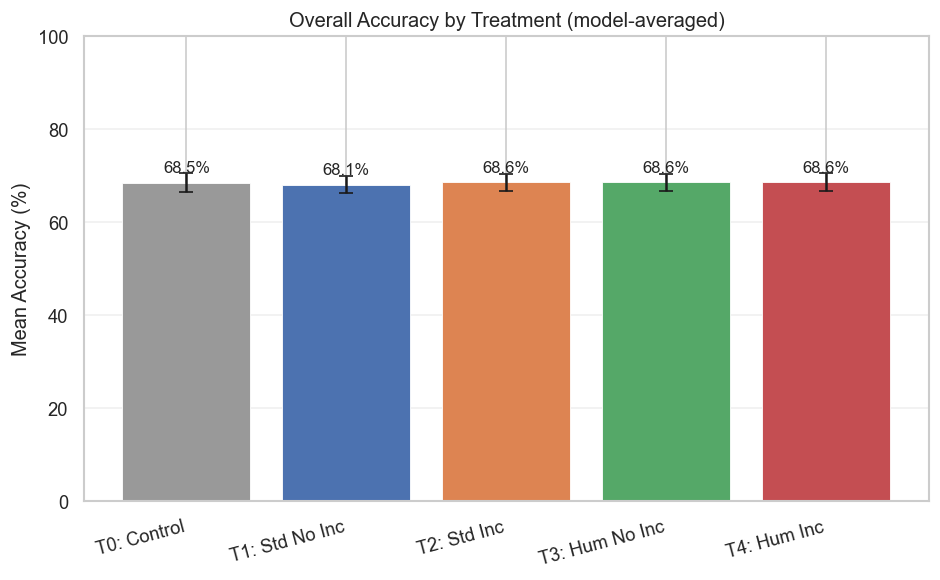

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

# Average accuracy per model within each treatment, then average across models
model_treatment_acc = (
    grouped_df.groupby(["treatment", "model_short"], observed=True)["accuracy"]
    .mean()
    .reset_index()
)
treatment_means = model_treatment_acc.groupby("treatment", observed=True)[
    "accuracy"
].agg(["mean", "std", "count"])
treatment_means["se"] = treatment_means["std"] / np.sqrt(treatment_means["count"])

bars = ax.bar(
    range(len(treatment_means)),
    treatment_means["mean"] * 100,
    yerr=treatment_means["se"] * 100,
    color=treatment_palette,
    capsize=4,
    edgecolor="white",
    linewidth=0.5,
)
for bar, val in zip(bars, treatment_means["mean"] * 100):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f"{val:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set_xticks(range(len(treatment_means)))
ax.set_xticklabels(TREATMENT_ORDER, rotation=15, ha="right")
ax.set_ylabel("Mean Accuracy (%)")
ax.set_title("Overall Accuracy by Treatment (model-averaged)")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

## 4. Accuracy by Treatment × Game

/var/folders/7n/zmfsnpmx1s173gkx77zlr_gw0000gn/T/ipykernel_98032/2001817071.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/7n/zmfsnpmx1s173gkx77zlr_gw0000gn/T/ipykernel_98032/2001817071.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/7n/zmfsnpmx1s173gkx77zlr_gw0000gn/T/ipykernel_98032/2001817071.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/7n/zmfsnpmx1s173gkx77zlr_gw0000gn/T/ipykernel_98032/2001817071.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

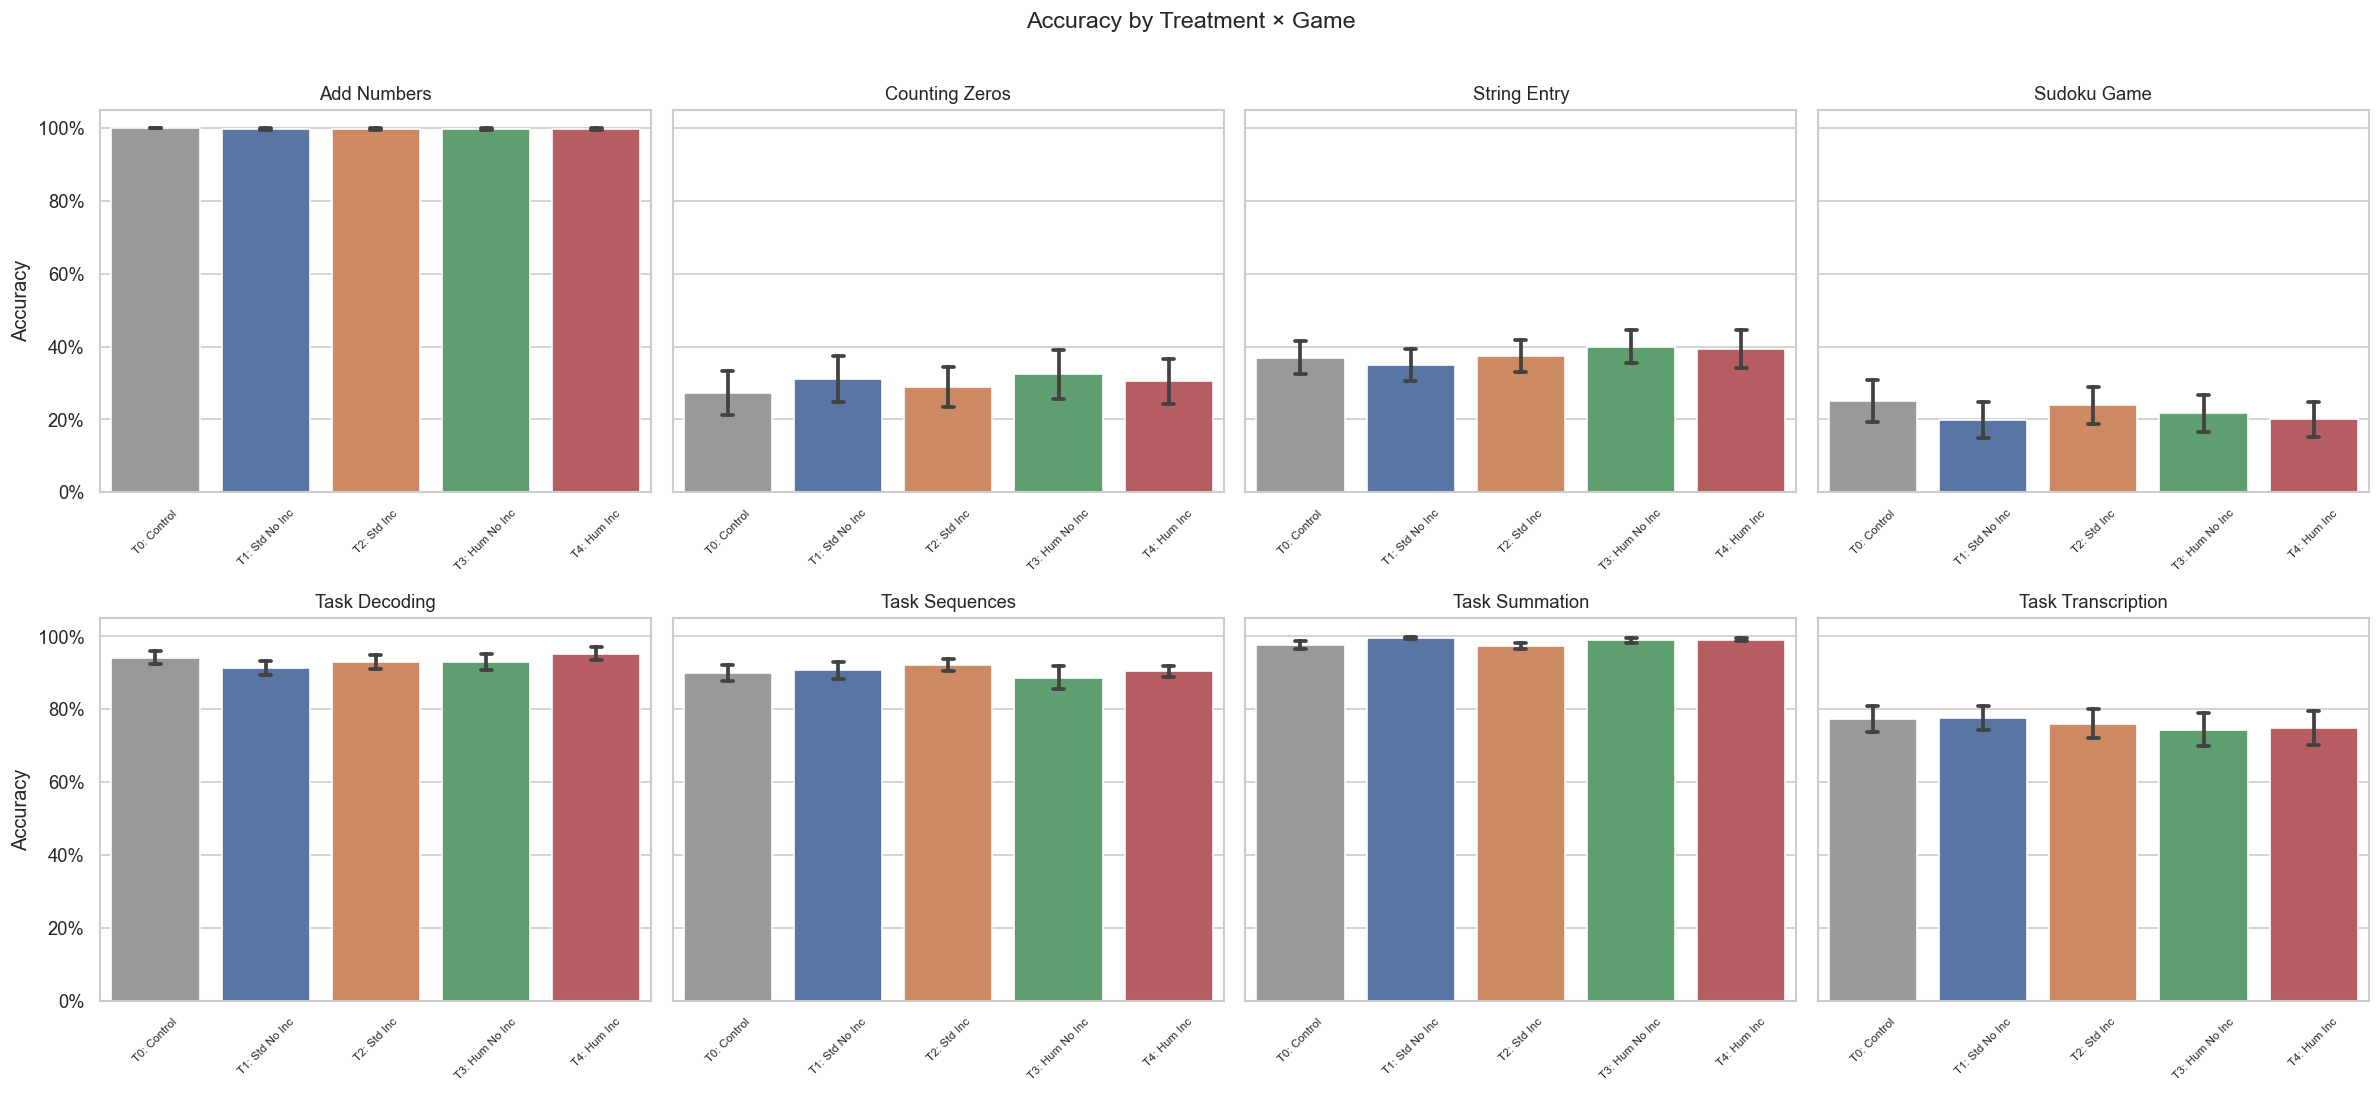

In [9]:
games = sorted(grouped_df["game"].unique())
ncols = 4
nrows = math.ceil(len(games) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows), sharey=True)
axes = axes.flatten()

for idx, game in enumerate(games):
    ax = axes[idx]
    g_data = grouped_df[grouped_df["game"] == game]
    sns.barplot(
        data=g_data,
        x="treatment",
        y="accuracy",
        ax=ax,
        palette=treatment_palette,
        errorbar="se",
        capsize=0.1,
    )
    ax.set_title(game.replace("_", " ").title(), fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Accuracy" if idx % ncols == 0 else "")
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.tick_params(axis="x", rotation=45, labelsize=7)

for idx in range(len(games), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Accuracy by Treatment × Game", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## 5. Accuracy Heatmaps (Model × Game) per Treatment

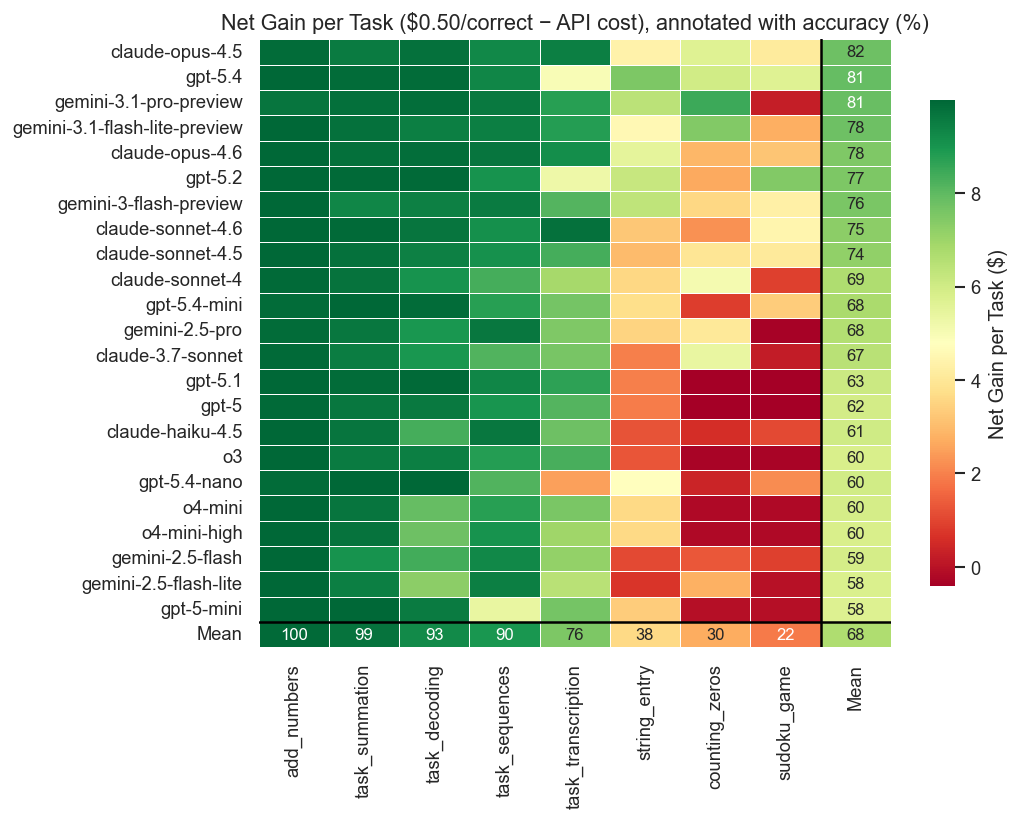

In [10]:
# Net Gain heatmap: color = net gain ($), annotations = accuracy (%) on Mean only
# Same ordering as the accuracy heatmap above

_ng_h = grouped_df.copy()
_ng_h["net_gain"] = (
    _ng_h["accuracy"] * _ng_h["n_puzzles"] * 0.50 - _ng_h["cost_per_game"]
)

# Net gain pivot
ng_pivot = _ng_h.pivot_table(
    index="model_short", columns="game", values="net_gain", aggfunc="mean"
)

# Accuracy pivot (for annotations)
acc_pivot = (
    grouped_df.pivot_table(index="model_short", columns="game", values="accuracy") * 100
)

# Order models by accuracy (best top), games by accuracy (easiest left)
model_order = acc_pivot.mean(axis=1).sort_values(ascending=False).index.tolist()
game_order = acc_pivot.mean(axis=0).sort_values(ascending=False).index.tolist()

ng_pivot = ng_pivot.loc[model_order, game_order]
acc_pivot = acc_pivot.loc[model_order, game_order]

# Add Mean row/col to both
ng_pivot["Mean"] = ng_pivot.mean(axis=1)
ng_pivot.loc["Mean"] = ng_pivot.mean(axis=0)
acc_pivot["Mean"] = acc_pivot.mean(axis=1)
acc_pivot.loc["Mean"] = acc_pivot.mean(axis=0)

# Annotation: accuracy % on Mean row/col only, blank elsewhere
annot = acc_pivot.copy().astype(str)
for r in annot.index:
    for c in annot.columns:
        if r == "Mean" or c == "Mean":
            annot.loc[r, c] = f"{acc_pivot.loc[r, c]:.0f}"
        else:
            annot.loc[r, c] = ""

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    ng_pivot,
    annot=annot,
    fmt="s",
    cmap="RdYlGn",
    linewidths=0.3,
    linecolor="white",
    ax=ax,
    cbar_kws={"label": "Net Gain per Task ($)", "shrink": 0.8},
    annot_kws={"fontsize": 10},
)

# Separator before Mean row/col
models = list(ng_pivot.index)
ax.axhline(y=len(models) - 1, color="black", linewidth=1.5)
ax.axvline(x=len(ng_pivot.columns) - 1, color="black", linewidth=1.5)

ax.set_title(
    "Net Gain per Task ($0.50/correct − API cost), annotated with accuracy (%)",
    fontsize=13,
)
ax.set_ylabel("")
ax.set_xlabel("")
fig.tight_layout()
plt.show()

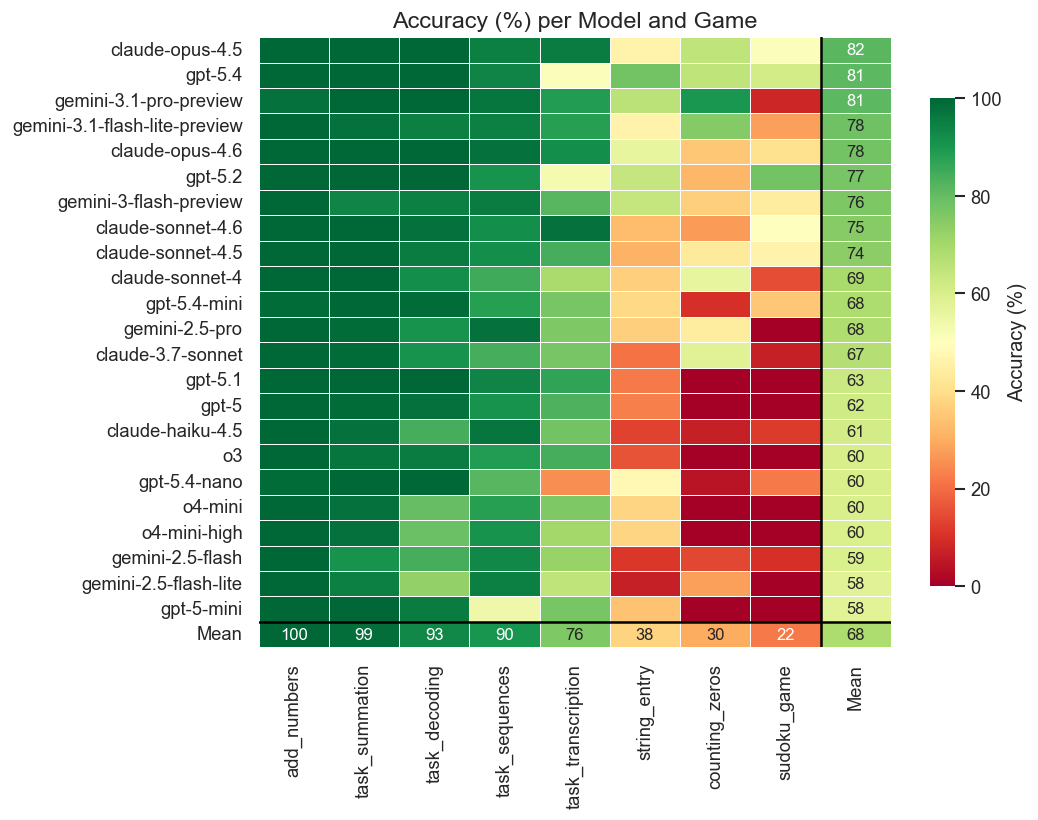

In [11]:
# Accuracy heatmap: model × game averaged over all 5 treatments
# Clean: color carries the signal, numbers only on Mean row/column
# Models ordered by accuracy (best top), games by accuracy (easiest left)

avg_pivot = (
    grouped_df.pivot_table(index="model_short", columns="game", values="accuracy") * 100
)

# Order models by overall accuracy (best at top)
model_order = avg_pivot.mean(axis=1).sort_values(ascending=False).index.tolist()
avg_pivot = avg_pivot.loc[model_order]

# Order games by overall accuracy (easiest left → hardest right)
game_order = avg_pivot.mean(axis=0).sort_values(ascending=False).index.tolist()
avg_pivot = avg_pivot[game_order]

avg_pivot["Mean"] = avg_pivot.mean(axis=1)
avg_pivot.loc["Mean"] = avg_pivot.mean(axis=0)

# Annotation: blank inner cells, numbers on Mean row/col only
annot = avg_pivot.copy().astype(str)
for r in annot.index:
    for c in annot.columns:
        if r == "Mean" or c == "Mean":
            annot.loc[r, c] = f"{avg_pivot.loc[r, c]:.0f}"
        else:
            annot.loc[r, c] = ""

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    avg_pivot,
    annot=annot,
    fmt="s",
    cmap="RdYlGn",
    vmin=0,
    vmax=100,
    linewidths=0.3,
    linecolor="white",
    ax=ax,
    cbar_kws={"label": "Accuracy (%)", "shrink": 0.8},
    annot_kws={"fontsize": 10},
)

# Separator before Mean row/col
models = list(avg_pivot.index)
ax.axhline(y=len(models) - 1, color="black", linewidth=1.5)
ax.axvline(x=len(avg_pivot.columns) - 1, color="black", linewidth=1.5)

ax.set_title("Accuracy (%) per Model and Game", fontsize=14)
ax.set_ylabel("")
ax.set_xlabel("")
fig.tight_layout()
plt.show()

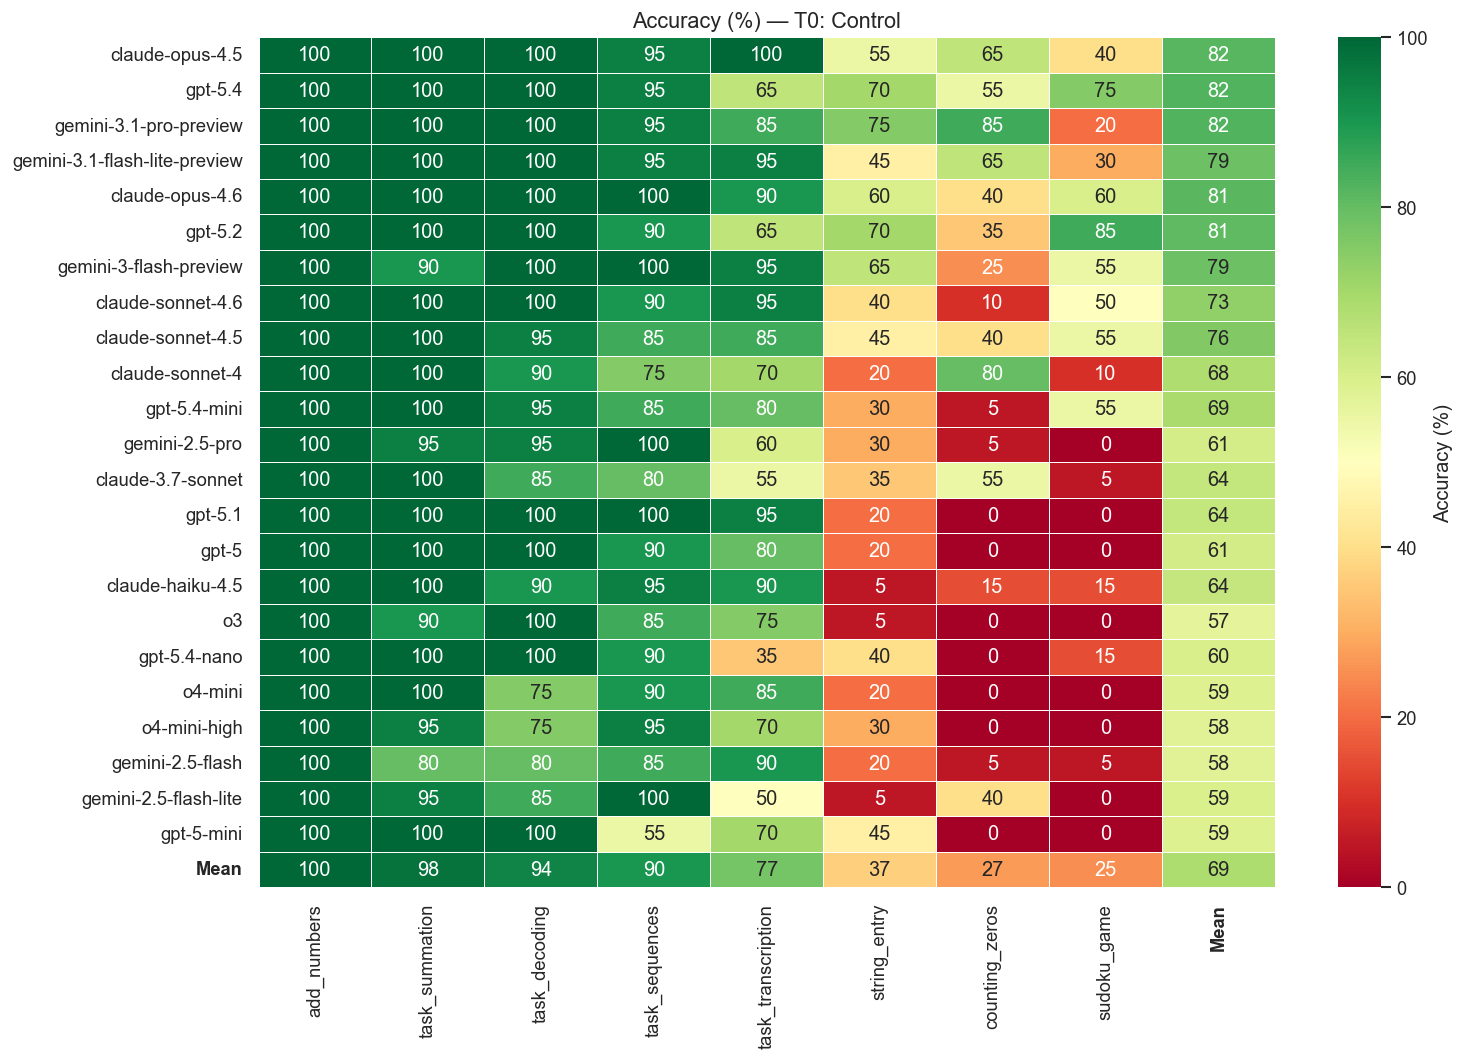

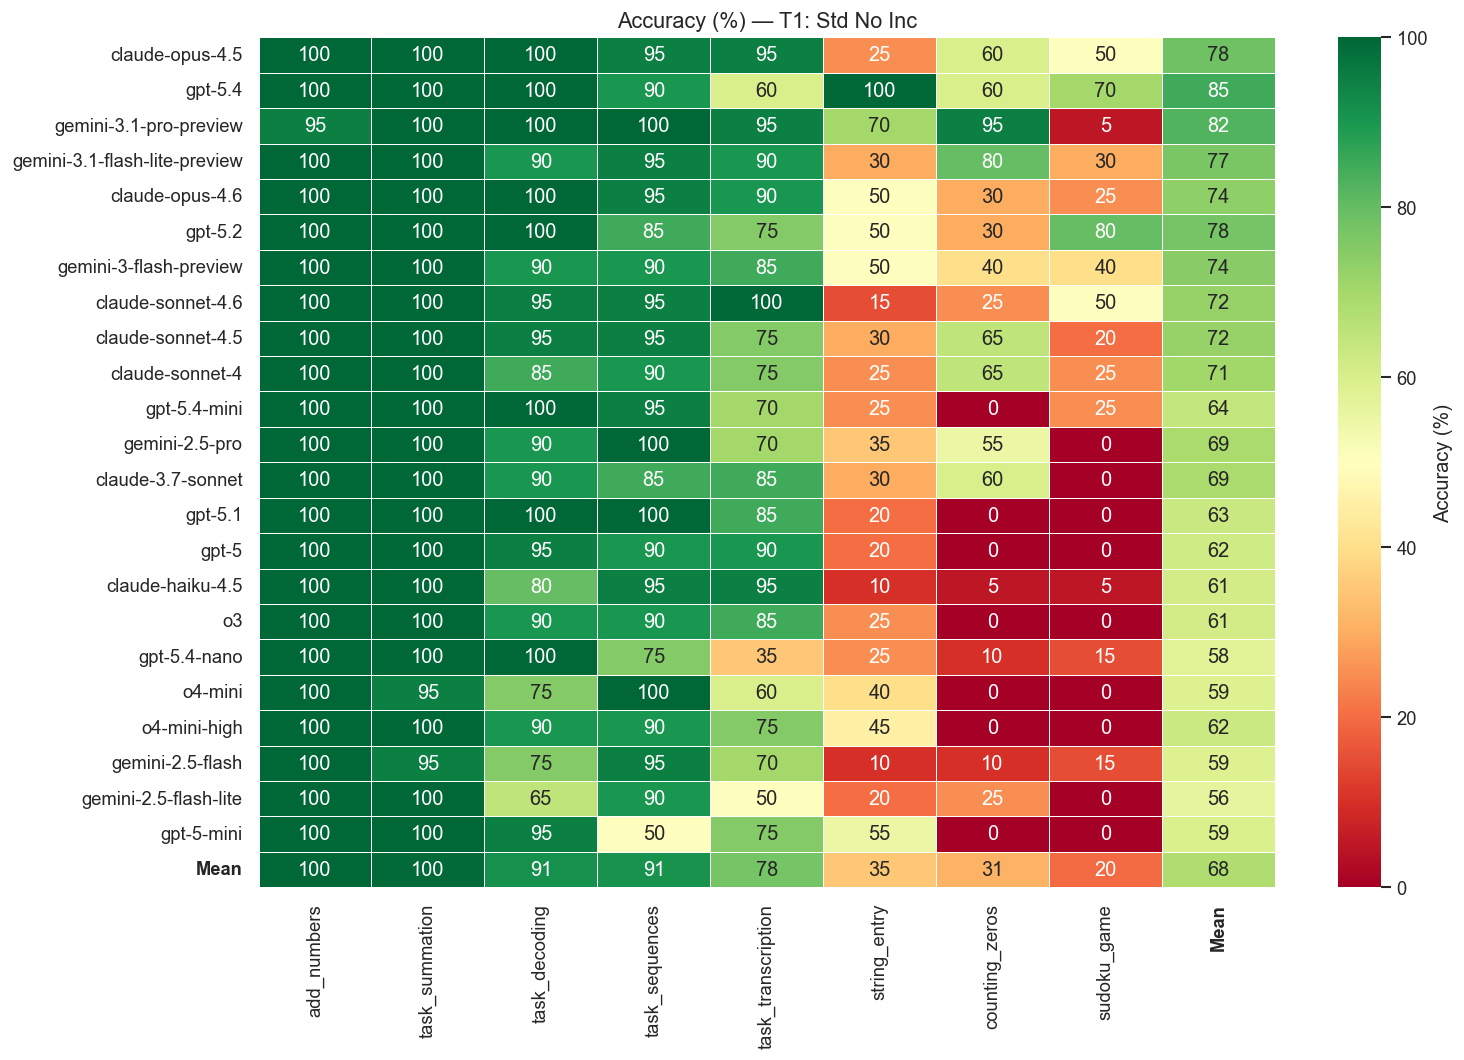

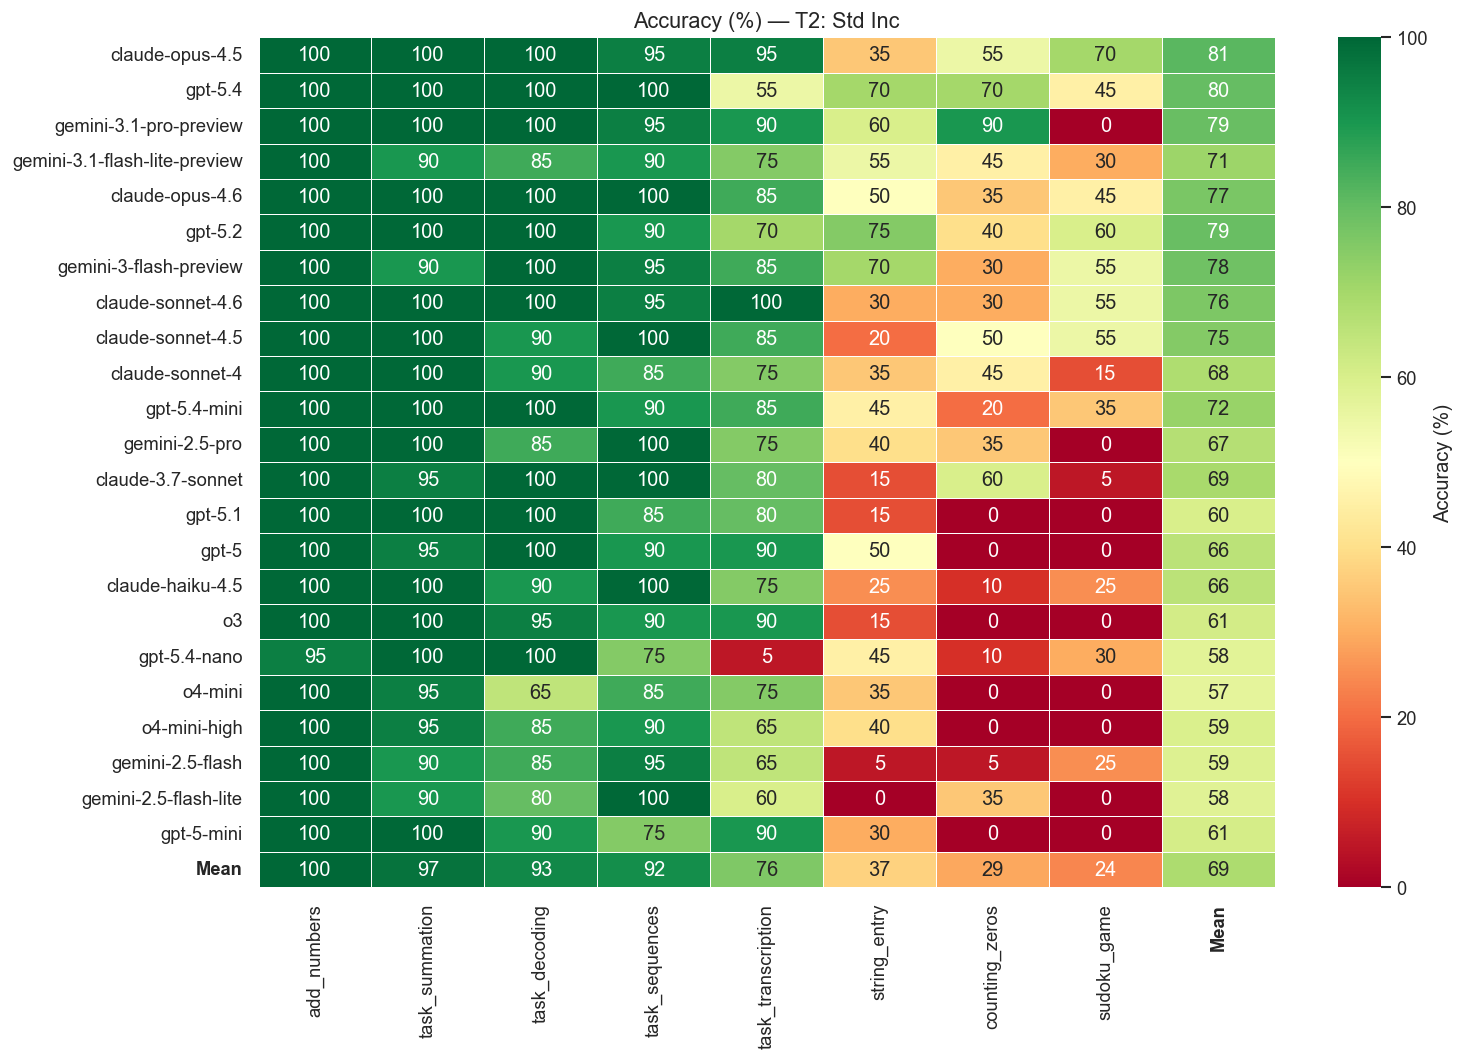

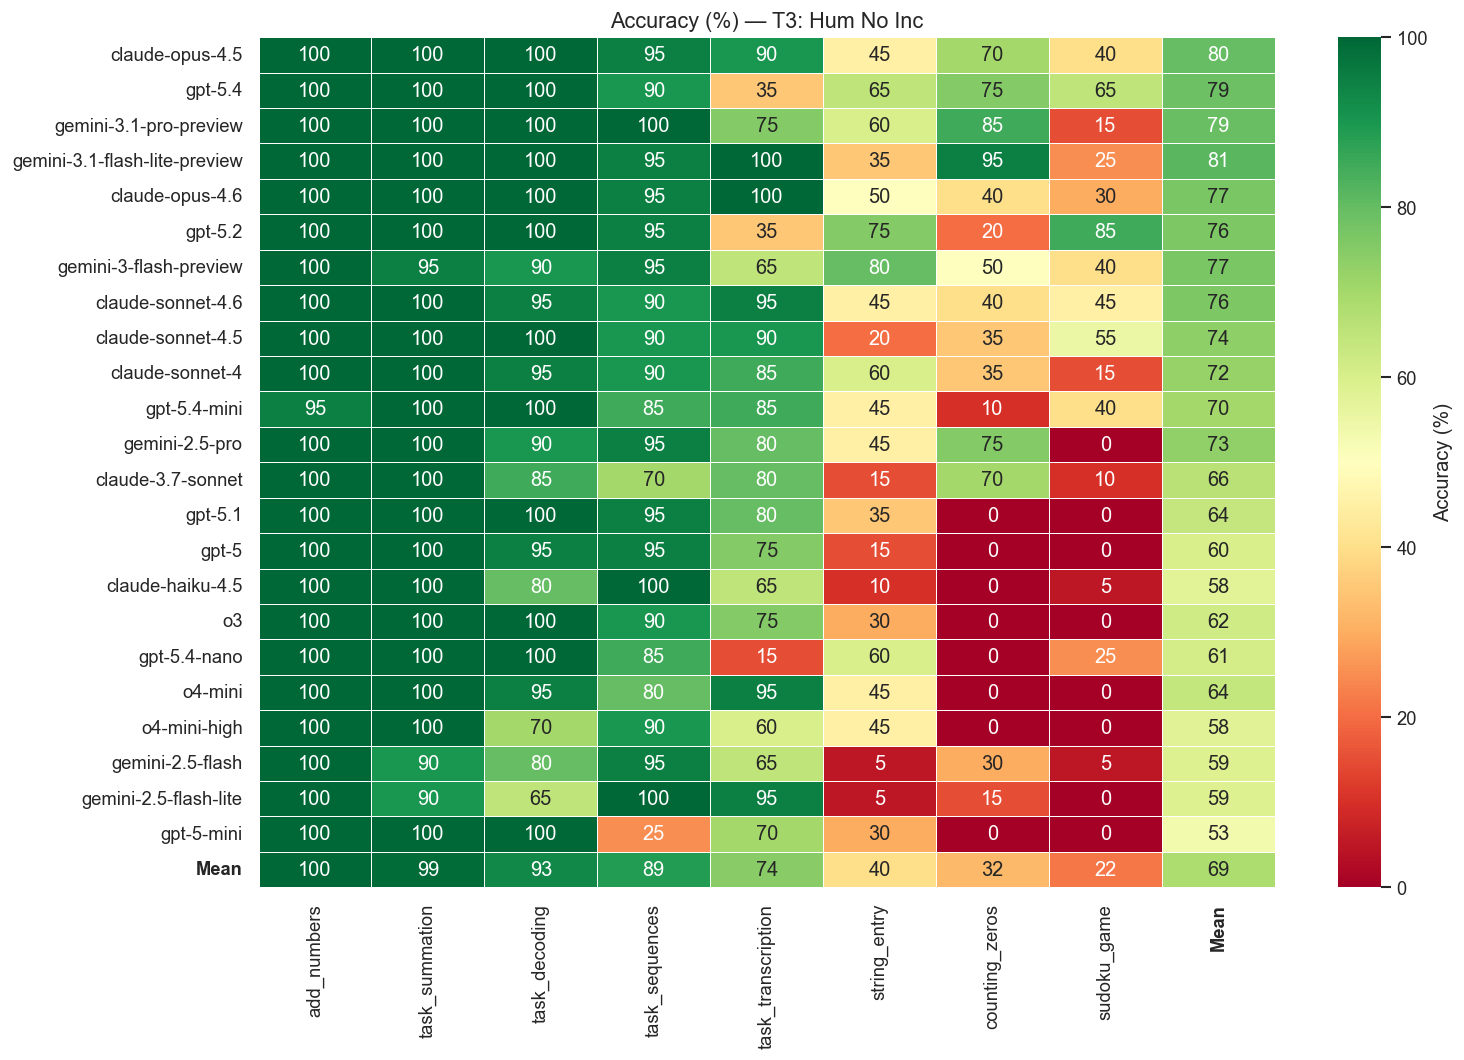

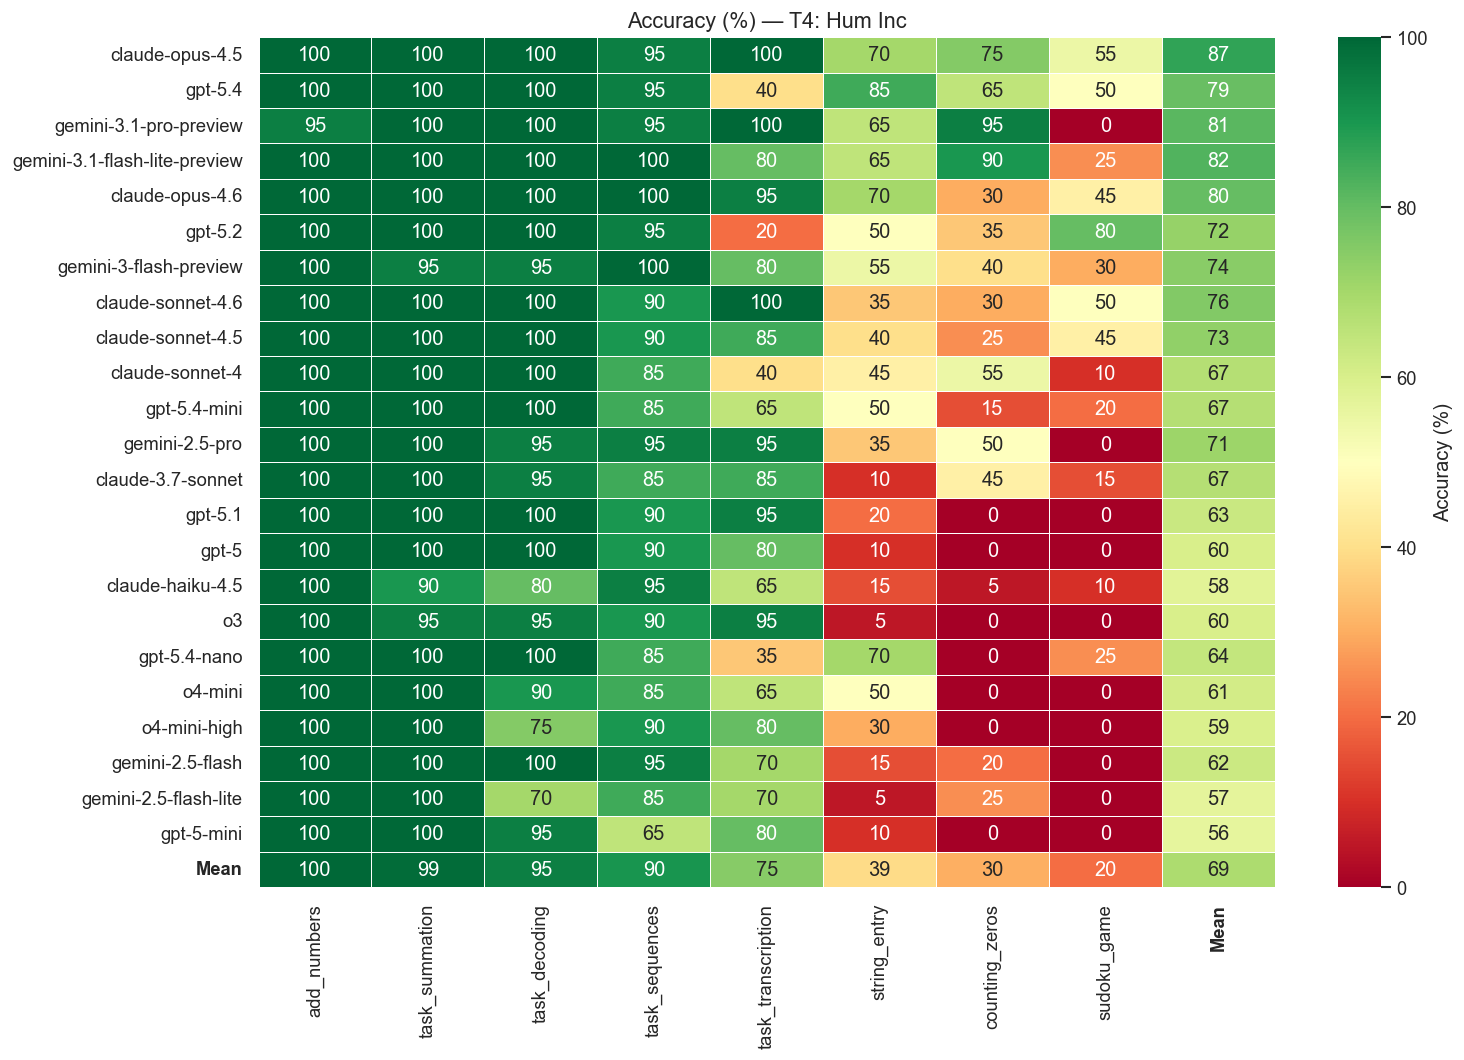

In [12]:
# Compute ordering from overall accuracy (self-contained)
_acc_avg = grouped_df.pivot_table(index="model_short", columns="game", values="accuracy") * 100
_model_ord = _acc_avg.mean(axis=1).sort_values(ascending=False).index.tolist()
_game_ord = _acc_avg.mean(axis=0).sort_values(ascending=False).index.tolist()

for treatment in TREATMENT_ORDER:
    t_data = grouped_df[grouped_df["treatment"] == treatment]
    pivot = (
        t_data.pivot_table(index="model_short", columns="game", values="accuracy") * 100
    )
    # Order by accuracy (same as the averaged heatmap)
    pivot = pivot.reindex(index=[m for m in _model_ord if m in pivot.index])
    pivot = pivot[[g for g in _game_ord if g in pivot.columns]]

    # Add mean row and column
    pivot["Mean"] = pivot.mean(axis=1)
    pivot.loc["Mean"] = pivot.mean(axis=0)

    fig, ax = plt.subplots(figsize=(13, 9))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".0f",
        cmap="RdYlGn",
        vmin=0,
        vmax=100,
        linewidths=0.5,
        ax=ax,
        cbar_kws={"label": "Accuracy (%)"},
    )
    # Bold the Mean row/column labels
    xlabels = ax.get_xticklabels()
    for lbl in xlabels:
        if lbl.get_text() == "Mean":
            lbl.set_weight("bold")
    ax.set_xticklabels(xlabels)
    ylabels = ax.get_yticklabels()
    for lbl in ylabels:
        if lbl.get_text() == "Mean":
            lbl.set_weight("bold")
    ax.set_yticklabels(ylabels)

    ax.set_title(f"Accuracy (%) — {treatment}", fontsize=13)
    ax.set_ylabel("")
    ax.set_xlabel("")
    fig.tight_layout()
    plt.show()


## 6. Treatment Effects: Pairwise Accuracy Deltas

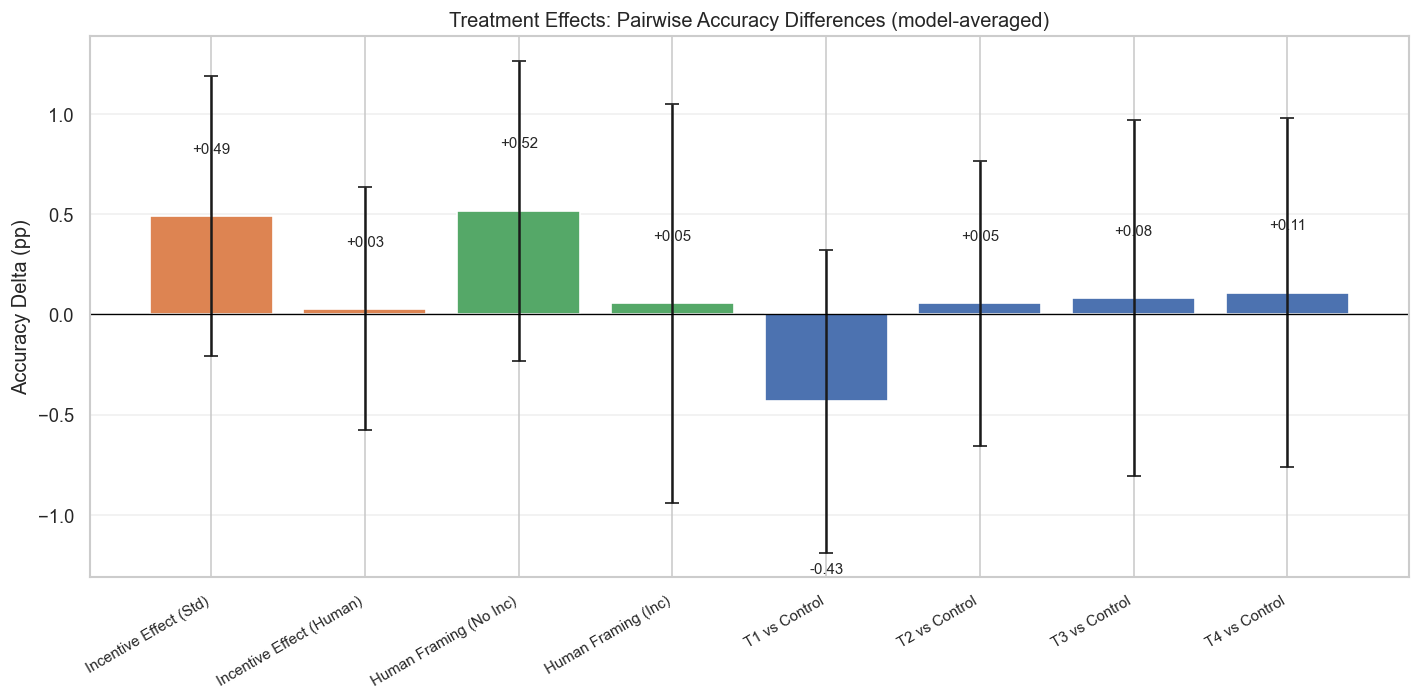

In [13]:
# Per-model accuracy in each treatment
model_acc = (
    grouped_df.groupby(["treatment", "model_short"], observed=True)["accuracy"]
    .mean()
    .unstack("treatment")
)

contrasts = {
    "Incentive Effect (Std)": ("T2: Std Inc", "T1: Std No Inc"),
    "Incentive Effect (Human)": ("T4: Hum Inc", "T3: Hum No Inc"),
    "Human Framing (No Inc)": ("T3: Hum No Inc", "T1: Std No Inc"),
    "Human Framing (Inc)": ("T4: Hum Inc", "T2: Std Inc"),
    "T1 vs Control": ("T1: Std No Inc", "T0: Control"),
    "T2 vs Control": ("T2: Std Inc", "T0: Control"),
    "T3 vs Control": ("T3: Hum No Inc", "T0: Control"),
    "T4 vs Control": ("T4: Hum Inc", "T0: Control"),
}

delta_df = pd.DataFrame()
for label, (t_high, t_low) in contrasts.items():
    delta_df[label] = (model_acc[t_high] - model_acc[t_low]) * 100

fig, ax = plt.subplots(figsize=(12, 6))
delta_means = delta_df.mean()
delta_ses = delta_df.std() / np.sqrt(delta_df.count())

bar_colors = [
    TREATMENT_COLORS["T2: Std Inc"],
    TREATMENT_COLORS["T2: Std Inc"],
    TREATMENT_COLORS["T3: Hum No Inc"],
    TREATMENT_COLORS["T3: Hum No Inc"],
    TREATMENT_COLORS["T1: Std No Inc"],
    TREATMENT_COLORS["T1: Std No Inc"],
    TREATMENT_COLORS["T1: Std No Inc"],
    TREATMENT_COLORS["T1: Std No Inc"],
]
bars = ax.bar(
    range(len(delta_means)),
    delta_means,
    yerr=delta_ses,
    capsize=4,
    color=bar_colors,
    edgecolor="white",
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(range(len(delta_means)))
ax.set_xticklabels(delta_means.index, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Accuracy Delta (pp)")
ax.set_title("Treatment Effects: Pairwise Accuracy Differences (model-averaged)")
ax.grid(axis="y", alpha=0.3)

for bar, val in zip(bars, delta_means):
    y = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        y + (0.3 if y >= 0 else -0.8),
        f"{val:+.2f}",
        ha="center",
        va="bottom" if y >= 0 else "top",
        fontsize=9,
    )

fig.tight_layout()
plt.show()

In [14]:
# Summary table of deltas
delta_summary = pd.DataFrame(
    {
        "Mean (pp)": delta_df.mean().round(2),
        "Std (pp)": delta_df.std().round(2),
        "SE (pp)": (delta_df.std() / np.sqrt(delta_df.count())).round(3),
        "Min (pp)": delta_df.min().round(2),
        "Max (pp)": delta_df.max().round(2),
        "N models": delta_df.count(),
    }
)
delta_summary

,Mean (pp),Std (pp),SE (pp),Min (pp),Max (pp),N models
Incentive Effect (Std),0.49,3.34,0.697,-5.63,7.50,23
Incentive Effect (Human),0.03,2.90,0.606,-5.63,6.87,23
Human Framing (No Inc),0.52,3.59,0.748,-6.25,5.63,23
Human Framing (Inc),0.05,4.76,0.993,-8.13,11.25,23
T1 vs Control,-0.43,3.62,0.755,-7.50,8.13,23
T2 vs Control,0.05,3.41,0.710,-7.50,6.25,23
T3 vs Control,0.08,4.26,0.889,-6.25,12.50,23
T4 vs Control,0.11,4.18,0.871,-8.13,10.63,23


## 7. Per-Model Treatment Deltas

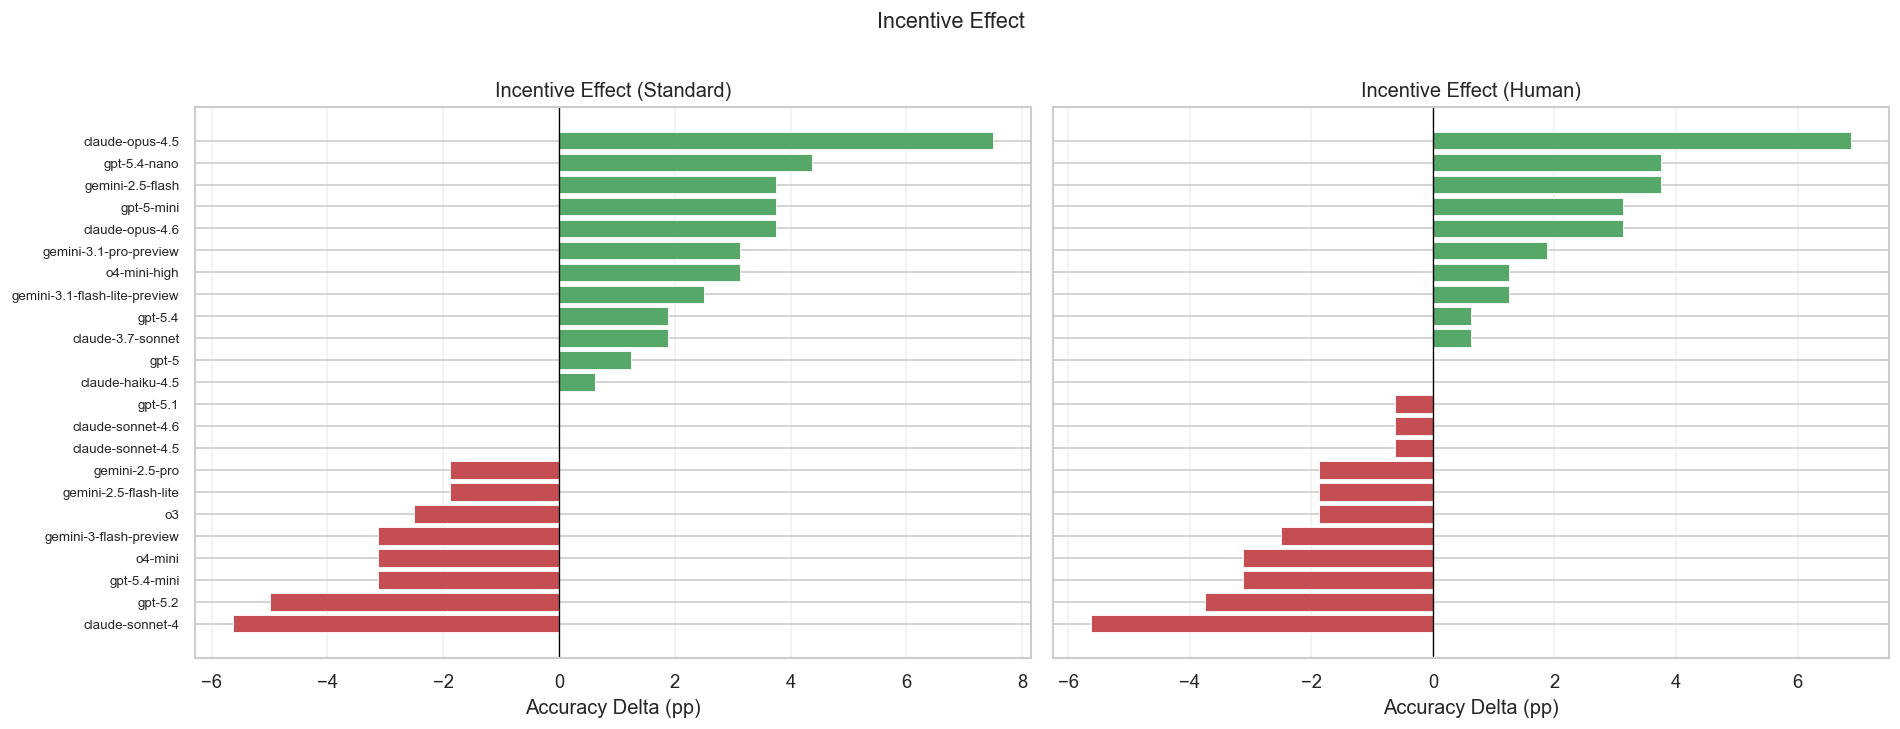

In [15]:
# Incentive effect per model (std and human)
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, (label, (t_high, t_low)) in zip(
    axes,
    [
        ("Incentive Effect (Standard)", ("T2: Std Inc", "T1: Std No Inc")),
        ("Incentive Effect (Human)", ("T4: Hum Inc", "T3: Hum No Inc")),
    ],
):
    deltas = (model_acc[t_high] - model_acc[t_low]).sort_values() * 100
    bar_colors = ["#55A868" if v >= 0 else "#C44E52" for v in deltas]
    ax.barh(
        range(len(deltas)), deltas, color=bar_colors, edgecolor="white", linewidth=0.5
    )
    ax.set_yticks(range(len(deltas)))
    ax.set_yticklabels(deltas.index, fontsize=8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Accuracy Delta (pp)")
    ax.set_title(label)
    ax.grid(axis="x", alpha=0.3)

fig.suptitle("Incentive Effect", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

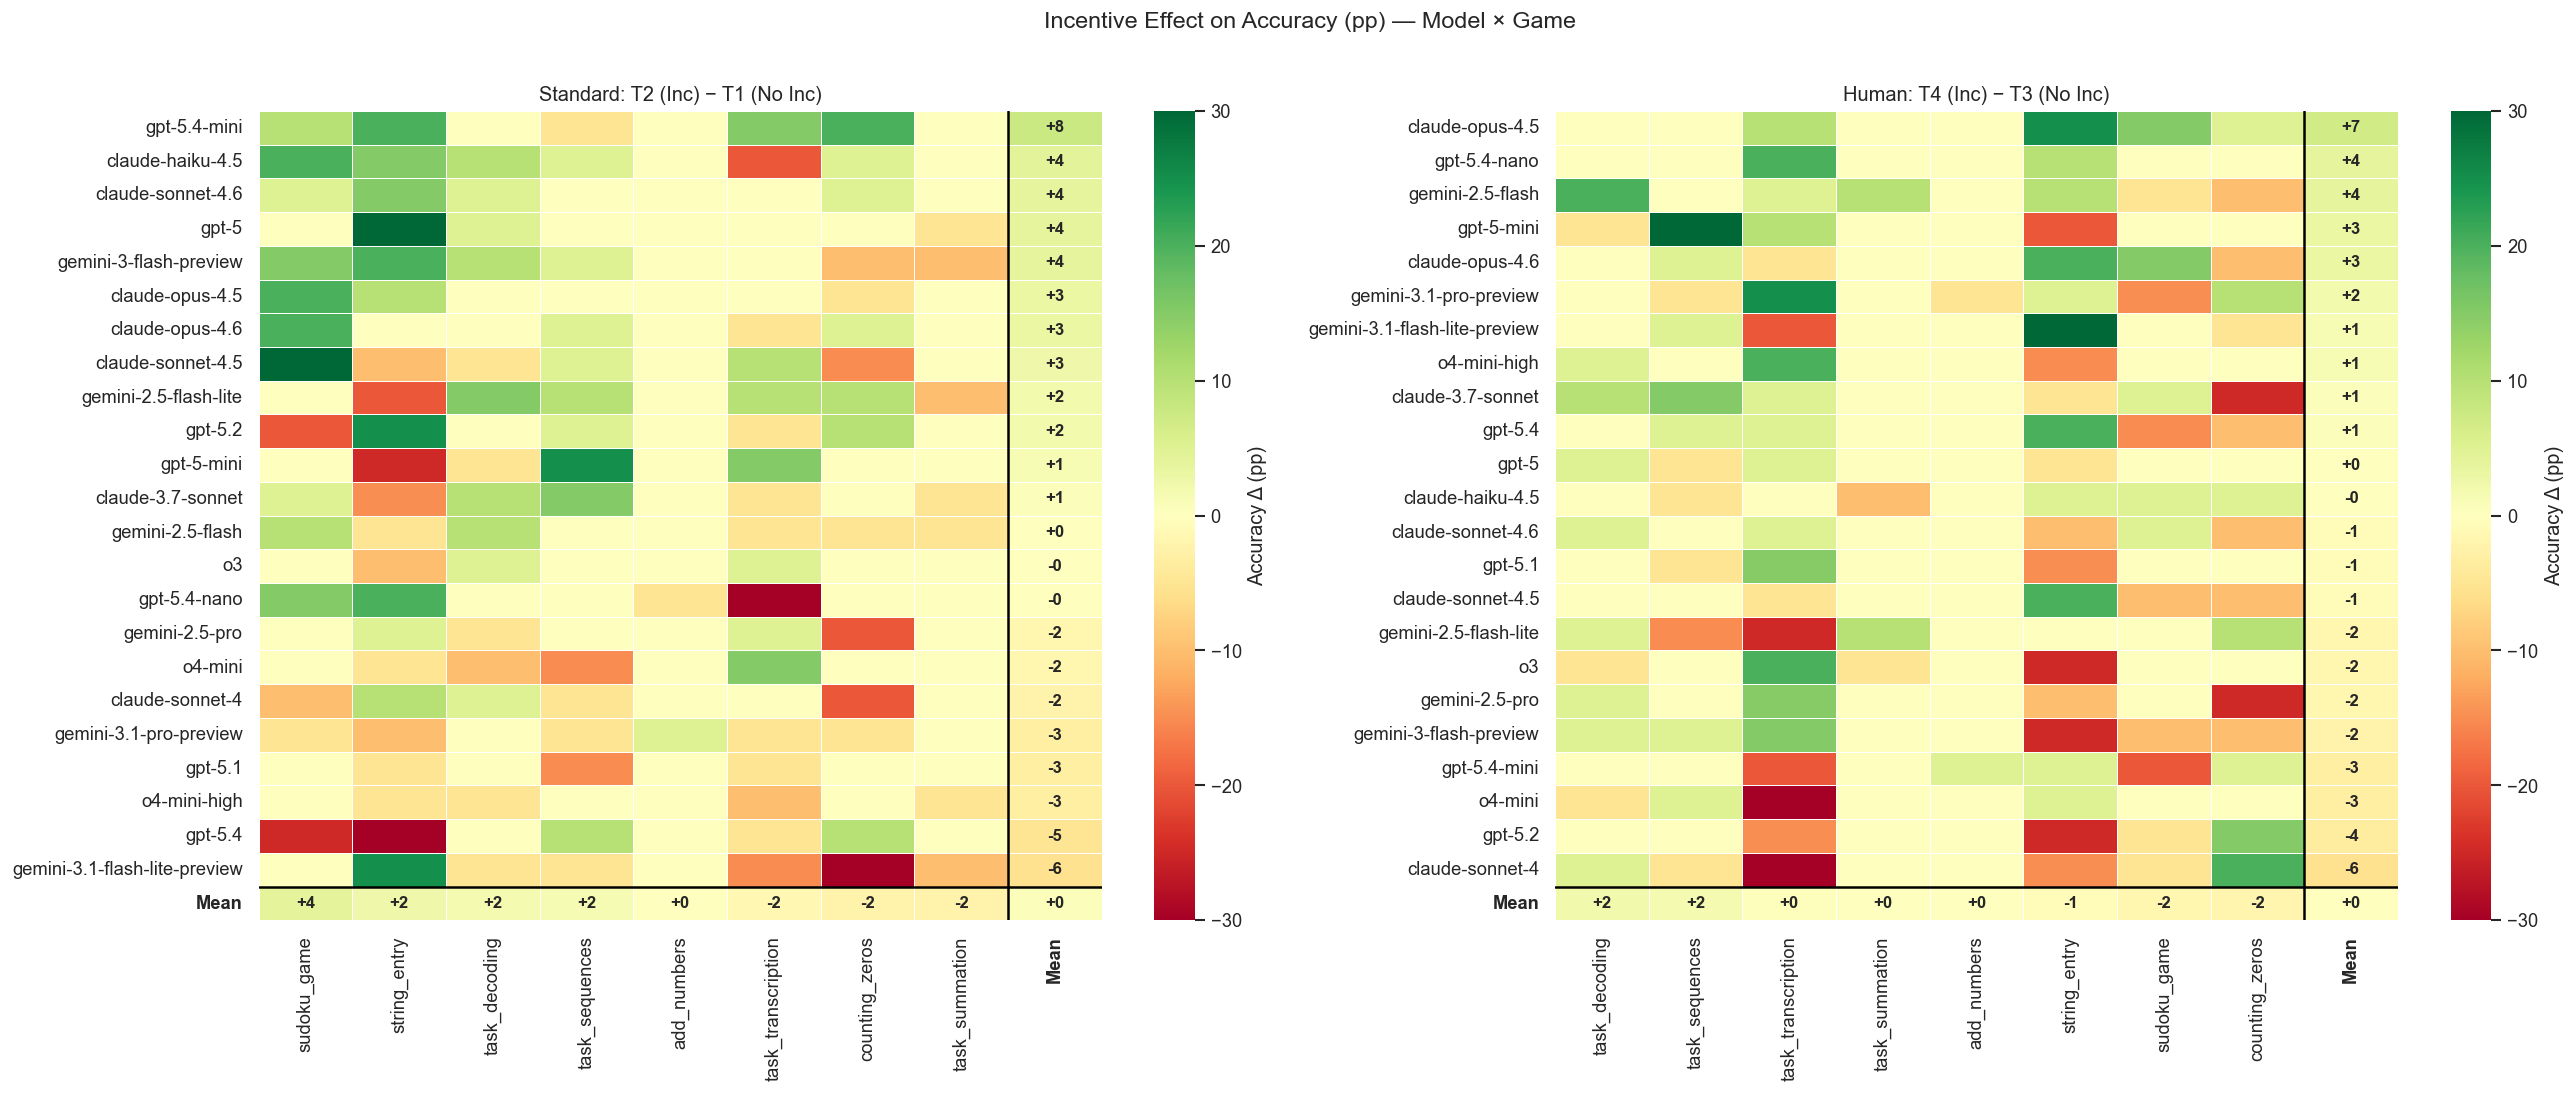

In [16]:
# Incentive effect heatmaps: accuracy delta (incentive − no incentive) per model × game
# Clean: annotations only on Mean row/column

acc_pivot_all = grouped_df.pivot_table(
    index="model_short", columns=["treatment", "game"], values="accuracy"
)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

for ax, (title, t_high, t_low) in zip(
    axes,
    [
        ("Standard: T2 (Inc) \u2212 T1 (No Inc)", "T2: Std Inc", "T1: Std No Inc"),
        ("Human: T4 (Inc) \u2212 T3 (No Inc)", "T4: Hum Inc", "T3: Hum No Inc"),
    ],
):
    delta = (acc_pivot_all[t_high] - acc_pivot_all[t_low]) * 100

    # Order by this delta's own content
    delta = delta.loc[delta.mean(axis=1).sort_values(ascending=False).index]
    delta = delta[delta.mean(axis=0).sort_values(ascending=False).index]

    delta["Mean"] = delta.mean(axis=1)
    delta.loc["Mean"] = delta.mean(axis=0)

    annot = delta.copy().astype(str)
    for r in annot.index:
        for c in annot.columns:
            if r == "Mean" or c == "Mean":
                annot.loc[r, c] = f"{delta.loc[r, c]:+.0f}"
            else:
                annot.loc[r, c] = ""

    sns.heatmap(
        delta,
        annot=annot,
        fmt='s',
        cmap="RdYlGn",
        center=0,
        linewidths=0.3,
        linecolor='white',
        ax=ax,
        cbar_kws={"label": "Accuracy \u0394 (pp)"},
        vmin=-30,
        vmax=30,
        annot_kws={'fontsize': 10, 'fontweight': 'bold'},
    )
    for lbl in ax.get_xticklabels():
        if lbl.get_text() == 'Mean': lbl.set_weight('bold')
    for lbl in ax.get_yticklabels():
        if lbl.get_text() == 'Mean': lbl.set_weight('bold')

    models = list(delta.index)
    ax.axhline(y=len(models) - 1, color='black', linewidth=1.5)
    ax.axvline(x=len(delta.columns) - 1, color='black', linewidth=1.5)

    ax.set_title(title, fontsize=12)
    ax.set_ylabel("")
    ax.set_xlabel("")

fig.suptitle("Incentive Effect on Accuracy (pp) \u2014 Model \u00d7 Game", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## 8. Completion Tokens & Response Time by Treatment

/var/folders/7n/zmfsnpmx1s173gkx77zlr_gw0000gn/T/ipykernel_98032/549546688.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/7n/zmfsnpmx1s173gkx77zlr_gw0000gn/T/ipykernel_98032/549546688.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


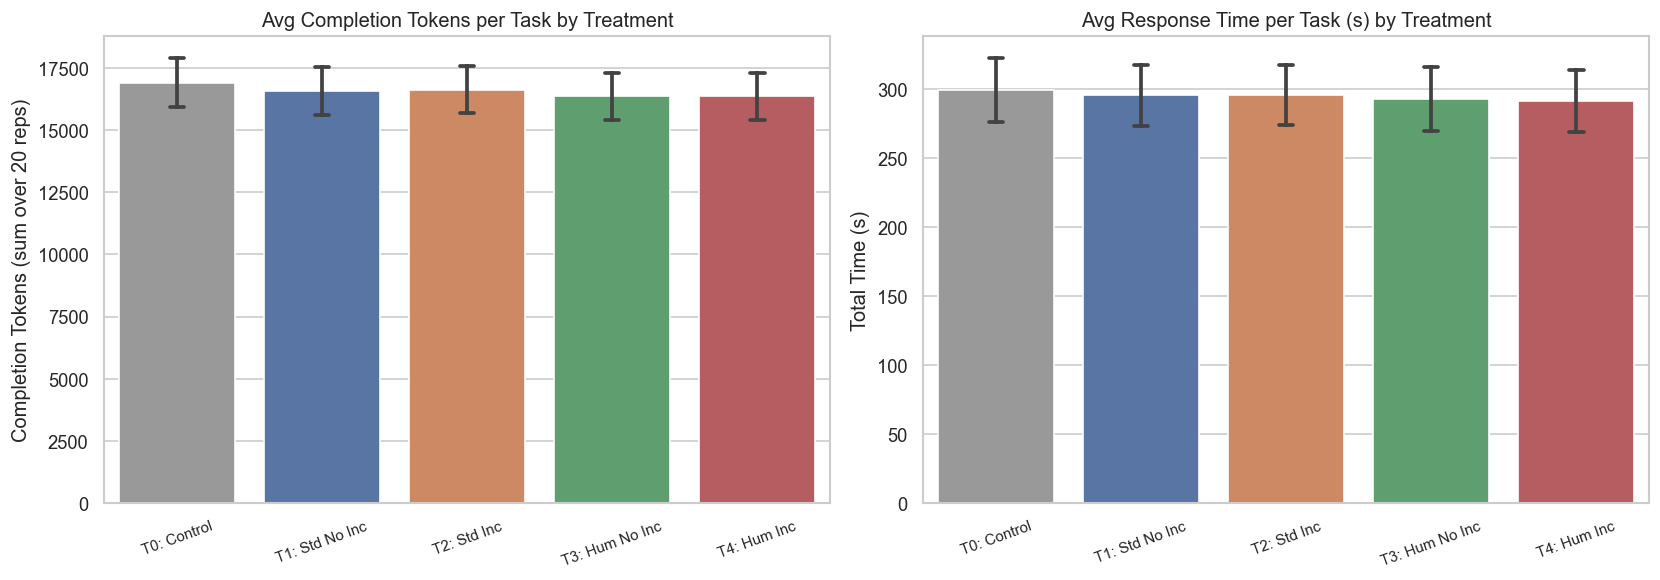

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=grouped_df,
    x="treatment",
    y="total_completion_tokens",
    ax=axes[0],
    palette=treatment_palette,
    errorbar="se",
    capsize=0.1,
)
axes[0].set_title("Avg Completion Tokens per Task by Treatment")
axes[0].set_xlabel("")
axes[0].set_ylabel("Completion Tokens (sum over 20 reps)")
axes[0].tick_params(axis="x", rotation=20, labelsize=9)

sns.barplot(
    data=grouped_df,
    x="treatment",
    y="total_time",
    ax=axes[1],
    palette=treatment_palette,
    errorbar="se",
    capsize=0.1,
)
axes[1].set_title("Avg Response Time per Task (s) by Treatment")
axes[1].set_xlabel("")
axes[1].set_ylabel("Total Time (s)")
axes[1].tick_params(axis="x", rotation=20, labelsize=9)

fig.tight_layout()
plt.show()

## 9. Completion Tokens Analysis

In [18]:
# Completion tokens by treatment (excludes timeouts for cleaner picture, but they're imputed at 2048)
print(f"Total observations: {len(df):,}")
print(f"Timed-out (imputed at {MAX_TOKENS} tokens): {df['timed_out'].sum()}")
print(f"Avg completion tokens (all): {df['completion_tokens'].mean():.0f}")
print(
    f"Avg completion tokens (non-timeout): {df.loc[~df['timed_out'], 'completion_tokens'].mean():.0f}"
)

Total observations: 18,400
Timed-out (imputed at 2048 tokens): 30
Avg completion tokens (all): 828
Avg completion tokens (non-timeout): 826


/var/folders/7n/zmfsnpmx1s173gkx77zlr_gw0000gn/T/ipykernel_98032/1618597227.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


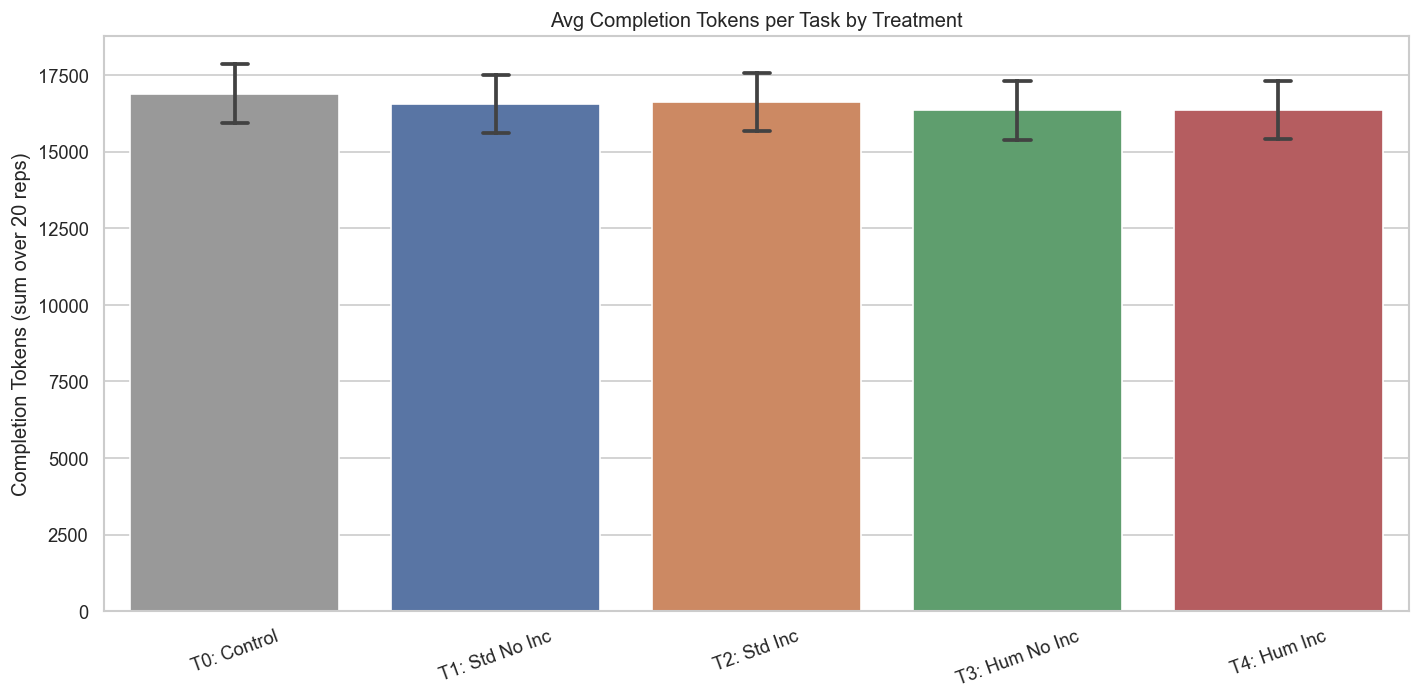

In [19]:
sns.barplot(
    data=grouped_df,
    x="treatment",
    y="total_completion_tokens",
    palette=treatment_palette,
    errorbar="se",
    capsize=0.1,
)
plt.title("Avg Completion Tokens per Task by Treatment")
plt.xlabel("")
plt.ylabel("Completion Tokens (sum over 20 reps)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 10. Model Rankings Across Treatments

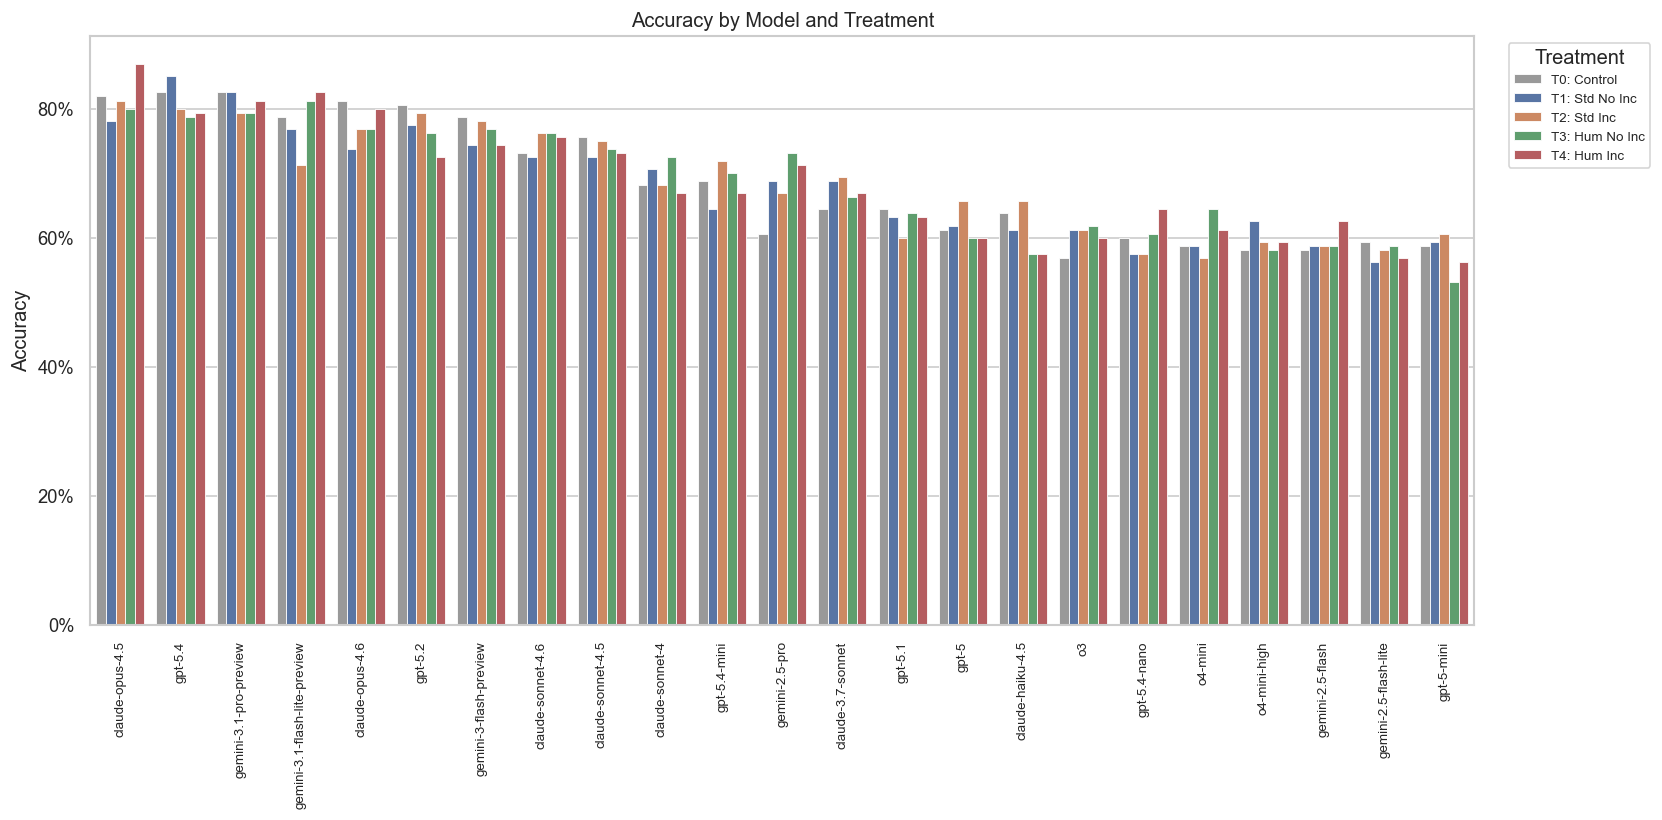

In [20]:
# Sort models by overall accuracy (descending)
model_order = (
    grouped_df.groupby("model_short", observed=True)["accuracy"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(14, 7))
mt_data = (
    grouped_df.groupby(["model_short", "treatment"], observed=True)["accuracy"]
    .mean()
    .reset_index()
)
mt_data["model_short"] = pd.Categorical(
    mt_data["model_short"], categories=model_order, ordered=True
)

sns.barplot(
    data=mt_data,
    x="model_short",
    y="accuracy",
    hue="treatment",
    ax=ax,
    palette=treatment_palette,
    edgecolor="white",
    linewidth=0.5,
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy by Model and Treatment")
ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.legend(title="Treatment", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()

## 14. Cost Estimation per Task

Estimated API cost per task (20 puzzles) using **OpenRouter pricing** (USD per token).
Reasoning tokens (where tracked) are billed at the completion rate.

Total estimated cost across all experiments: $142.53
Avg cost per task: $0.1549


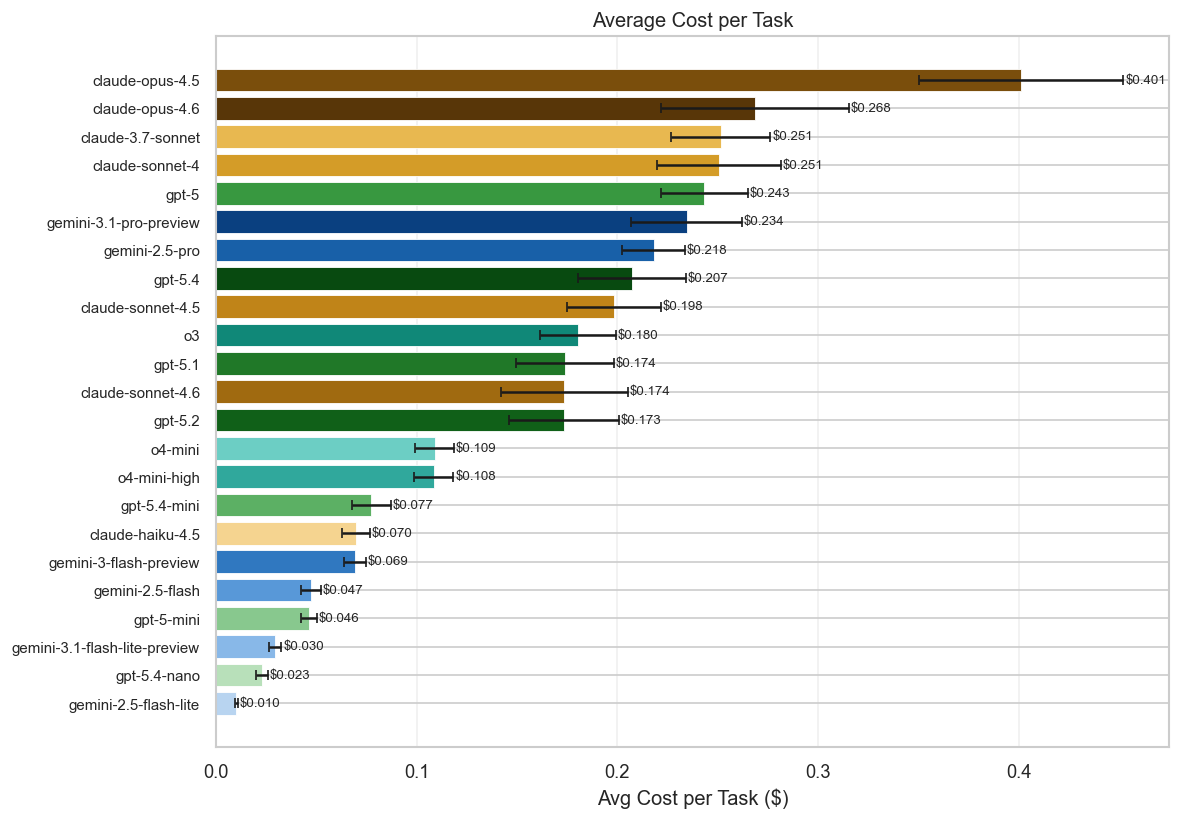

In [21]:
# Average cost per task by model (sum over 20 reps, averaged across treatments & games)
# family_order = sort_by_family(grouped_df["model_short"].unique().tolist())
family_order = model_order = (
    grouped_df.groupby("model_short", observed=True)["cost_per_game"]
    .mean()
    .sort_values(ascending=True)
    .index.tolist()
)

model_avg_cost = grouped_df.groupby("model_short", observed=True)["cost_per_game"].agg(
    ["mean", "std", "count"]
)
model_avg_cost = model_avg_cost.loc[family_order]
model_avg_cost["se"] = model_avg_cost["std"] / np.sqrt(model_avg_cost["count"])

print(
    f"Total estimated cost across all experiments: ${grouped_df['cost_per_game'].sum():.2f}"
)
print(f"Avg cost per task: ${grouped_df['cost_per_game'].mean():.4f}")

fig, ax = plt.subplots(figsize=(10, 7))
bar_colors = [MODEL_COLORS.get(m, "#888888") for m in model_avg_cost.index]
ax.barh(
    range(len(model_avg_cost)),
    model_avg_cost["mean"],
    xerr=model_avg_cost["se"],
    capsize=3,
    color=bar_colors,
    edgecolor="white",
    linewidth=0.5,
)
ax.set_yticks(range(len(model_avg_cost)))
ax.set_yticklabels(model_avg_cost.index, fontsize=9)
ax.set_xlabel("Avg Cost per Task ($)")
ax.set_title("Average Cost per Task")
ax.grid(axis="x", alpha=0.3)

for i, (val, se) in enumerate(zip(model_avg_cost["mean"], model_avg_cost["se"])):
    ax.text(val + se + 0.001, i, f"${val:.3f}", va="center", fontsize=8)

fig.tight_layout()
plt.show()

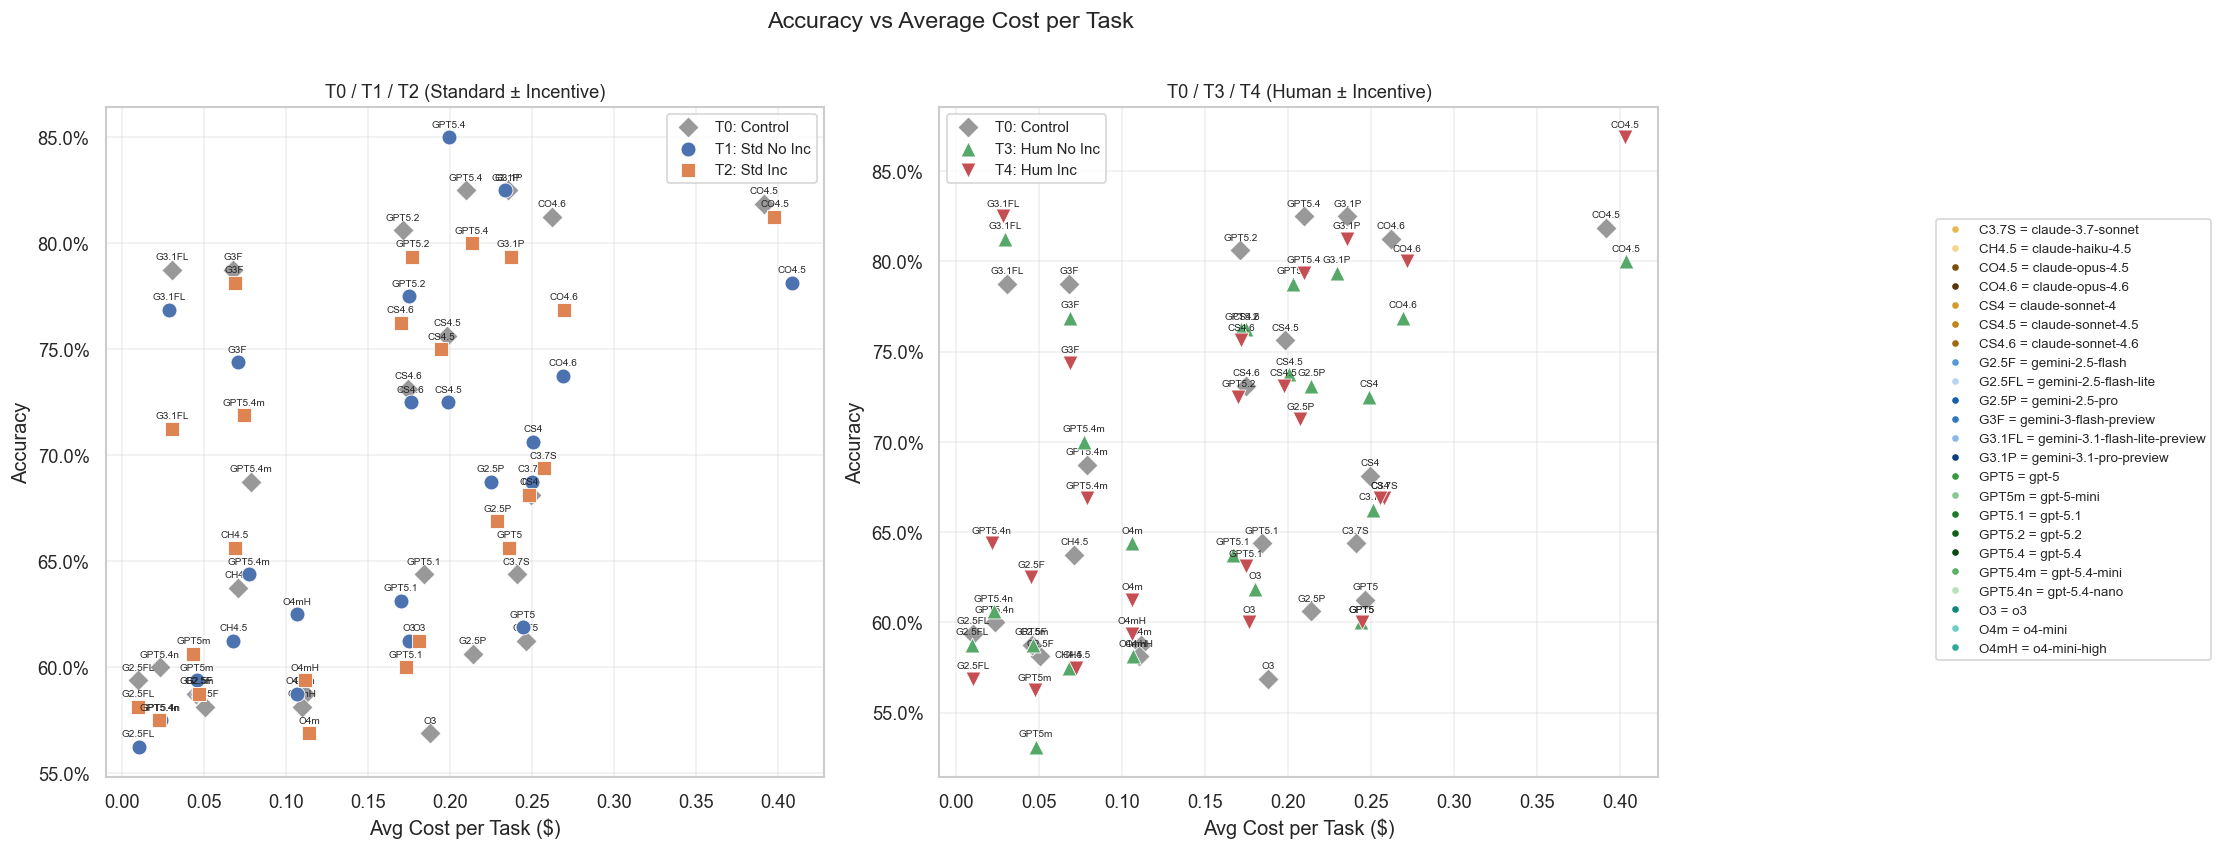

In [22]:
# Accuracy vs Cost per Task: two subplots
panels = {
    "T0 / T1 / T2 (Standard ± Incentive)": [
        "T0: Control",
        "T1: Std No Inc",
        "T2: Std Inc",
    ],
    "T0 / T3 / T4 (Human ± Incentive)": [
        "T0: Control",
        "T3: Hum No Inc",
        "T4: Hum Inc",
    ],
}

panel_markers = {
    "T0: Control": "D",
    "T1: Std No Inc": "o",
    "T2: Std Inc": "s",
    "T3: Hum No Inc": "^",
    "T4: Hum Inc": "v",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (title, treatments) in zip(axes, panels.items()):
    sub = grouped_df[grouped_df["treatment"].isin(treatments)]
    summary = (
        sub.groupby(["model_short", "treatment"], observed=True)
        .agg(accuracy=("accuracy", "mean"), avg_cost=("cost_per_game", "mean"))
        .reset_index()
    )
    for t in treatments:
        t_data = summary[summary["treatment"] == t]
        ax.scatter(
            t_data["avg_cost"],
            t_data["accuracy"],
            s=80,
            color=TREATMENT_COLORS[t],
            marker=panel_markers[t],
            label=t,
            zorder=3,
            edgecolors="white",
            linewidth=0.5,
        )
        for _, row in t_data.iterrows():
            ax.annotate(
                MODEL_ABBREV.get(row["model_short"], row["model_short"]),
                (row["avg_cost"], row["accuracy"]),
                fontsize=6,
                ha="center",
                va="bottom",
                xytext=(0, 5),
                textcoords="offset points",
            )
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_xlabel("Avg Cost per Task ($)")
    ax.set_ylabel("Accuracy")
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

fig.suptitle("Accuracy vs Average Cost per Task", fontsize=14, y=1.01)
model_abbrev_legend(
    fig, ncol=1, fontsize=8, loc="center left", bbox_to_anchor=(1.01, 0.5)
)
fig.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()

/var/folders/7n/zmfsnpmx1s173gkx77zlr_gw0000gn/T/ipykernel_98032/2493308850.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


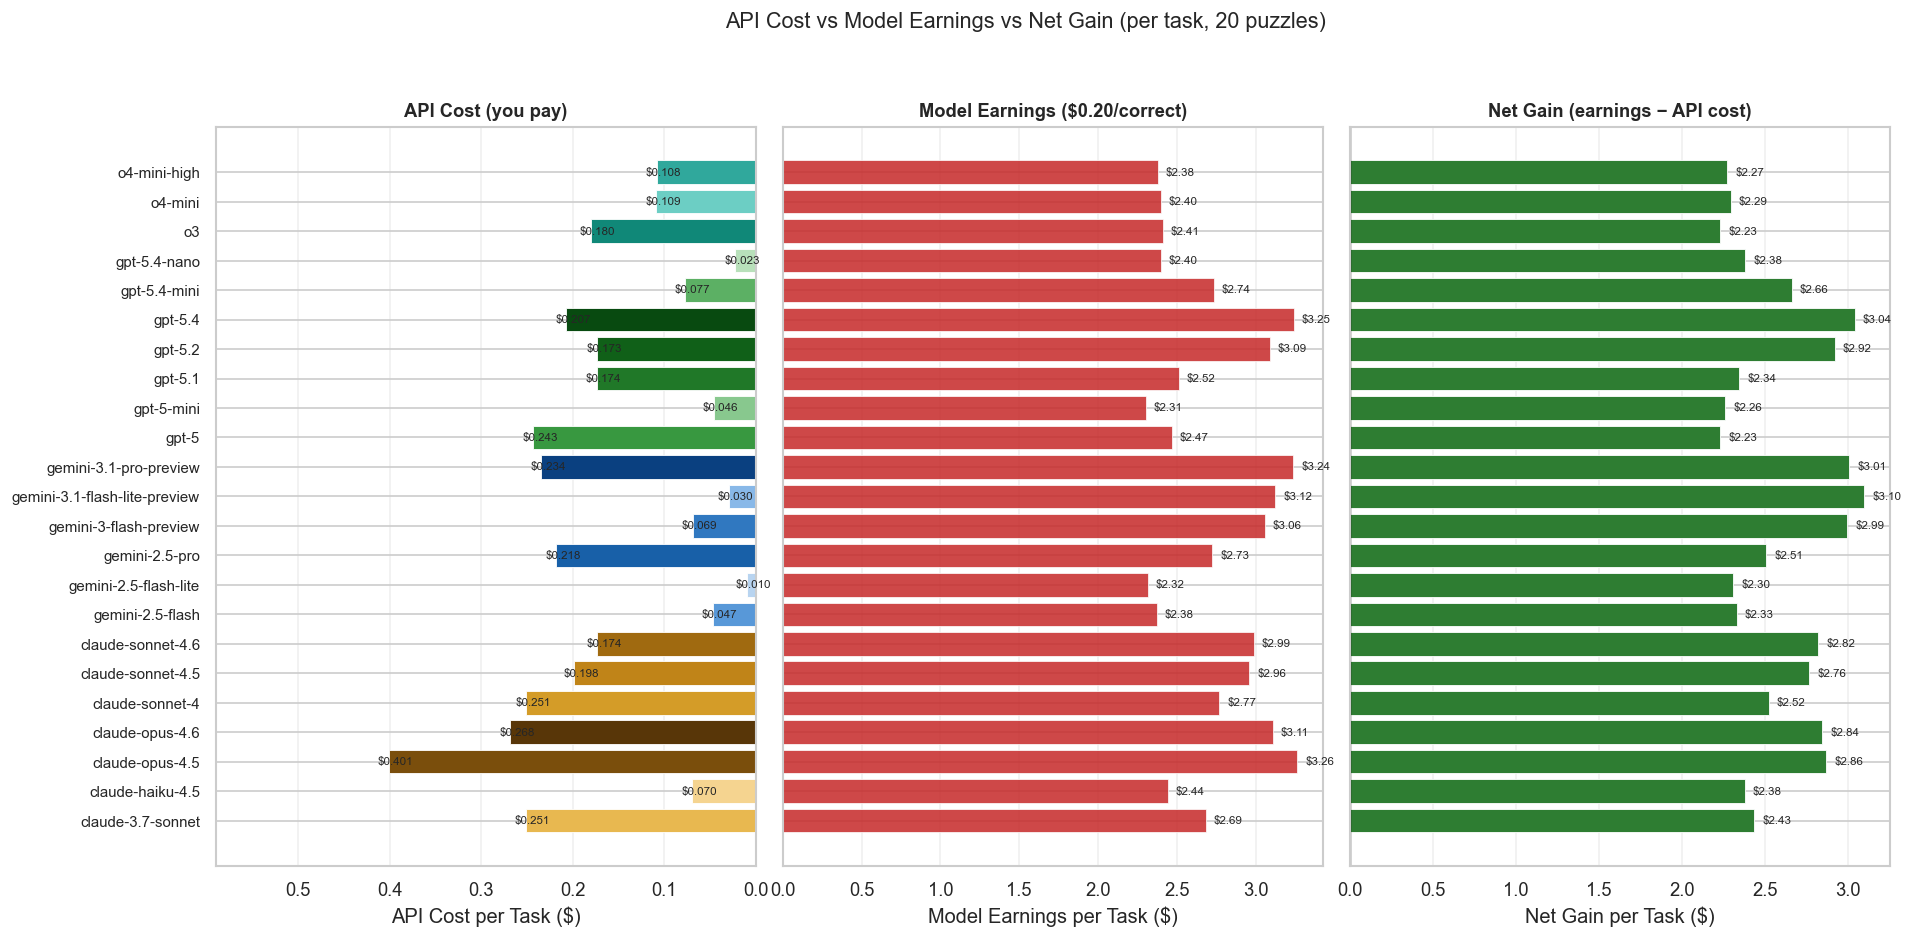

In [23]:
# API Cost vs Model Earnings vs Net Gain per task
# Left:   API cost to run 20 puzzles (what you pay the provider)
# Center: Model earnings at $0.50/correct
# Right:  Net gain = earnings - API cost

_cmp = grouped_df.copy()
_cmp["human_payout"] = _cmp["accuracy"] * _cmp["n_puzzles"] * 0.20

model_compare = _cmp.groupby("model_short", observed=True).agg(
    api_cost=("cost_per_game", "mean"),
    earnings=("human_payout", "mean"),
)
model_compare["net_gain"] = model_compare["earnings"] - model_compare["api_cost"]

family_order = sort_by_family(model_compare.index.tolist())
model_compare = model_compare.reindex(family_order)

fig, (ax_api, ax_earn, ax_net) = plt.subplots(
    1,
    3,
    figsize=(18, 8),
    sharey=True,
    gridspec_kw={"width_ratios": [1, 1, 1], "wspace": 0.05},
)

y = np.arange(len(model_compare))
bar_colors = [MODEL_COLORS.get(m, "#888888") for m in model_compare.index]

# ── Left: API cost (inverted x-axis) ──
ax_api.barh(
    y, model_compare["api_cost"], color=bar_colors, edgecolor="white", linewidth=0.5
)
ax_api.set_xlim(ax_api.get_xlim()[1] * 1.4, 0)
ax_api.set_xlabel("API Cost per Task ($)")
ax_api.set_title("API Cost (you pay)", fontsize=11, fontweight="bold")
ax_api.grid(axis="x", alpha=0.3)
for i, val in enumerate(model_compare["api_cost"]):
    ax_api.text(
        val + ax_api.get_xlim()[0] * 0.02,
        i,
        f"${val:.3f}",
        va="center",
        ha="left",
        fontsize=7,
    )

# ── Center: model earnings ──
ax_earn.barh(
    y,
    model_compare["earnings"],
    color="#C62828",
    edgecolor="white",
    linewidth=0.5,
    alpha=0.85,
)
ax_earn.set_xlabel("Model Earnings per Task ($)")
ax_earn.set_title("Model Earnings ($0.20/correct)", fontsize=11, fontweight="bold")
ax_earn.grid(axis="x", alpha=0.3)
for i, val in enumerate(model_compare["earnings"]):
    ax_earn.text(val + 0.05, i, f"${val:.2f}", va="center", fontsize=7)

# ── Right: net gain ──
net_colors = ["#2E7D32" if v >= 0 else "#C62828" for v in model_compare["net_gain"]]
ax_net.barh(
    y, model_compare["net_gain"], color=net_colors, edgecolor="white", linewidth=0.5
)
ax_net.set_xlabel("Net Gain per Task ($)")
ax_net.set_title("Net Gain (earnings \u2212 API cost)", fontsize=11, fontweight="bold")
ax_net.grid(axis="x", alpha=0.3)
ax_net.axvline(0, color="black", lw=0.8)
for i, val in enumerate(model_compare["net_gain"]):
    offset = 0.05 if val >= 0 else -0.05
    ha = "left" if val >= 0 else "right"
    ax_net.text(val + offset, i, f"${val:.2f}", va="center", ha=ha, fontsize=7)

ax_api.set_yticks(y)
ax_api.set_yticklabels(model_compare.index, fontsize=9)

fig.suptitle(
    "API Cost vs Model Earnings vs Net Gain (per task, 20 puzzles)", fontsize=13, y=1.0
)
fig.tight_layout()
plt.show()

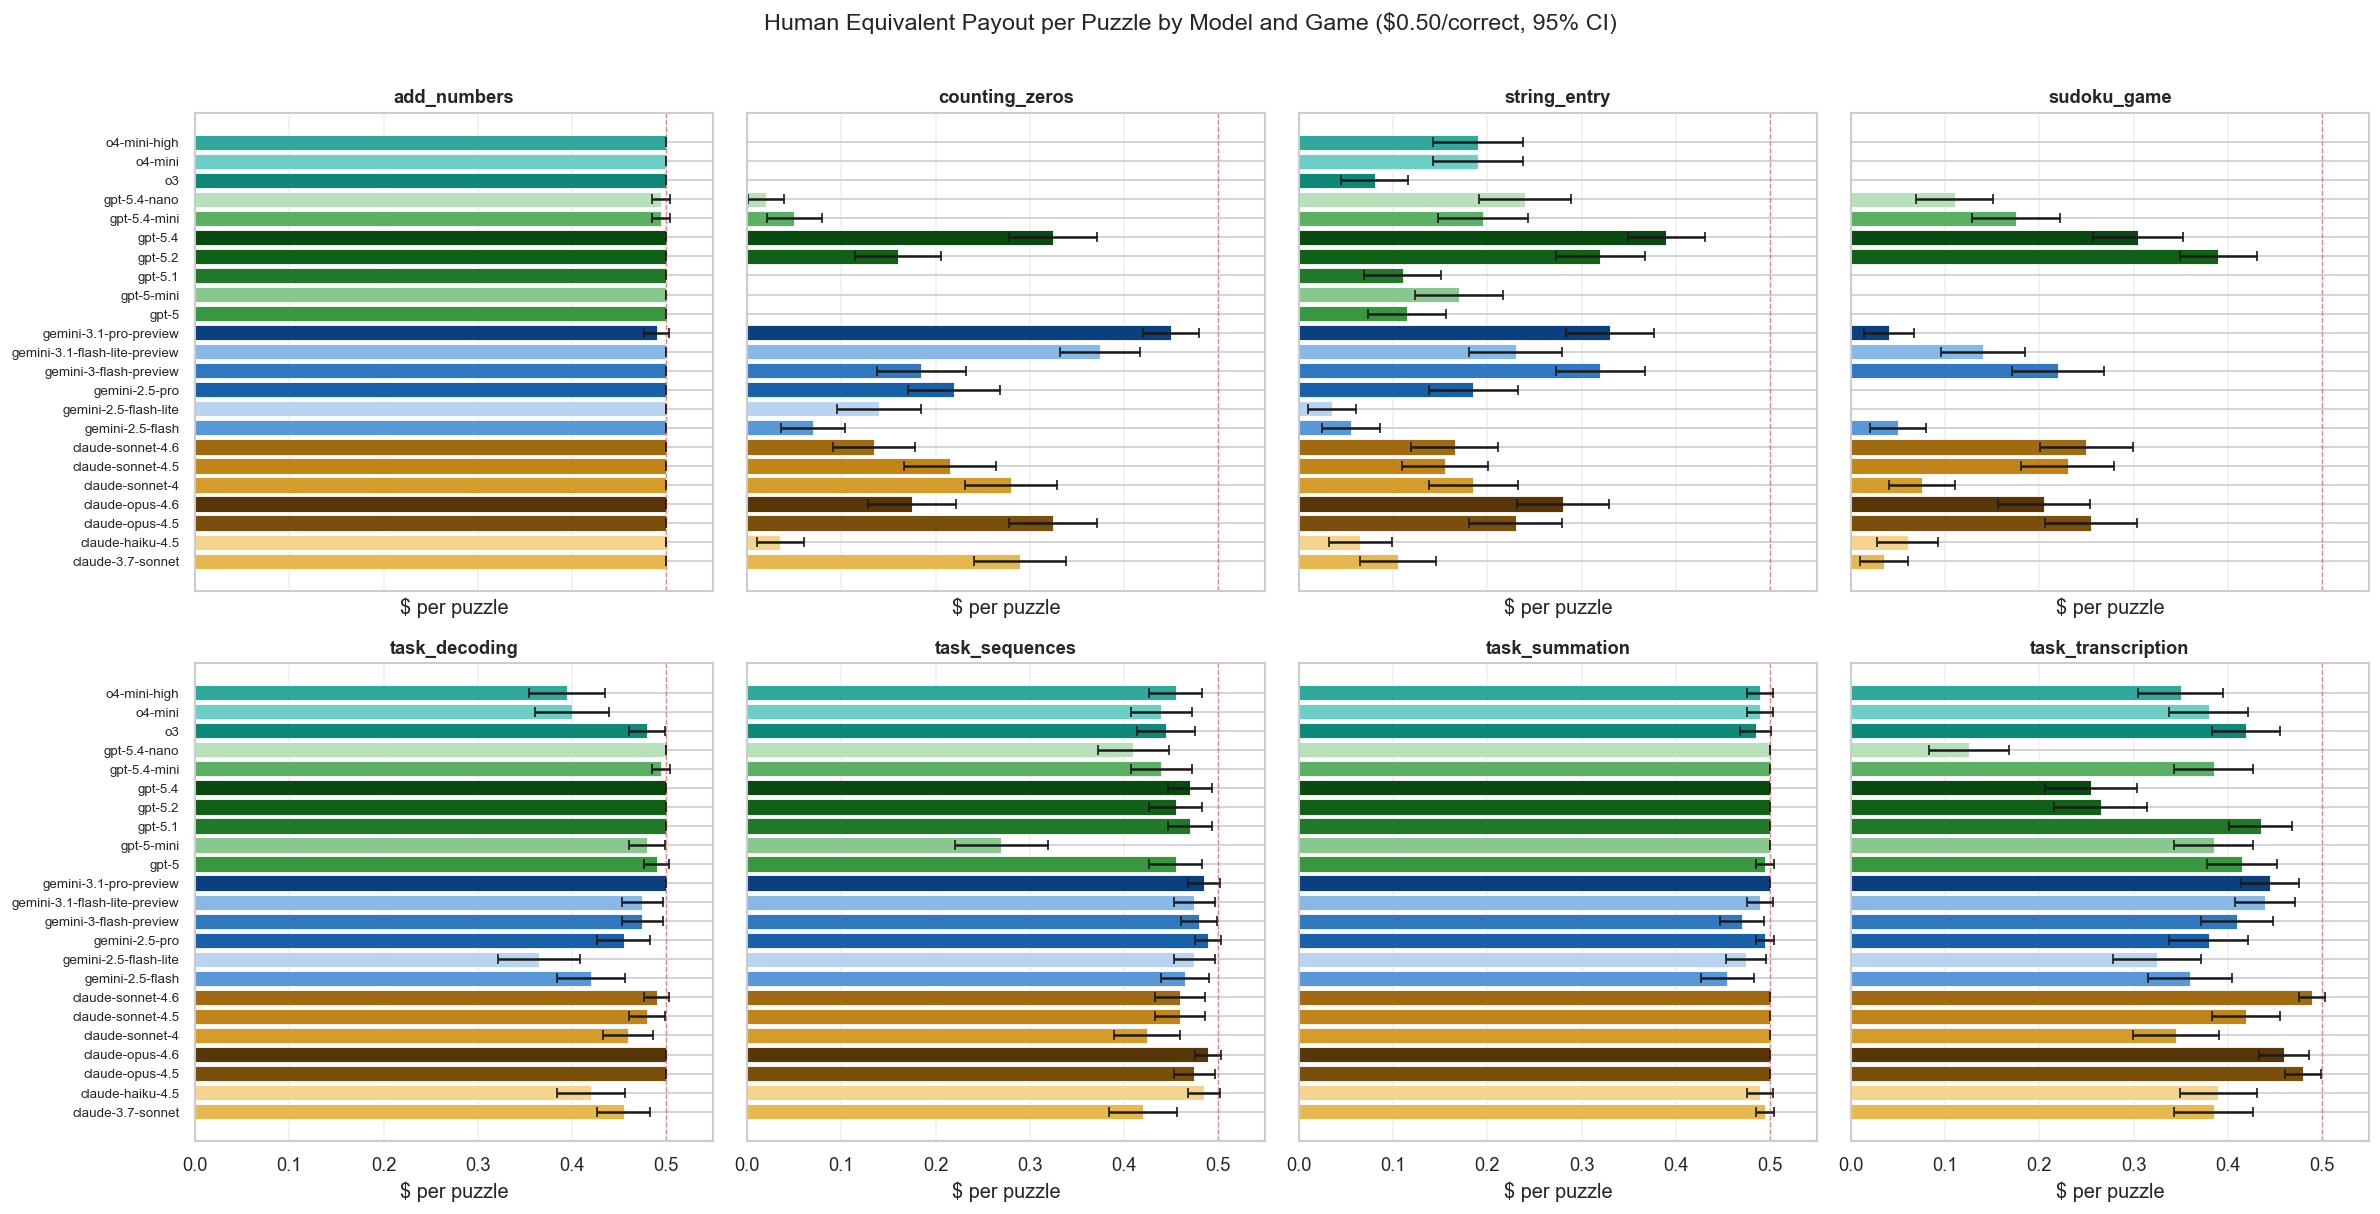

In [24]:
# Human Payout per Puzzle by Model × Game (pooled across treatments, 95% CI)
# Each puzzle pays $0.50 if correct, $0.00 otherwise

df["human_payout"] = df["is_correct"] * 0.50

# Per model × game: mean payout and 95% CI across all puzzle attempts
payout_stats = (
    df.groupby(["model_short", "game"], observed=True)["human_payout"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
payout_stats["se"] = payout_stats["std"] / np.sqrt(payout_stats["count"])
payout_stats["ci95"] = 1.96 * payout_stats["se"]

games = sorted(payout_stats["game"].unique())
family_order = sort_by_family(payout_stats["model_short"].unique().tolist())

ncols = 4
nrows = int(np.ceil(len(games) / ncols))
fig, axes = plt.subplots(
    nrows, ncols, figsize=(20, nrows * 5), sharey=True, sharex=True
)
axes = axes.flatten()

for idx, game in enumerate(games):
    ax = axes[idx]
    gdata = payout_stats[payout_stats["game"] == game].copy()
    gdata = gdata.set_index("model_short").reindex(family_order).dropna(subset=["mean"])

    y = np.arange(len(gdata))
    bar_colors = [MODEL_COLORS.get(m, "#888888") for m in gdata.index]

    ax.barh(
        y,
        gdata["mean"],
        xerr=gdata["ci95"],
        capsize=3,
        color=bar_colors,
        edgecolor="white",
        linewidth=0.5,
    )
    ax.set_yticks(y)
    ax.set_yticklabels(gdata.index, fontsize=8)
    ax.set_title(game, fontsize=11, fontweight="bold")
    ax.set_xlim(0, 0.55)
    ax.axvline(0.50, color="#C62828", ls="--", lw=0.8, alpha=0.5)
    ax.set_xlabel("$ per puzzle")
    ax.grid(axis="x", alpha=0.3)

# Hide unused panels
for idx in range(len(games), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle(
    "Human Equivalent Payout per Puzzle by Model and Game ($0.50/correct, 95% CI)",
    fontsize=14,
    y=1.01,
)
fig.tight_layout()
plt.show()

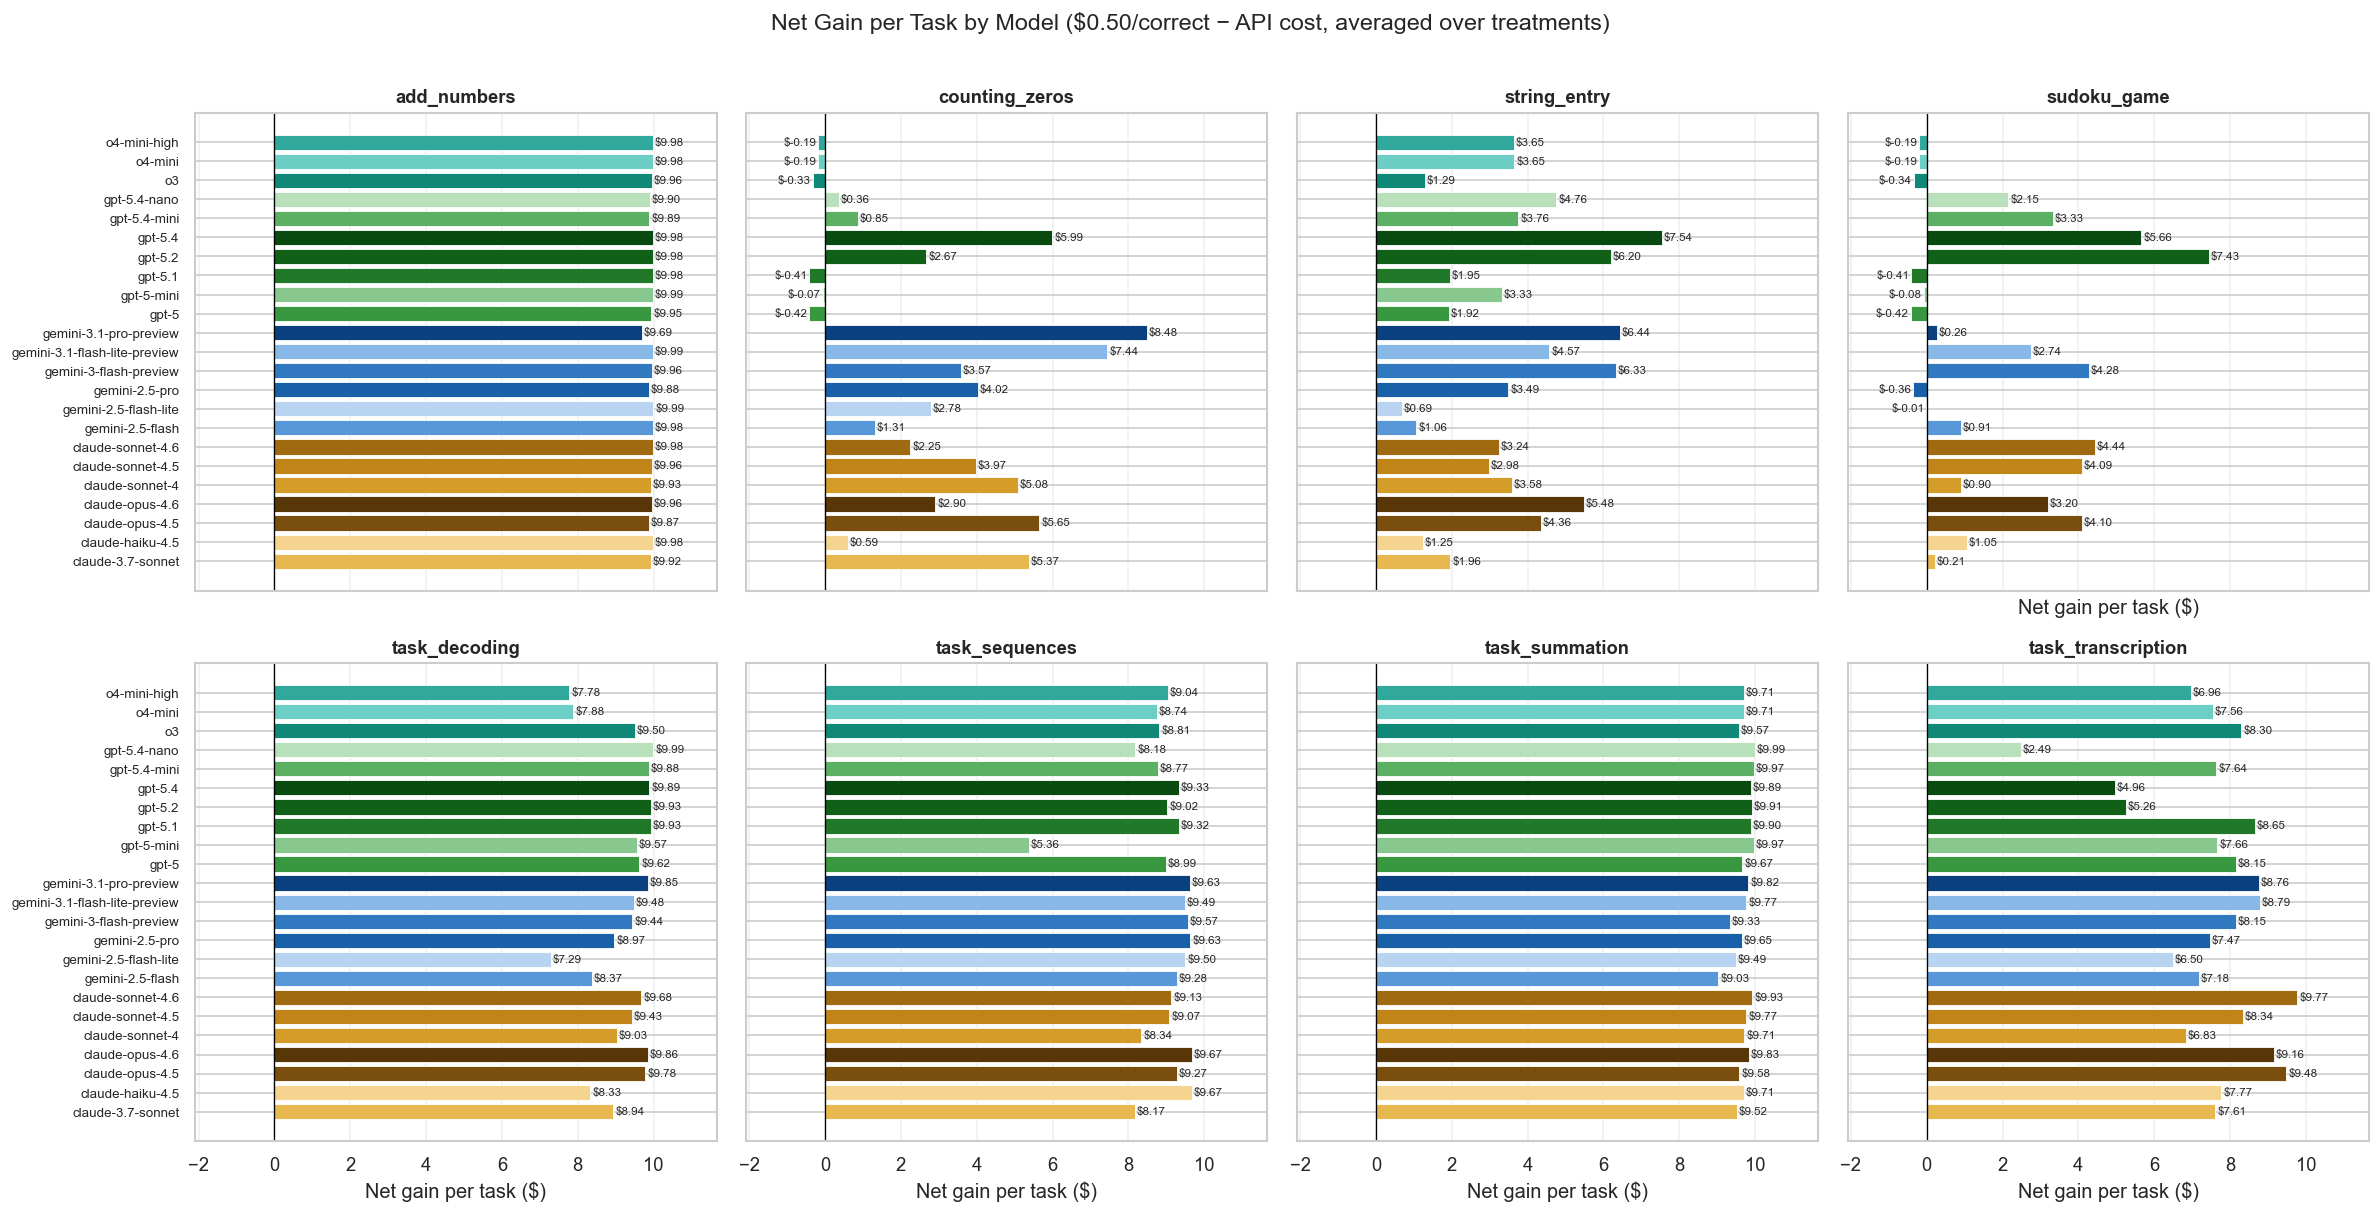

In [25]:
# Net Gain per Task by Model × Game (earnings − API cost, averaged over treatments)
# Per game = sum over 20 puzzles: total earnings ($0.50 × n_correct) − total API cost

_ng = grouped_df.copy()
_ng["net_gain"] = _ng["accuracy"] * _ng["n_puzzles"] * 0.50 - _ng["cost_per_game"]

net_model_game = (
    _ng.groupby(["model_short", "game"], observed=True)["net_gain"].mean().reset_index()
)

games = sorted(net_model_game["game"].unique())
family_order = sort_by_family(net_model_game["model_short"].unique().tolist())

ncols = 4
nrows = int(np.ceil(len(games) / ncols))
fig, axes = plt.subplots(
    nrows, ncols, figsize=(20, nrows * 5), sharey=True, sharex=True
)
axes = axes.flatten()

xmin, xmax = 0.0, 0.0
for idx, game in enumerate(games):
    ax = axes[idx]
    gdata = net_model_game[net_model_game["game"] == game].copy()
    gdata = (
        gdata.set_index("model_short").reindex(family_order).dropna(subset=["net_gain"])
    )

    y = np.arange(len(gdata))
    bar_colors = [MODEL_COLORS.get(m, "#888888") for m in gdata.index]

    ax.barh(y, gdata["net_gain"], color=bar_colors, edgecolor="white", linewidth=0.5)
    ax.set_yticks(y)
    ax.set_yticklabels(gdata.index, fontsize=8)
    ax.set_title(game, fontsize=11, fontweight="bold")
    ax.axvline(0, color="black", lw=0.8)
    if idx >= 3:
        ax.set_xlabel("Net gain per task ($)")
    ax.grid(axis="x", alpha=0.3)

    for i, val in enumerate(gdata["net_gain"]):
        offset = 0.05 if val >= 0 else -0.05
        ha = "left" if val >= 0 else "right"
        ax.text(val + offset, i, f"${val:.2f}", va="center", ha=ha, fontsize=7)

    # Add margins so annotations fit
    _xmin, _xmax = ax.get_xlim()
    if _xmin < xmin:
        xmin = _xmin
    if _xmax > xmax:
        xmax = _xmax

margin = (xmax - xmin) * 0.1
for ax in axes:
    ax.set_xlim(xmin - margin, xmax + margin)

fig.suptitle(
    "Net Gain per Task by Model ($0.50/correct \u2212 API cost, averaged over treatments)",
    fontsize=14,
    y=1.01,
)
fig.tight_layout()
plt.show()

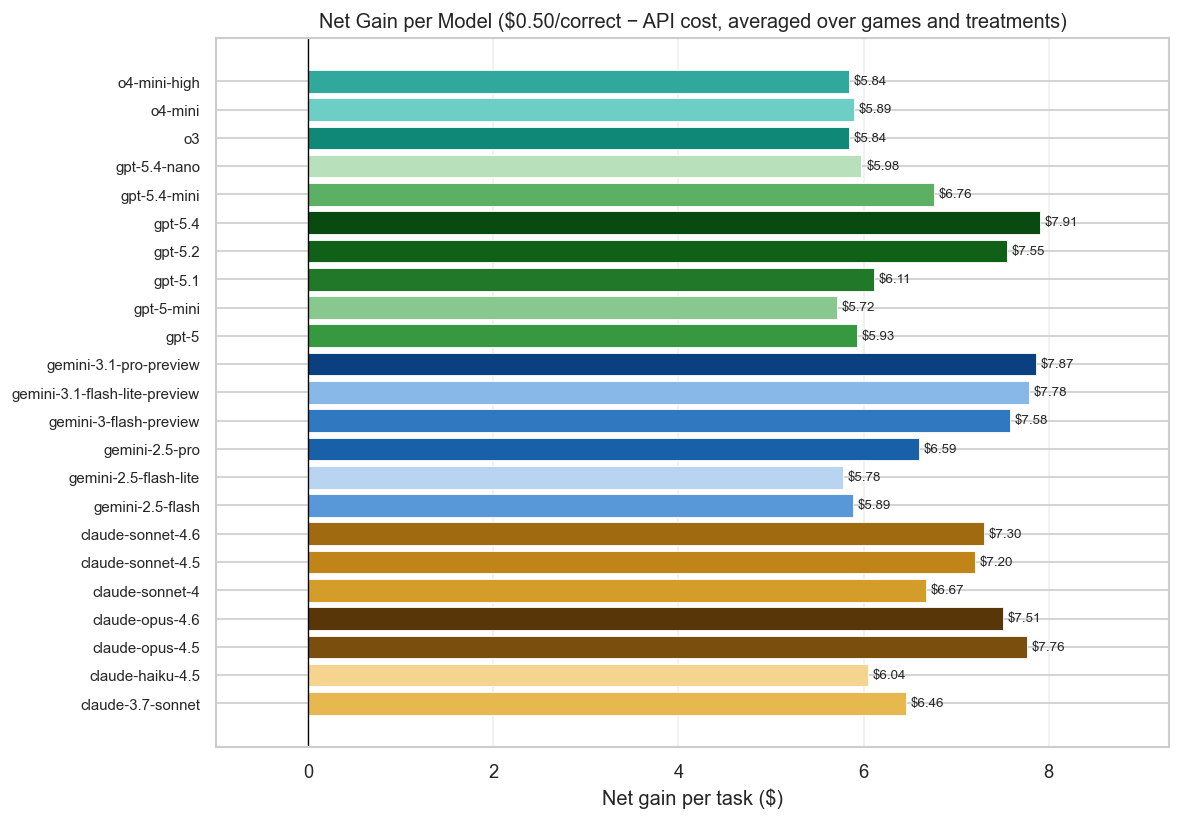

In [26]:
# Net Gain per Model (averaged over games and treatments)

_ng2 = grouped_df.copy()
_ng2["net_gain"] = _ng2["accuracy"] * _ng2["n_puzzles"] * 0.50 - _ng2["cost_per_game"]

net_model = (
    _ng2.groupby("model_short", observed=True)["net_gain"]
    .mean()
    .reindex(sort_by_family(_ng2["model_short"].unique().tolist()))
)

fig, ax = plt.subplots(figsize=(10, 7))
y = np.arange(len(net_model))
bar_colors = [MODEL_COLORS.get(m, "#888888") for m in net_model.index]

ax.barh(y, net_model.values, color=bar_colors, edgecolor="white", linewidth=0.5)
ax.set_yticks(y)
ax.set_yticklabels(net_model.index, fontsize=9)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Net gain per task ($)")
ax.set_title(
    "Net Gain per Model ($0.50/correct \u2212 API cost, averaged over games and treatments)",
    fontsize=12,
)
ax.grid(axis="x", alpha=0.3)

for i, val in enumerate(net_model.values):
    offset = 0.05 if val >= 0 else -0.05
    ha = "left" if val >= 0 else "right"
    ax.text(val + offset, i, f"${val:.2f}", va="center", ha=ha, fontsize=8)

# Add margins so annotations aren't clipped
xmin, xmax = ax.get_xlim()
margin = (xmax - xmin) * 0.12
ax.set_xlim(xmin - margin, xmax + margin)

fig.tight_layout()
plt.show()

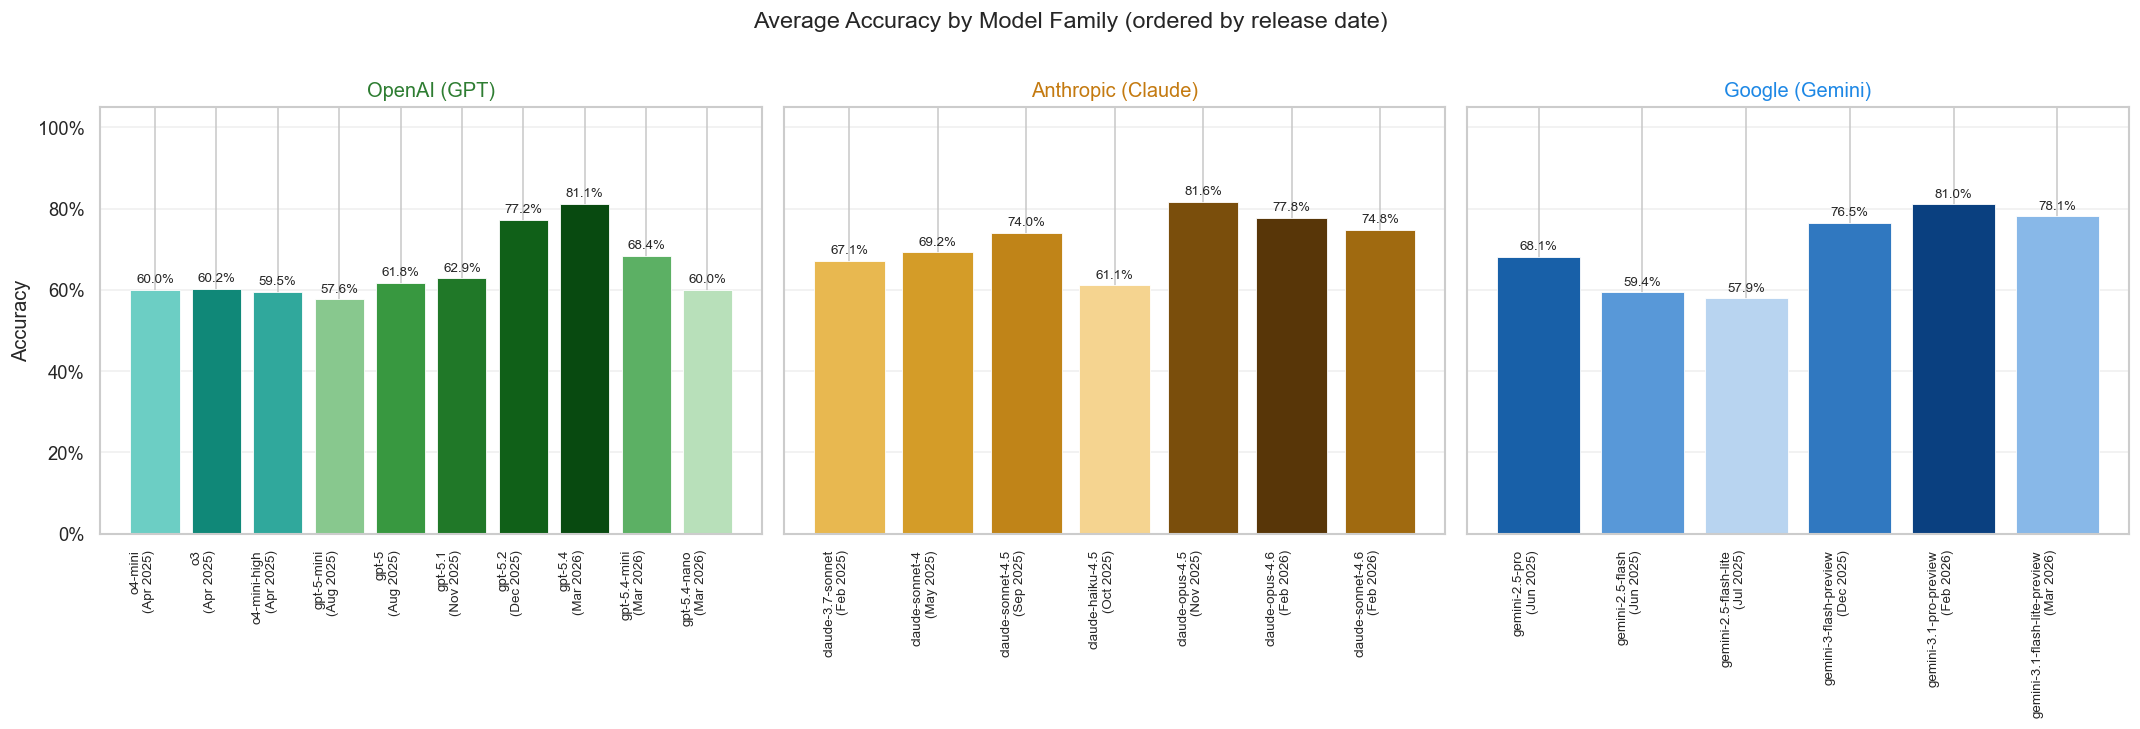

In [27]:
# Model release dates (unix timestamps from OpenRouter API, fetched 2026-03-23)
import datetime

MODEL_RELEASE_TS = {
    "claude-3.7-sonnet": 1740422110,
    "claude-sonnet-4": 1747930371,
    "claude-haiku-4.5": 1760547638,
    "claude-sonnet-4.5": 1759161676,
    "claude-opus-4.5": 1764010580,
    "claude-opus-4.6": 1770219050,
    "claude-sonnet-4.6": 1771342990,
    "gemini-2.5-flash": 1750172488,
    "gemini-2.5-flash-lite": 1753200276,
    "gemini-2.5-pro": 1750169544,
    "gemini-3-flash-preview": 1765987078,
    "gemini-3.1-flash-lite-preview": 1772512673,
    "gemini-3.1-pro-preview": 1771509627,
    "o3": 1744823457,
    "o4-mini": 1744820942,
    "o4-mini-high": 1744824212,
    "gpt-5-mini": 1754587407,
    "gpt-5": 1754587413,
    "gpt-5.1": 1763060305,
    "gpt-5.2": 1765389775,
    "gpt-5.4": 1772734352,
    "gpt-5.4-mini": 1773748178,
    "gpt-5.4-nano": 1773748187,
}

MODEL_RELEASE_DATE = {
    m: datetime.datetime.fromtimestamp(ts) for m, ts in MODEL_RELEASE_TS.items()
}

# Split by family
families = {
    "OpenAI (GPT)": [
        m
        for m in MODEL_RELEASE_DATE
        if m.startswith("gpt-") or m.startswith("o3") or m.startswith("o4")
    ],
    "Anthropic (Claude)": [m for m in MODEL_RELEASE_DATE if m.startswith("claude-")],
    "Google (Gemini)": [m for m in MODEL_RELEASE_DATE if m.startswith("gemini-")],
}

# Sort each family by release date
for fam in families:
    families[fam] = sorted(families[fam], key=lambda m: MODEL_RELEASE_TS[m])

# Compute per-model accuracy (all treatments averaged)
model_accuracy = df.groupby("model_short", observed=True)["is_correct"].mean()

family_colors = {
    "OpenAI (GPT)": "#2E7D32",
    "Anthropic (Claude)": "#C47A10",
    "Google (Gemini)": "#1E88E5",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, (fam_name, models) in zip(axes, families.items()):
    accs = [model_accuracy.get(m, 0) for m in models]
    dates = [MODEL_RELEASE_DATE[m].strftime("%b %Y") for m in models]
    labels = [f"{m}\n({d})" for m, d in zip(models, dates)]
    bar_colors = [MODEL_COLORS.get(m, "#888888") for m in models]

    bars = ax.bar(
        range(len(models)), accs, color=bar_colors, edgecolor="white", linewidth=0.5
    )
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(labels, rotation=90, ha="right", fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_ylabel("Accuracy" if ax == axes[0] else "")
    ax.set_title(fam_name, fontsize=12, color=family_colors[fam_name])
    ax.grid(axis="y", alpha=0.3)

    for bar, val in zip(bars, accs):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{val:.1%}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

fig.suptitle(
    "Average Accuracy by Model Family (ordered by release date)", fontsize=14, y=1.01
)
fig.tight_layout()
plt.show()

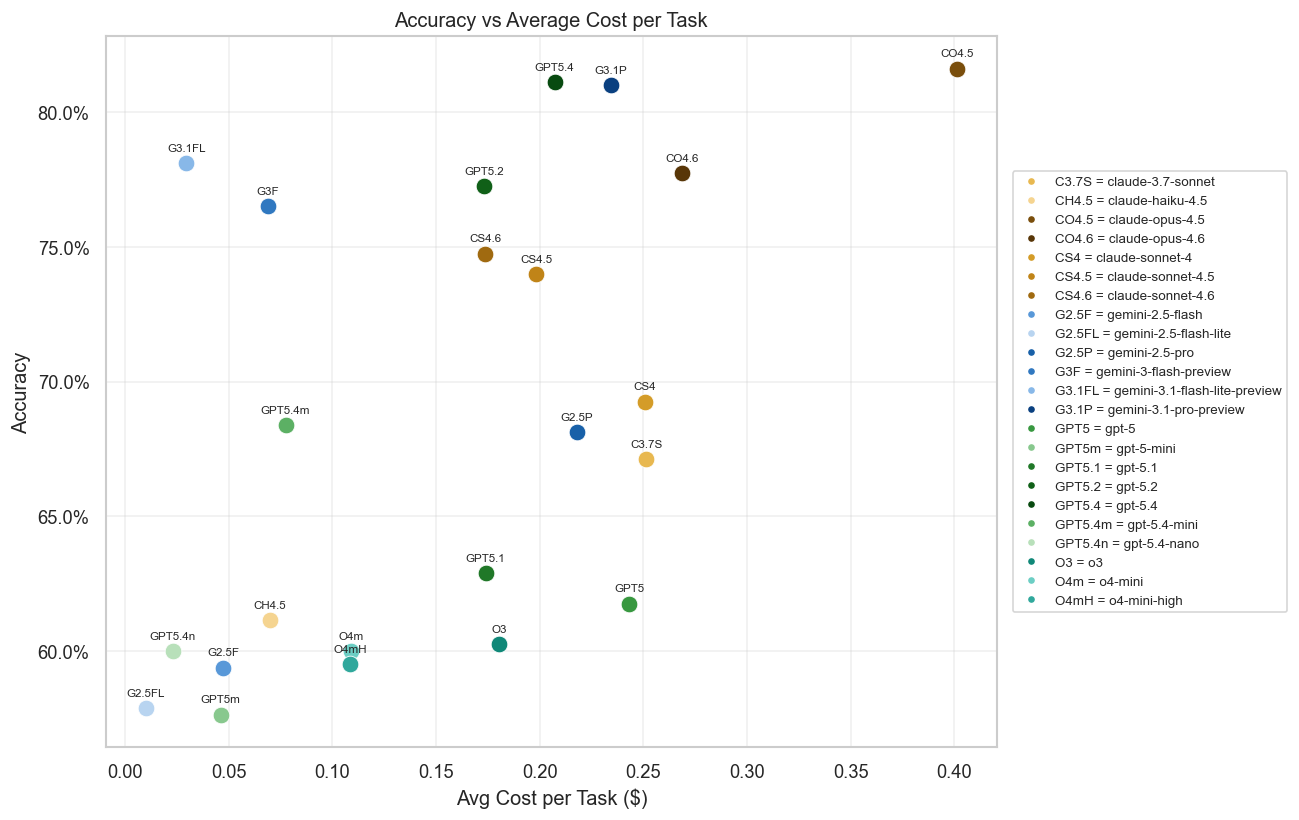

In [28]:
# Accuracy vs Average Cost per Task (all treatments averaged)
model_cost_avg = grouped_df.groupby("model_short", observed=True)[
    "cost_per_game"
].mean()
model_acc_avg = grouped_df.groupby("model_short", observed=True)["accuracy"].mean()

fig, ax = plt.subplots(figsize=(11, 7))

for m in model_cost_avg.index:
    ax.scatter(
        model_cost_avg[m],
        model_acc_avg[m],
        s=100,
        color=MODEL_COLORS.get(m, "#888888"),
        edgecolors="white",
        linewidth=0.5,
        zorder=3,
    )
    ax.annotate(
        MODEL_ABBREV.get(m, m),
        (model_cost_avg[m], model_acc_avg[m]),
        fontsize=7,
        ha="center",
        va="bottom",
        xytext=(0, 6),
        textcoords="offset points",
    )

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("Avg Cost per Task ($)")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs Average Cost per Task")
ax.grid(alpha=0.3)
model_abbrev_legend(
    ax, ncol=1, fontsize=8, loc="center left", bbox_to_anchor=(1.01, 0.5)
)
fig.tight_layout()
plt.show()

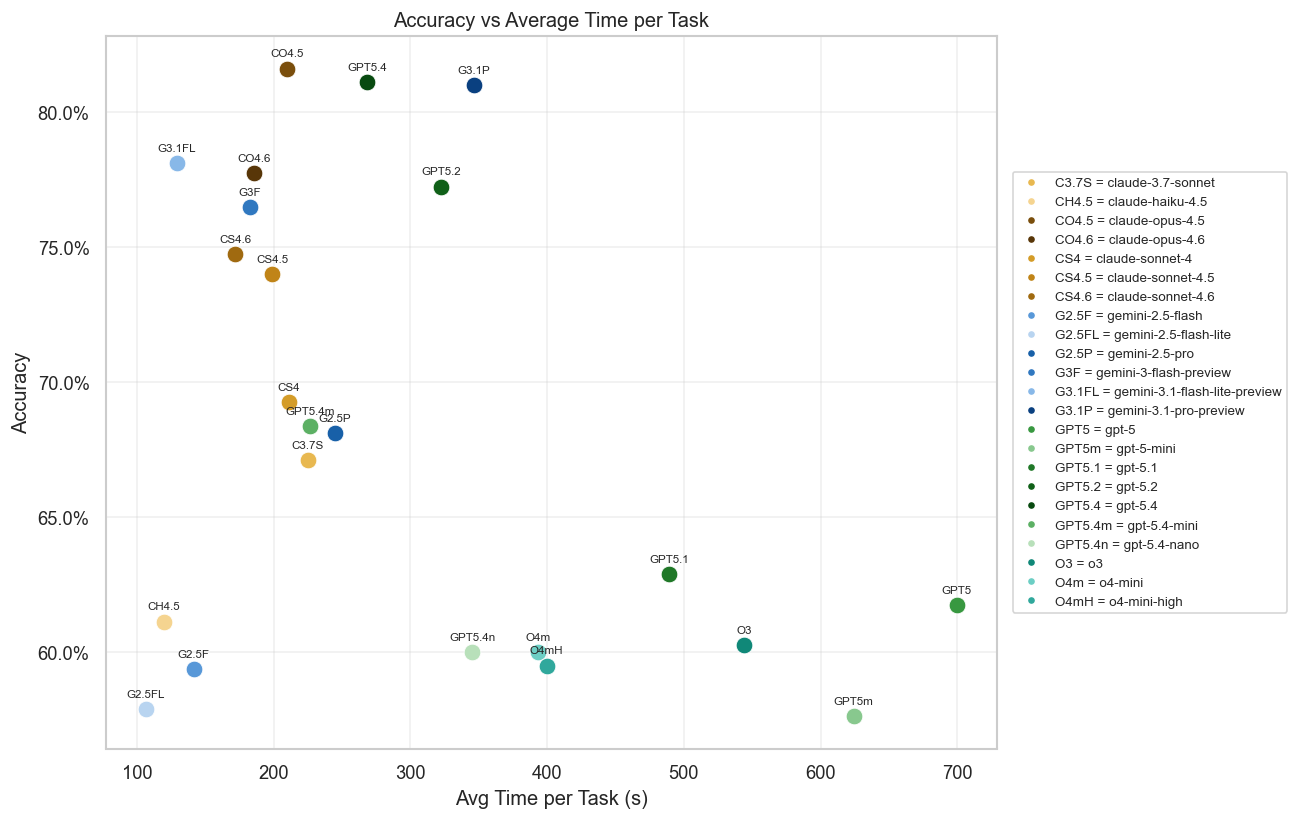

In [29]:
# Accuracy vs Average Cost per Task (all treatments averaged)
model_cost_avg = grouped_df.groupby("model_short", observed=True)["total_time"].mean()
model_acc_avg = grouped_df.groupby("model_short", observed=True)["accuracy"].mean()

fig, ax = plt.subplots(figsize=(11, 7))

for m in model_cost_avg.index:
    ax.scatter(
        model_cost_avg[m],
        model_acc_avg[m],
        s=100,
        color=MODEL_COLORS.get(m, "#888888"),
        edgecolors="white",
        linewidth=0.5,
        zorder=3,
    )
    ax.annotate(
        MODEL_ABBREV.get(m, m),
        (model_cost_avg[m], model_acc_avg[m]),
        fontsize=7,
        ha="center",
        va="bottom",
        xytext=(0, 6),
        textcoords="offset points",
    )

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("Avg Time per Task (s)")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs Average Time per Task")
ax.grid(alpha=0.3)
model_abbrev_legend(
    ax, ncol=1, fontsize=8, loc="center left", bbox_to_anchor=(1.01, 0.5)
)
fig.tight_layout()
plt.show()

## Task Difficulty Ranking

Which tasks are hardest for LLMs? Averaged across all models and treatments.

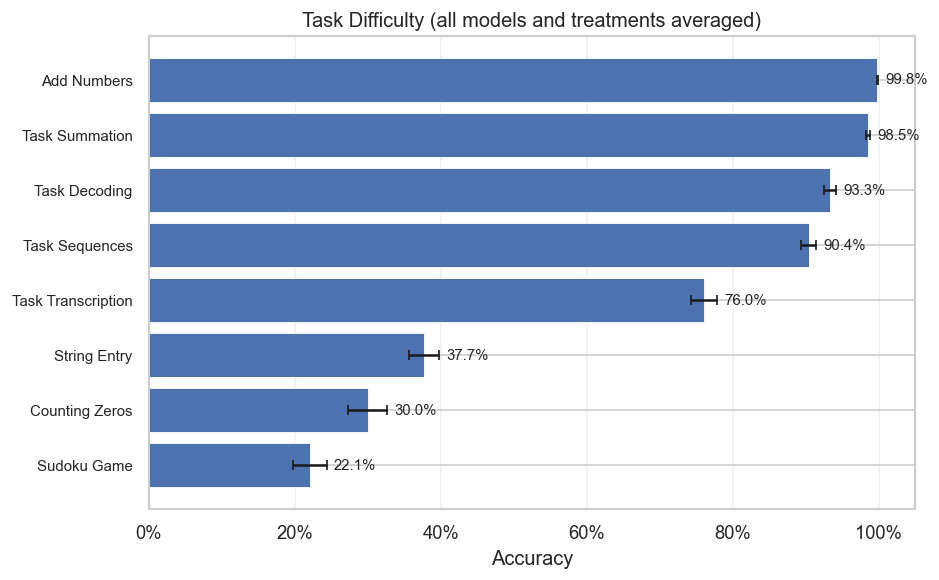

In [30]:
# Task difficulty: average accuracy per task (across all models and treatments)
game_difficulty = (
    grouped_df.groupby("game", observed=True)["accuracy"]
    .agg(["mean", "std", "count"])
    .sort_values("mean", ascending=True)
)
game_difficulty["se"] = game_difficulty["std"] / np.sqrt(game_difficulty["count"])

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(
    range(len(game_difficulty)),
    game_difficulty["mean"],
    xerr=game_difficulty["se"],
    capsize=3,
    color="#4C72B0",
    edgecolor="white",
    linewidth=0.5,
)
ax.set_yticks(range(len(game_difficulty)))
ax.set_yticklabels(
    [g.replace("_", " ").title() for g in game_difficulty.index], fontsize=9
)
ax.set_xlim(0, 1.05)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("Accuracy")
ax.set_title("Task Difficulty (all models and treatments averaged)")
ax.grid(axis="x", alpha=0.3)

for i, (val, se) in enumerate(zip(game_difficulty["mean"], game_difficulty["se"])):
    ax.text(val + se + 0.01, i, f"{val:.1%}", va="center", fontsize=9)

fig.tight_layout()
plt.show()

## String Entry Error Analysis

Why do models fail at the string entry task (~38% accuracy)? This section analyzes character-level errors, confusion patterns, and the role of spaces.

String entry: 2300 puzzles, 868 correct (37.7%)
With backslash normalization: 948 correct (41.2%), +80 rescued
Wrong answers (after backslash norm): 1352

Length mismatches in wrong answers:
  correct_length: 114 (8%)
  too_short: 848 (63%)
  too_long: 390 (29%)

Per-character error rate (position-aligned, wrong answers only):
 char  errors  total  error_rate
SPACE     694   1115    0.622422
    \     452    993    0.455186
    _     475   1141    0.416301
    /     501   1205    0.415768
    <     450   1112    0.404676
    (     480   1209    0.397022
    )     432   1091    0.395967


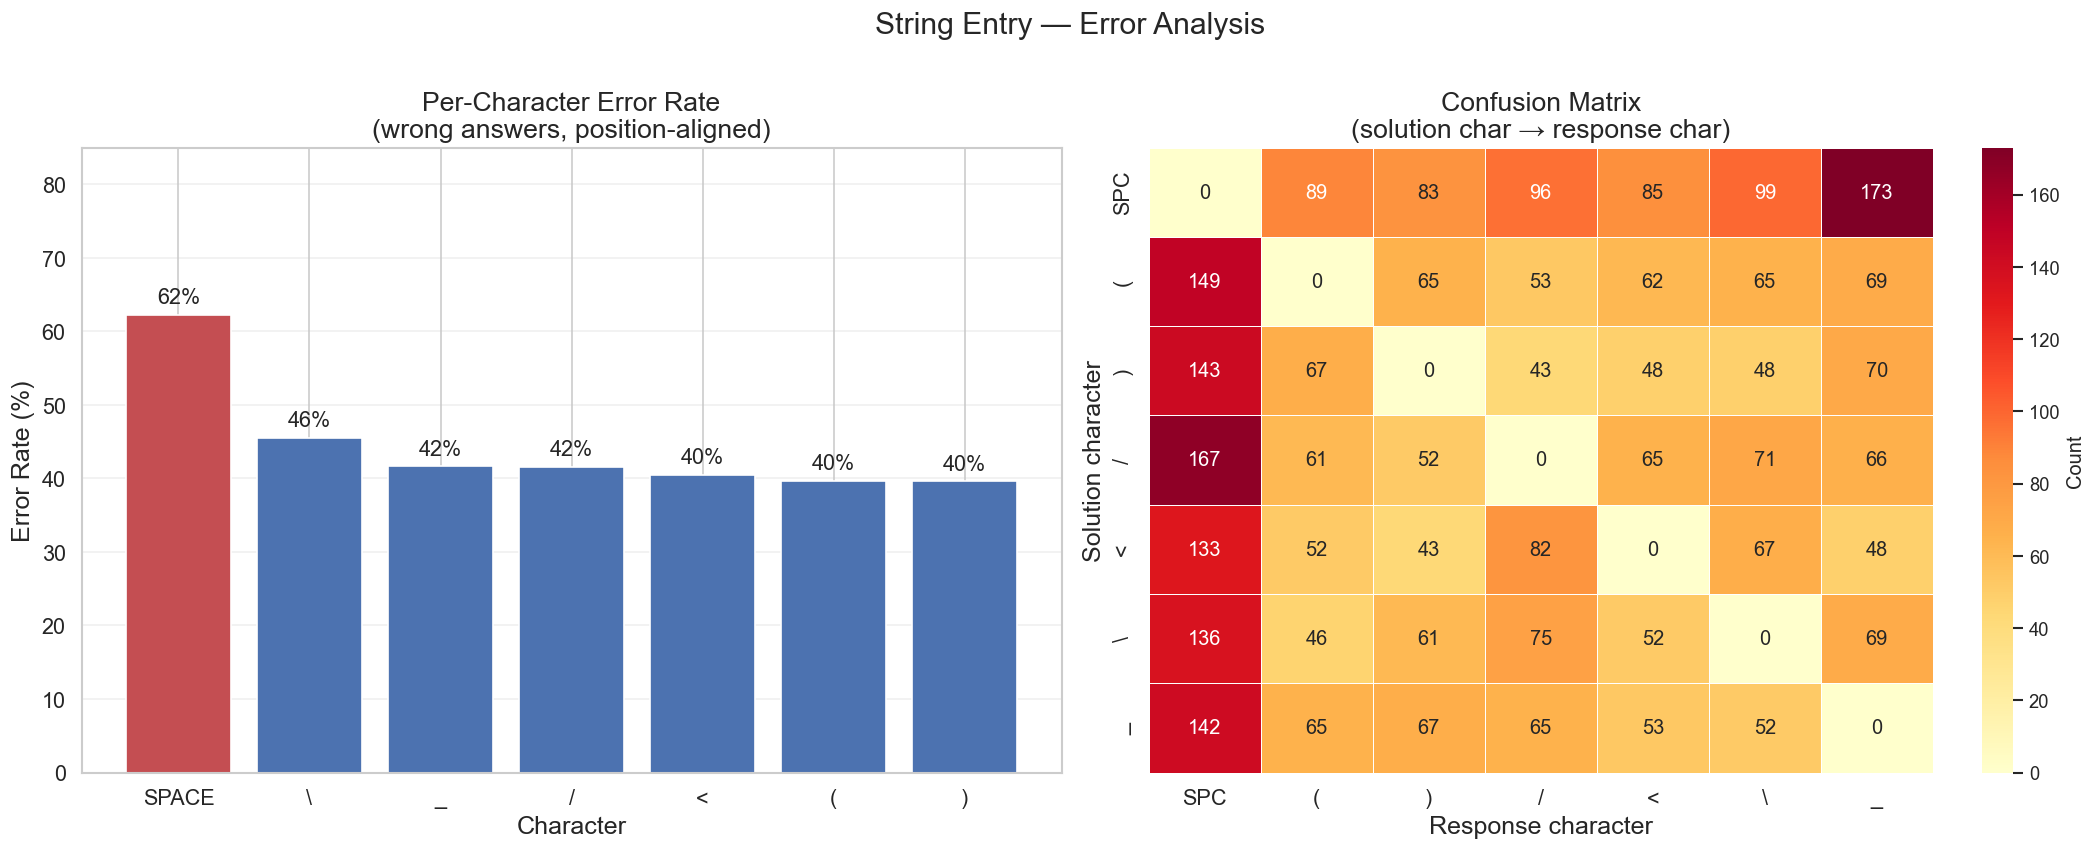


── Per-model accuracy on string_entry ──
                               strict  with_bs_norm    n  delta_pp
model_short                                                       
gpt-5.4                          0.78          0.78  100       0.0
gemini-3.1-pro-preview           0.66          0.67  100       1.0
gpt-5.2                          0.64          0.64  100       0.0
gemini-3-flash-preview           0.64          0.64  100       0.0
claude-opus-4.6                  0.56          0.57  100       1.0
claude-sonnet-4                  0.37          0.54  100      17.0
gpt-5.4-nano                     0.48          0.49  100       1.0
gemini-3.1-flash-lite-preview    0.46          0.46  100       0.0
claude-opus-4.5                  0.46          0.46  100       0.0
gpt-5.4-mini                     0.39          0.43  100       4.0
claude-sonnet-4.5                0.31          0.42  100      11.0
gemini-2.5-pro                   0.37          0.42  100       5.0
o4-mini             

In [31]:
# ── String Entry: character-level error analysis ──
from collections import Counter

se_df = df[df["game"] == "string_entry"].copy()


# Normalize escaped backslashes: models often respond with \\ instead of \
def _normalize_backslash(s):
    """Collapse double-backslash escapes to single backslash."""
    return str(s).replace("\\\\", "\\")


def _normalize_spaces(s):
    """Treat space, underscore, and ␣ (open box) as equivalent."""
    return str(s).replace("\u2423", " ").replace("_", " ")


se_df["response_norm"] = se_df["response"].apply(
    lambda r: _normalize_backslash(r or "")
)
se_df["solution_norm"] = se_df["solution"].apply(
    lambda s: _normalize_backslash(s or "")
)

# Recheck correctness with backslash + space normalization
se_df["correct_with_bs"] = se_df.apply(
    lambda r: int(
        _normalize_spaces(r["response_norm"]) == _normalize_spaces(r["solution_norm"])
    ),
    axis=1,
)

bs_rescued = se_df["correct_with_bs"].sum() - se_df["is_correct"].sum()
print(
    f"String entry: {len(se_df)} puzzles, {se_df['is_correct'].sum()} correct ({se_df['is_correct'].mean():.1%})"
)
print(
    f"With backslash normalization: {se_df['correct_with_bs'].sum()} correct ({se_df['correct_with_bs'].mean():.1%}), +{bs_rescued} rescued"
)

se_wrong = se_df[se_df["correct_with_bs"] == 0].copy()
print(f"Wrong answers (after backslash norm): {len(se_wrong)}")

# ── 1. Length mismatch analysis ──
length_stats = {"correct_length": 0, "too_short": 0, "too_long": 0}
for _, row in se_wrong.iterrows():
    sol = row["solution_norm"]
    resp = row["response_norm"]
    if len(resp) == len(sol):
        length_stats["correct_length"] += 1
    elif len(resp) < len(sol):
        length_stats["too_short"] += 1
    else:
        length_stats["too_long"] += 1

print(f"\nLength mismatches in wrong answers:")
for k, v in length_stats.items():
    print(f"  {k}: {v} ({v/max(len(se_wrong),1):.0%})")

# ── 2. Per-character error rate ──
char_errors = Counter()
char_totals = Counter()
confusion = Counter()

for _, row in se_wrong.iterrows():
    sol = row["solution_norm"]
    resp = row["response_norm"]
    for i in range(min(len(sol), len(resp))):
        char_totals[sol[i]] += 1
        if sol[i] != resp[i]:
            char_errors[sol[i]] += 1
            confusion[(sol[i], resp[i])] += 1

charset = sorted(
    char_totals.keys(),
    key=lambda c: char_errors.get(c, 0) / max(char_totals[c], 1),
    reverse=True,
)
error_rate_data = []
for ch in charset:
    rate = char_errors.get(ch, 0) / char_totals[ch] if char_totals[ch] > 0 else 0
    label = "SPACE" if ch == " " else ch
    error_rate_data.append(
        {
            "char": label,
            "errors": char_errors.get(ch, 0),
            "total": char_totals[ch],
            "error_rate": rate,
        }
    )

error_rate_df = pd.DataFrame(error_rate_data)
print("\nPer-character error rate (position-aligned, wrong answers only):")
print(error_rate_df.to_string(index=False))

# ── 3. Plot: per-character error rate ──
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: bar chart of error rates per character
ax = axes[0]
colors = [
    "#C44E52" if row["char"] == "SPACE" else "#4C72B0"
    for _, row in error_rate_df.iterrows()
]
bars = ax.bar(
    error_rate_df["char"],
    error_rate_df["error_rate"] * 100,
    color=colors,
    edgecolor="white",
)
for bar, val in zip(bars, error_rate_df["error_rate"] * 100):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{val:.0f}%",
        ha="center",
        va="bottom",
        fontsize=13,
    )
ax.set_ylabel("Error Rate (%)", fontsize=15)
ax.set_xlabel("Character", fontsize=15)
ax.set_title("Per-Character Error Rate\n(wrong answers, position-aligned)", fontsize=16)
ax.tick_params(labelsize=13)
ax.set_ylim(0, 85)
ax.grid(axis="y", alpha=0.3)

# Right: top confusions heatmap
ax2 = axes[1]
top_conf = confusion.most_common(20)
conf_chars_sol = sorted(set(s for s, r in dict(top_conf).keys()))
conf_chars_resp = sorted(set(r for s, r in dict(top_conf).keys()))

# Build confusion matrix
all_chars = sorted(set(conf_chars_sol + conf_chars_resp), key=lambda c: (" " < c, c))
labels = ["SPC" if c == " " else ("OBX" if c == "\u2423" else c) for c in all_chars]
conf_matrix = pd.DataFrame(0, index=labels, columns=labels)
for (s, r), cnt in confusion.items():
    sl = "SPC" if s == " " else ("OBX" if s == "\u2423" else s)
    rl = "SPC" if r == " " else ("OBX" if r == "\u2423" else r)
    if sl in conf_matrix.index and rl in conf_matrix.columns:
        conf_matrix.loc[sl, rl] = cnt

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax2,
    cbar_kws={"label": "Count"},
    annot_kws={"size": 12},
)
ax2.set_title("Confusion Matrix\n(solution char → response char)", fontsize=16)
ax2.set_xlabel("Response character", fontsize=15)
ax2.set_ylabel("Solution character", fontsize=15)
ax2.tick_params(labelsize=13)

fig.suptitle("String Entry — Error Analysis", fontsize=18, y=1.01)
fig.tight_layout()
plt.show()

# ── 4. Per-model accuracy breakdown ──
print("\n── Per-model accuracy on string_entry ──")
model_acc = (
    se_df.groupby("model_short")
    .agg(
        strict=("is_correct", "mean"),
        with_bs_norm=("correct_with_bs", "mean"),
        n=("is_correct", "count"),
    )
    .sort_values("with_bs_norm", ascending=False)
)
model_acc["delta_pp"] = (model_acc["with_bs_norm"] - model_acc["strict"]) * 100
print(model_acc.to_string())

Original accuracy:  37.7%
Lenient accuracy:   41.2%  (+3.5%, 80 puzzles rescued)
  (lenient = space ≈ _ ≈ ␣, and \\\\ ≈ \\)



/var/folders/7n/zmfsnpmx1s173gkx77zlr_gw0000gn/T/ipykernel_98032/1795800187.py:84: UserWarning: Glyph 9251 (\N{OPEN BOX}) missing from font(s) Arial.
  fig.tight_layout()
/Users/belerico/Projects/real-effort/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9251 (\N{OPEN BOX}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


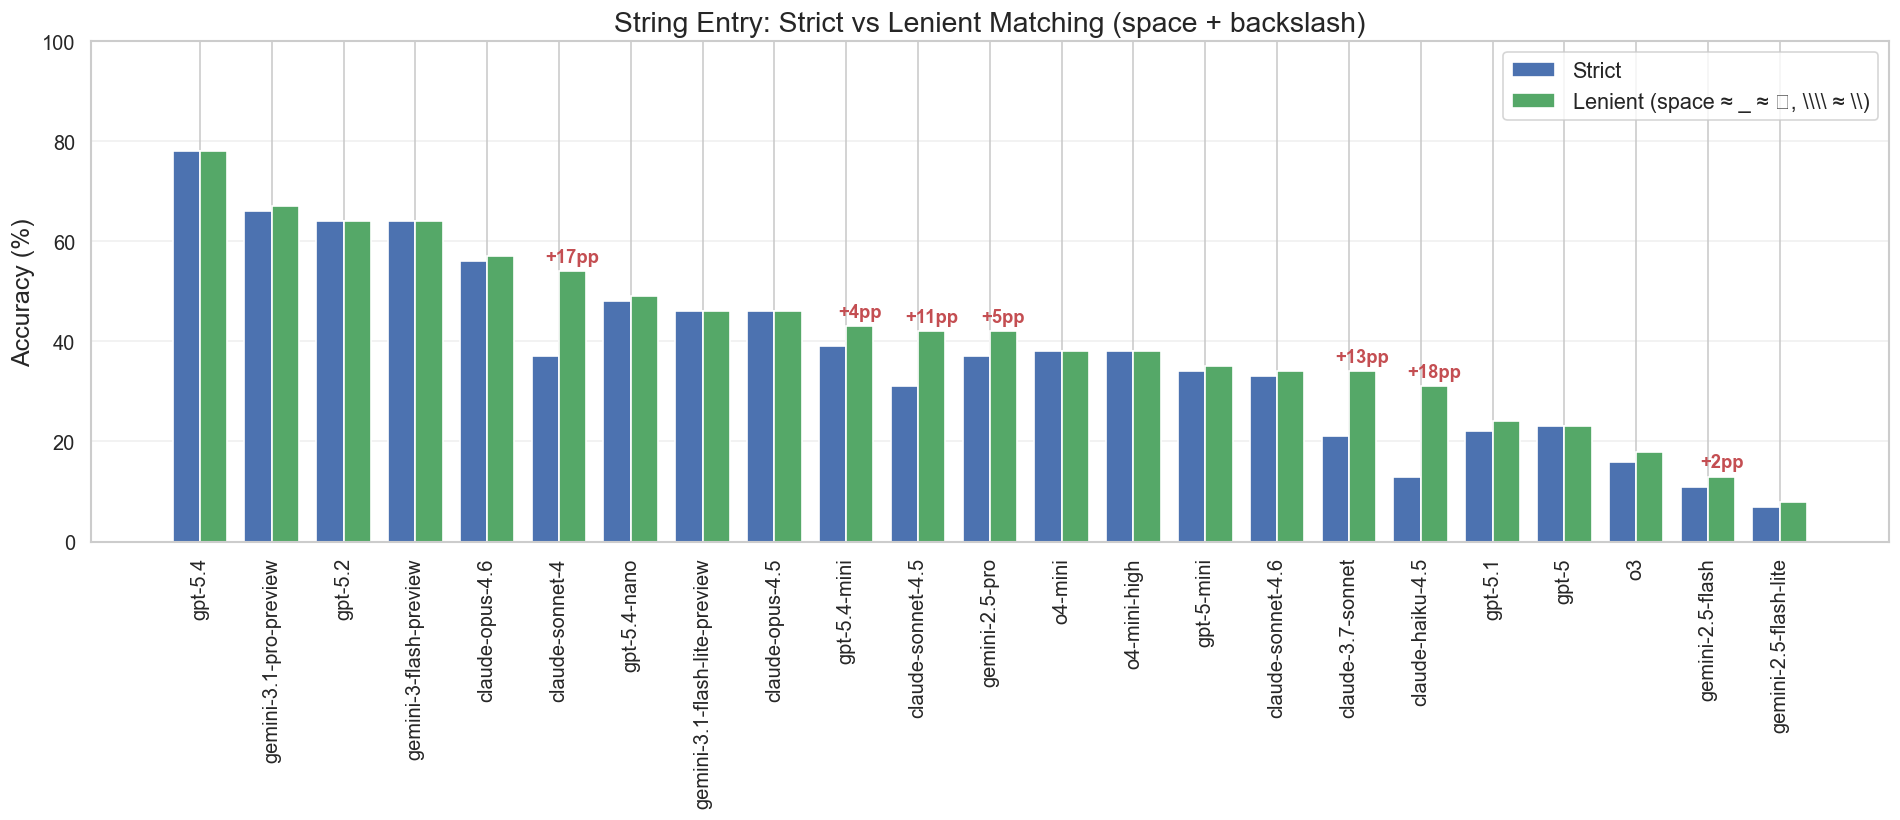


Per-model impact (sorted by lenient accuracy):
Model                          Strict   Lenient    Delta
--------------------------------------------------------
gpt-5.4                         78.0%     78.0%    +0.0pp
gemini-3.1-pro-preview          66.0%     67.0%    +1.0pp
gpt-5.2                         64.0%     64.0%    +0.0pp
gemini-3-flash-preview          64.0%     64.0%    +0.0pp
claude-opus-4.6                 56.0%     57.0%    +1.0pp
claude-sonnet-4                 37.0%     54.0%   +17.0pp
gpt-5.4-nano                    48.0%     49.0%    +1.0pp
gemini-3.1-flash-lite-preview    46.0%     46.0%    +0.0pp
claude-opus-4.5                 46.0%     46.0%    +0.0pp
gpt-5.4-mini                    39.0%     43.0%    +4.0pp
claude-sonnet-4.5               31.0%     42.0%   +11.0pp
gemini-2.5-pro                  37.0%     42.0%    +5.0pp
o4-mini                         38.0%     38.0%    +0.0pp
o4-mini-high                    38.0%     38.0%    +0.0pp
gpt-5-mini               

In [32]:
# ── String Entry: impact of lenient matching (space + backslash normalization) ──


def normalize_lenient(s):
    """Normalize spaces (space/underscore/␣) and escaped backslashes."""
    return str(s).replace("\u2423", " ").replace("_", " ").replace("\\\\", "\\")


se_df = df[df["game"] == "string_entry"].copy()
se_df["lenient_correct"] = se_df.apply(
    lambda r: int(
        normalize_lenient(r["response"] or "") == normalize_lenient(r["solution"] or "")
    ),
    axis=1,
)

orig_acc = se_df["is_correct"].mean()
lenient_acc = se_df["lenient_correct"].mean()
rescued = se_df["lenient_correct"].sum() - se_df["is_correct"].sum()

print(f"Original accuracy:  {orig_acc:.1%}")
print(
    f"Lenient accuracy:   {lenient_acc:.1%}  (+{lenient_acc - orig_acc:.1%}, {rescued} puzzles rescued)"
)
print(f"  (lenient = space ≈ _ ≈ ␣, and \\\\\\\\ ≈ \\\\)")
print()

# Per-model comparison
comp = (
    se_df.groupby("model_short")
    .agg(
        original=("is_correct", "mean"),
        lenient=("lenient_correct", "mean"),
        n=("is_correct", "count"),
    )
    .sort_values("lenient", ascending=False)
)
comp["delta_pp"] = (comp["lenient"] - comp["original"]) * 100

# Plot: side-by-side bars per model
fig, ax = plt.subplots(figsize=(16, 7))
x = range(len(comp))
w = 0.38
ax.bar(
    [i - w / 2 for i in x],
    comp["original"] * 100,
    width=w,
    label="Strict",
    color="#4C72B0",
    edgecolor="white",
)
ax.bar(
    [i + w / 2 for i in x],
    comp["lenient"] * 100,
    width=w,
    label="Lenient (space ≈ _ ≈ ␣, \\\\\\\\ ≈ \\\\)",
    color="#55A868",
    edgecolor="white",
)

# Annotate deltas where meaningful
for i, (_, row) in enumerate(comp.iterrows()):
    if row["delta_pp"] >= 2:
        ax.annotate(
            f"+{row['delta_pp']:.0f}pp",
            (i + w / 2, row["lenient"] * 100 + 1),
            ha="center",
            va="bottom",
            fontsize=11,
            color="#C44E52",
            fontweight="bold",
        )

ax.set_xticks(x)
ax.set_xticklabels(comp.index, rotation=90, fontsize=12)
ax.set_ylabel("Accuracy (%)", fontsize=15)
ax.set_title(
    "String Entry: Strict vs Lenient Matching (space + backslash)", fontsize=17
)
ax.legend(fontsize=13, loc="upper right")
ax.tick_params(labelsize=12)
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

# Summary table
print("\nPer-model impact (sorted by lenient accuracy):")
print(f"{'Model':<28} {'Strict':>8} {'Lenient':>9} {'Delta':>8}")
print("-" * 56)
for m, row in comp.iterrows():
    print(
        f"{m:<28} {row['original']*100:>7.1f}% {row['lenient']*100:>8.1f}% {row['delta_pp']:>+7.1f}pp"
    )

## 2×2 Factorial: Persona × Incentive Interaction

Excluding T0 (control). Does the incentive effect differ between standard and human persona?

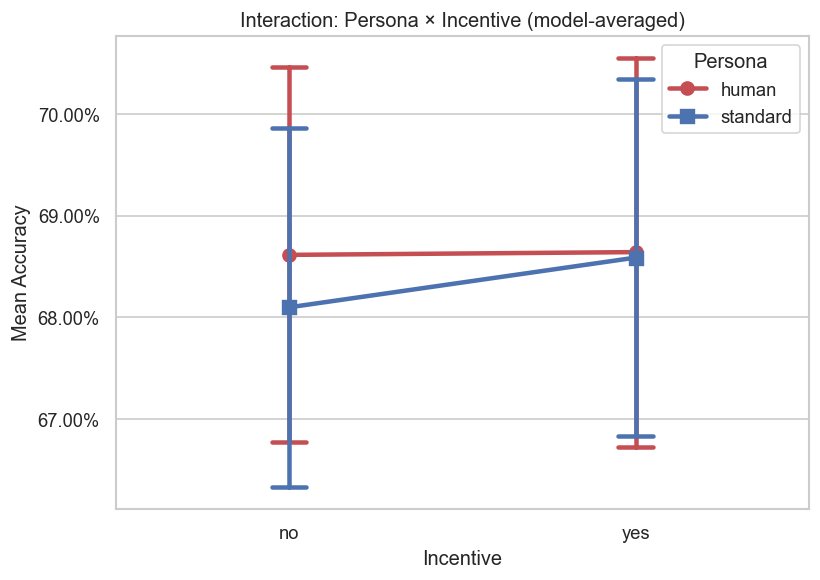

In [33]:
# Interaction plot: persona × incentive (excluding control)
df_factorial = grouped_df[grouped_df["persona"] != "control"].copy()

cell_acc = (
    df_factorial.groupby(["persona", "incentive", "model_short"], observed=True)[
        "accuracy"
    ]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(7, 5))
sns.pointplot(
    data=cell_acc,
    x="incentive",
    y="accuracy",
    hue="persona",
    ax=ax,
    markers=["o", "s"],
    capsize=0.1,
    errorbar="se",
    palette={"standard": "#4C72B0", "human": "#C44E52"},
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("Incentive")
ax.set_ylabel("Mean Accuracy")
ax.set_title("Interaction: Persona × Incentive (model-averaged)")
ax.legend(title="Persona")
fig.tight_layout()
plt.show()

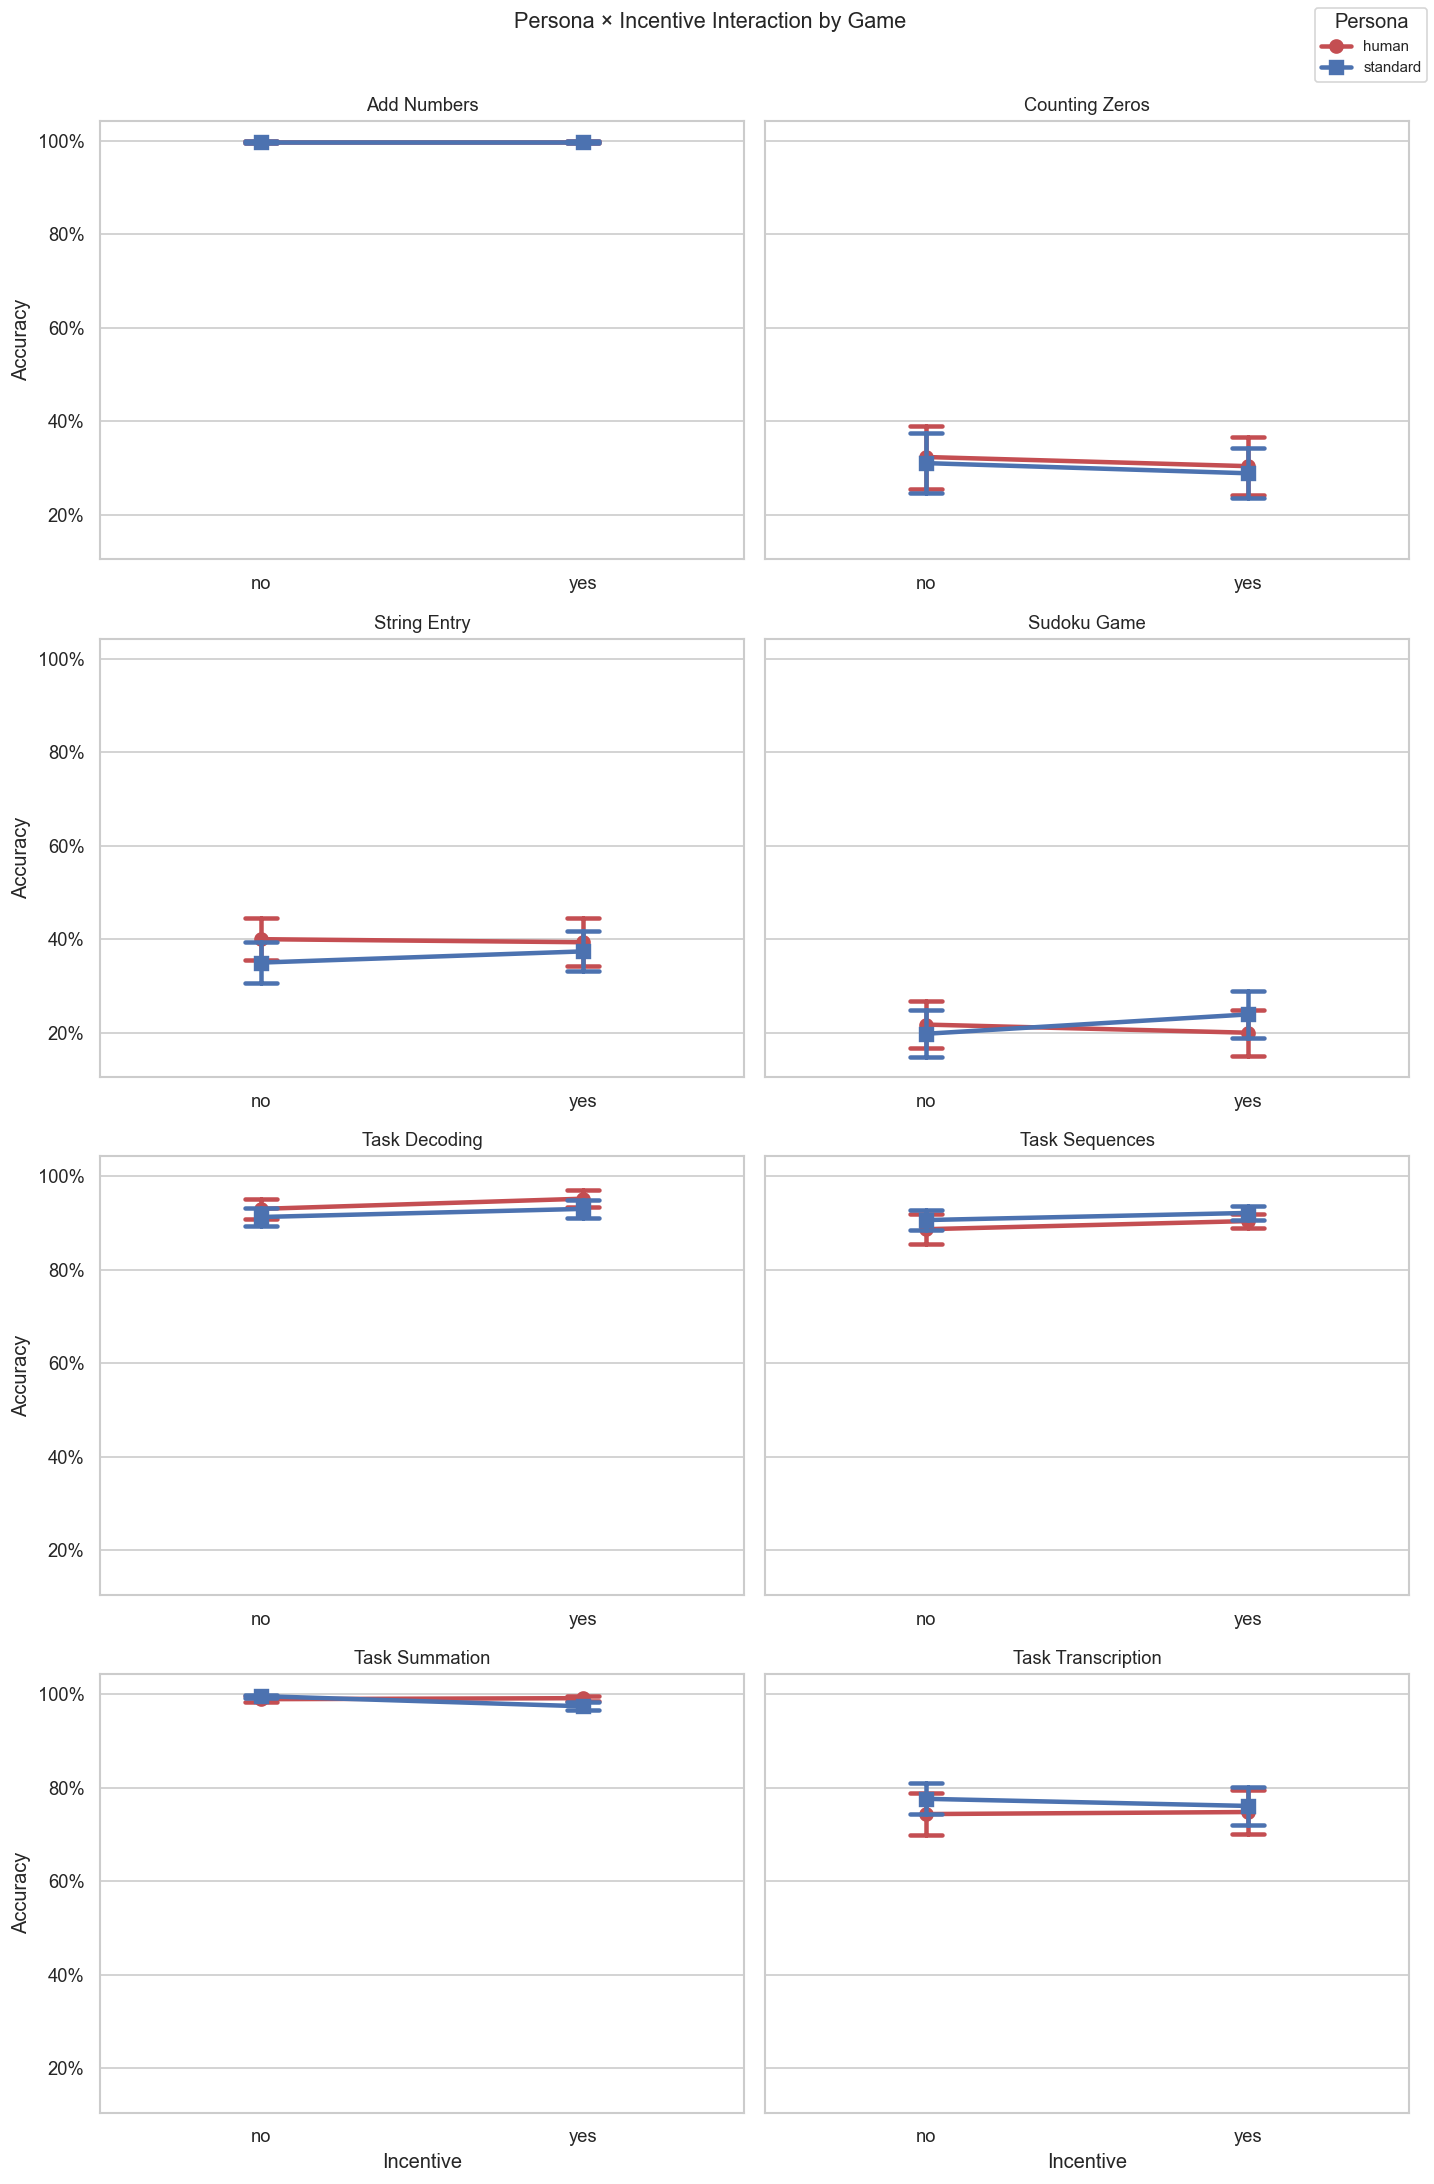

In [34]:
# Same interaction, per task
ncols_f = 2
nrows_f = math.ceil(len(games) / ncols_f)

fig, axes = plt.subplots(nrows_f, ncols_f, figsize=(12, 4.5 * nrows_f), sharey=True)
axes_flat = axes.flatten()

for idx, game in enumerate(games):
    ax = axes_flat[idx]
    g_cell = (
        df_factorial[df_factorial["game"] == game]
        .groupby(["persona", "incentive", "model_short"], observed=True)["accuracy"]
        .mean()
        .reset_index()
    )
    sns.pointplot(
        data=g_cell,
        x="incentive",
        y="accuracy",
        hue="persona",
        ax=ax,
        markers=["o", "s"],
        capsize=0.1,
        errorbar="se",
        palette={"standard": "#4C72B0", "human": "#C44E52"},
    )
    ax.set_title(game.replace("_", " ").title(), fontsize=11)
    ax.set_xlabel("" if idx < len(games) - ncols_f else "Incentive")
    ax.set_ylabel("Accuracy" if idx % ncols_f == 0 else "")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    if ax.get_legend():
        ax.get_legend().remove()

for idx in range(len(games), len(axes_flat)):
    axes_flat[idx].set_visible(False)

handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Persona", loc="upper right", fontsize=9)
fig.suptitle("Persona × Incentive Interaction by Game", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## Effort Under Incentive: Completion Tokens Delta

Do models produce more tokens (proxy for effort) when incentivized or under human framing?

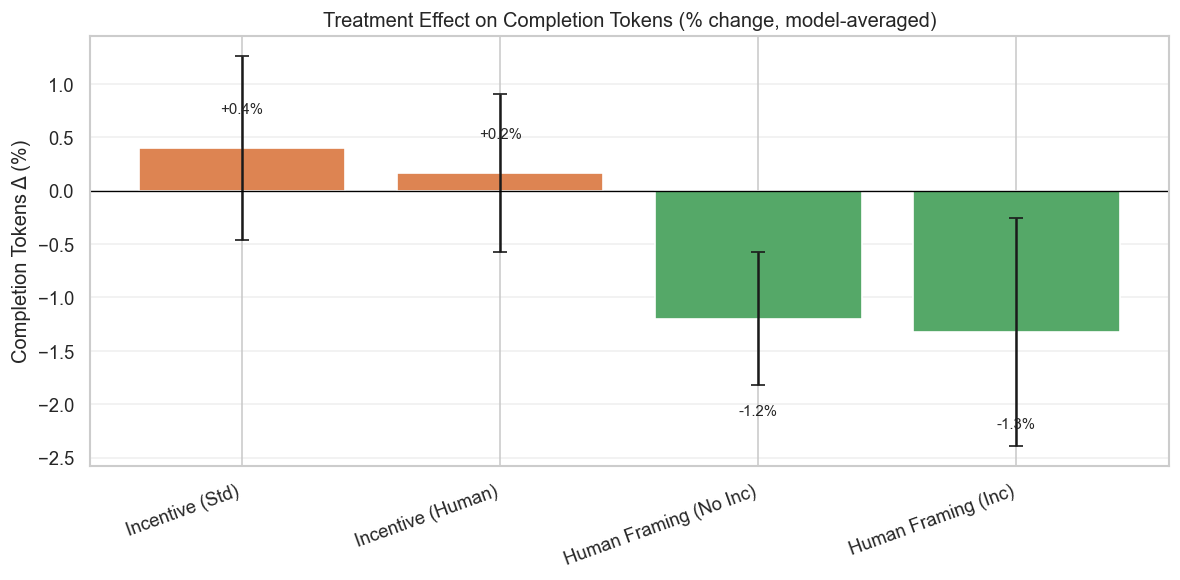

In [35]:
# Token delta: % change in completion tokens
model_tokens = (
    grouped_df.groupby(["treatment", "model_short"], observed=True)[
        "total_completion_tokens"
    ]
    .mean()
    .unstack("treatment")
)

token_contrasts = {
    "Incentive (Std)": ("T2: Std Inc", "T1: Std No Inc"),
    "Incentive (Human)": ("T4: Hum Inc", "T3: Hum No Inc"),
    "Human Framing (No Inc)": ("T3: Hum No Inc", "T1: Std No Inc"),
    "Human Framing (Inc)": ("T4: Hum Inc", "T2: Std Inc"),
}

token_delta_df = pd.DataFrame()
for label, (t_high, t_low) in token_contrasts.items():
    token_delta_df[label] = (
        (model_tokens[t_high] - model_tokens[t_low]) / model_tokens[t_low]
    ) * 100

fig, ax = plt.subplots(figsize=(10, 5))
means = token_delta_df.mean()
ses = token_delta_df.std() / np.sqrt(token_delta_df.count())
bar_colors = [
    TREATMENT_COLORS["T2: Std Inc"],
    TREATMENT_COLORS["T2: Std Inc"],
    TREATMENT_COLORS["T3: Hum No Inc"],
    TREATMENT_COLORS["T3: Hum No Inc"],
]
ax.bar(
    range(len(means)), means, yerr=ses, capsize=4, color=bar_colors, edgecolor="white"
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(range(len(means)))
ax.set_xticklabels(means.index, rotation=20, ha="right")
ax.set_ylabel("Completion Tokens Δ (%)")
ax.set_title("Treatment Effect on Completion Tokens (% change, model-averaged)")
ax.grid(axis="y", alpha=0.3)

for bar, val in zip(ax.patches, means):
    y = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        y + (0.3 if y >= 0 else -0.8),
        f"{val:+.1f}%",
        ha="center",
        va="bottom" if y >= 0 else "top",
        fontsize=9,
    )

fig.tight_layout()
plt.show()

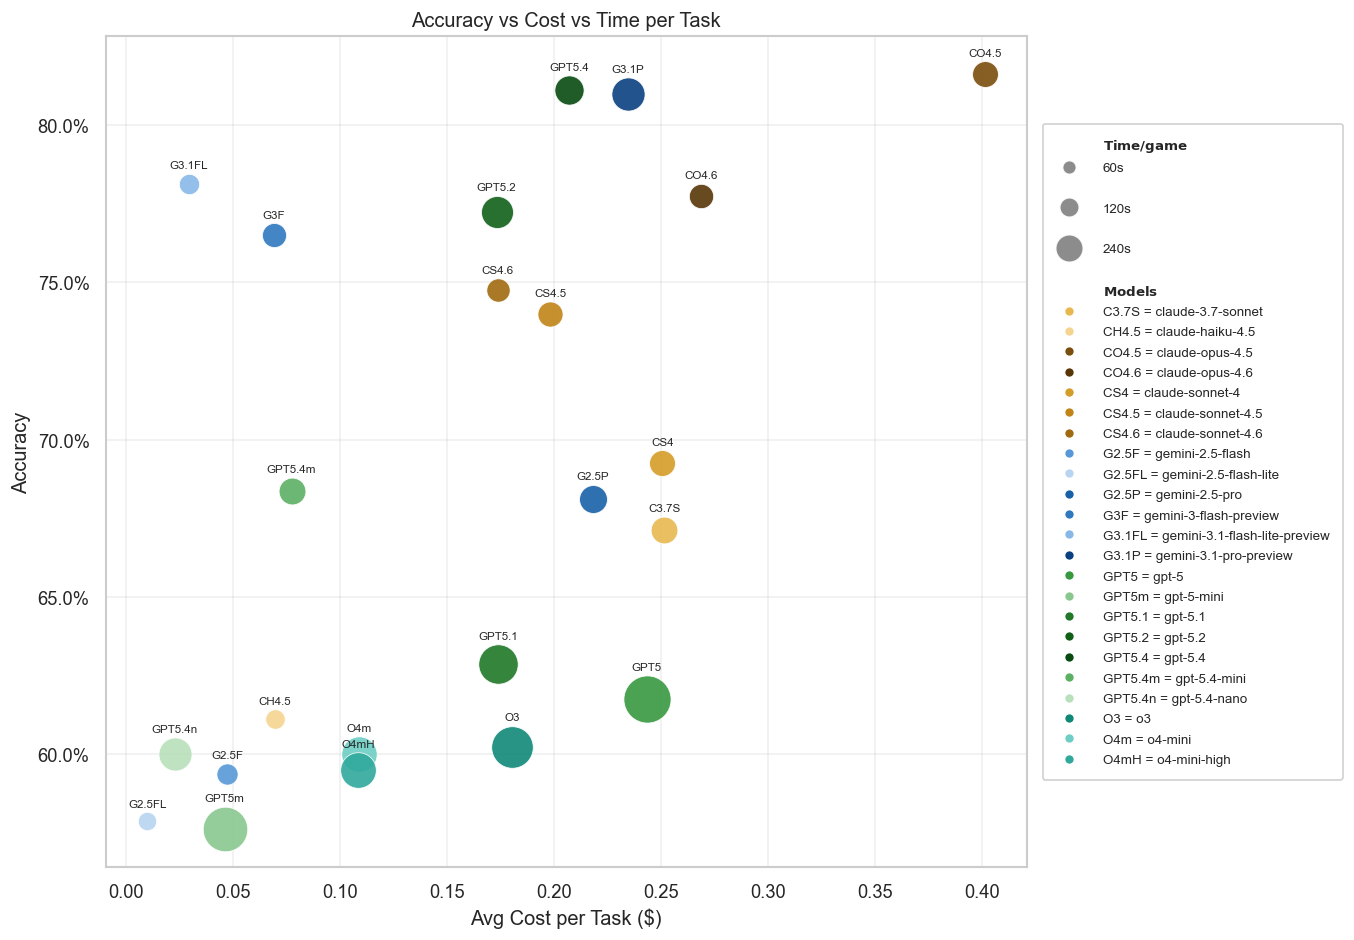

In [36]:
# Accuracy vs Cost vs Time — bubble chart (averaged over treatments)
model_summary = (
    grouped_df.groupby("model_short", observed=True)
    .agg(
        accuracy=("accuracy", "mean"),
        cost_per_game=("cost_per_game", "mean"),
        time_per_game=("total_time", "mean"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 8))

# Scale bubble size for readability
size_scale = 800 / model_summary["time_per_game"].max()

for _, row in model_summary.iterrows():
    ax.scatter(
        row["cost_per_game"],
        row["accuracy"],
        s=row["time_per_game"] * size_scale,
        color=MODEL_COLORS.get(row["model_short"], "#888888"),
        alpha=0.9,
        edgecolors="white",
        linewidth=0.5,
        zorder=3,
    )
    # Offset above bubble: radius in points = sqrt(s) / 2
    bubble_s = row["time_per_game"] * size_scale
    radius_pt = np.sqrt(bubble_s) / 2
    ax.annotate(
        MODEL_ABBREV.get(row["model_short"], row["model_short"]),
        (row["cost_per_game"], row["accuracy"]),
        fontsize=7,
        ha="center",
        va="bottom",
        xytext=(0, radius_pt + 2),
        textcoords="offset points",
    )

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("Avg Cost per Task ($)")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs Cost vs Time per Task")
ax.grid(alpha=0.3)

# Merged legend: bubble sizes + model abbreviations
from matplotlib.lines import Line2D

handles = []
# Bubble size section
handles.append(Line2D([0], [0], marker="", color="w", label="$\\bf{Time/game}$"))
for i, t_val in enumerate([60, 120, 240]):
    handles.append(
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor="gray",
            alpha=0.9,
            markersize=np.sqrt(t_val * size_scale),
            label=f"{t_val:.0f}s",
        )
    )
    if i < 2:
        handles.append(Line2D([0], [0], marker="", color="w", label=""))

# Separator
handles.append(Line2D([0], [0], marker="", color="w", label=""))
handles.append(Line2D([0], [0], marker="", color="w", label="$\\bf{Models}$"))

# Model abbreviations
for m in sort_by_family(list(MODEL_ABBREV.keys())):
    handles.append(
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor=MODEL_COLORS[m],
            markersize=6,
            label=f"{MODEL_ABBREV[m]} = {m}",
        )
    )

ax.legend(
    handles=handles,
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    fontsize=8,
    framealpha=0.9,
    borderpad=1,
    handletextpad=1.5,
    labelspacing=0.6,
)
fig.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

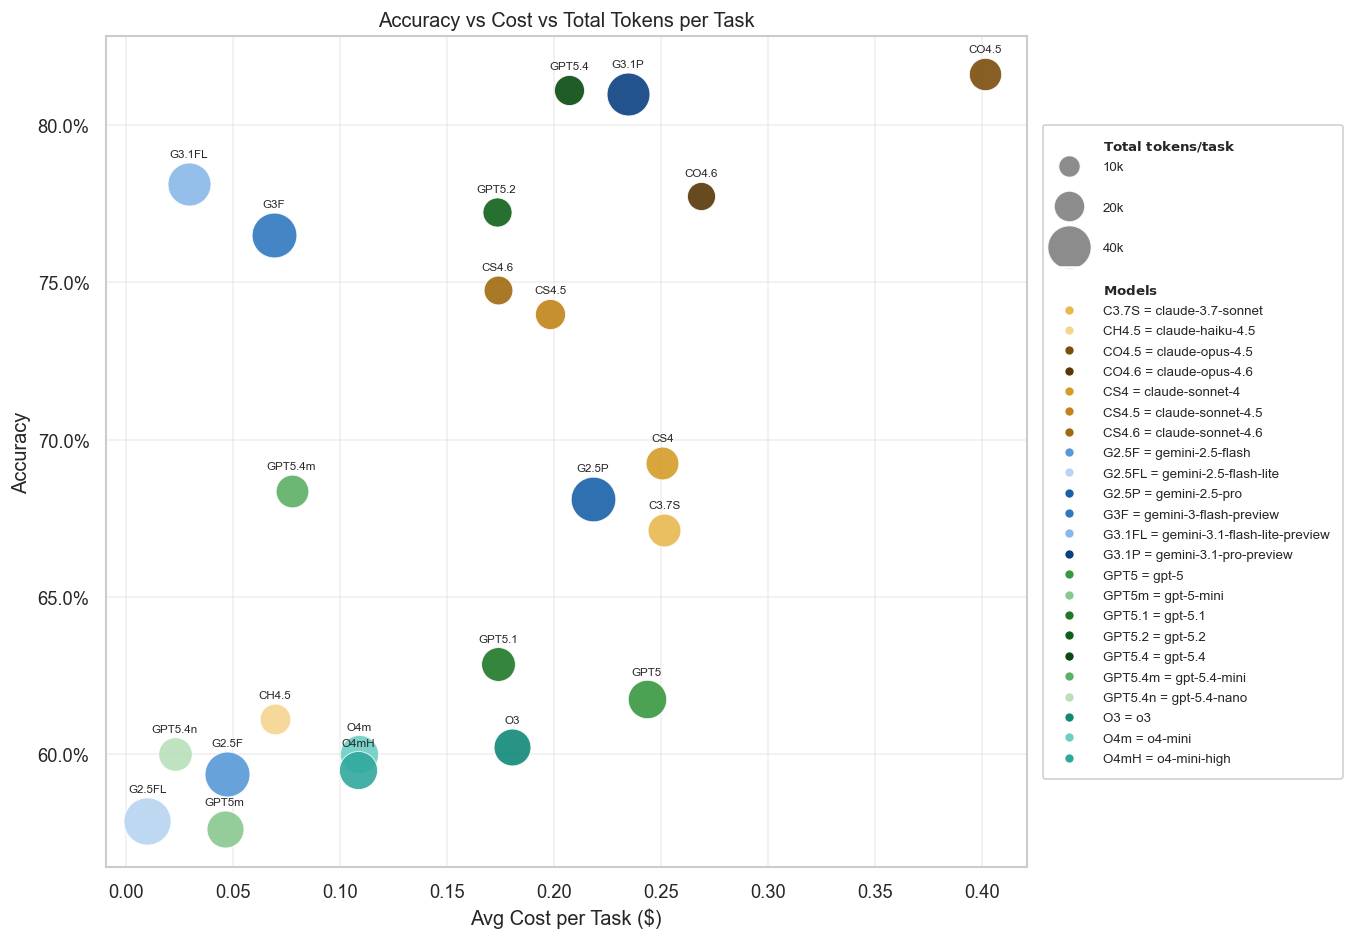

In [37]:
# Accuracy vs Cost vs Total Tokens — bubble chart (averaged over treatments)
model_summary_tok = (
    grouped_df.groupby("model_short", observed=True)
    .agg(
        accuracy=("accuracy", "mean"),
        cost_per_game=("cost_per_game", "mean"),
        tokens_per_game=("total_tokens", "mean"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 8))

size_scale = 800 / model_summary_tok["tokens_per_game"].max()

for _, row in model_summary_tok.iterrows():
    ax.scatter(
        row["cost_per_game"],
        row["accuracy"],
        s=row["tokens_per_game"] * size_scale,
        color=MODEL_COLORS.get(row["model_short"], "#888888"),
        alpha=0.9,
        edgecolors="white",
        linewidth=0.5,
        zorder=3,
    )
    bubble_s = row["tokens_per_game"] * size_scale
    radius_pt = np.sqrt(bubble_s) / 2
    ax.annotate(
        MODEL_ABBREV.get(row["model_short"], row["model_short"]),
        (row["cost_per_game"], row["accuracy"]),
        fontsize=7,
        ha="center",
        va="bottom",
        xytext=(0, radius_pt + 2),
        textcoords="offset points",
    )

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("Avg Cost per Task ($)")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs Cost vs Total Tokens per Task")
ax.grid(alpha=0.3)

from matplotlib.lines import Line2D

handles = []
handles.append(Line2D([0], [0], marker="", color="w", label="$\\bf{Total\\ tokens/task}$"))
for i, t_val in enumerate([10000, 20000, 40000]):
    handles.append(
        Line2D(
            [0], [0],
            marker="o", color="w",
            markerfacecolor="gray", alpha=0.9,
            markersize=np.sqrt(t_val * size_scale),
            label=f"{t_val // 1000}k",
        )
    )
    if i < 2:
        handles.append(Line2D([0], [0], marker="", color="w", label=""))

handles.append(Line2D([0], [0], marker="", color="w", label=""))
handles.append(Line2D([0], [0], marker="", color="w", label="$\\bf{Models}$"))

for m in sort_by_family(list(MODEL_ABBREV.keys())):
    handles.append(
        Line2D(
            [0], [0],
            marker="o", color="w",
            markerfacecolor=MODEL_COLORS[m],
            markersize=6,
            label=f"{MODEL_ABBREV[m]} = {m}",
        )
    )

ax.legend(
    handles=handles,
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    fontsize=8,
    framealpha=0.9,
    borderpad=1,
    handletextpad=1.5,
    labelspacing=0.6,
)
fig.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

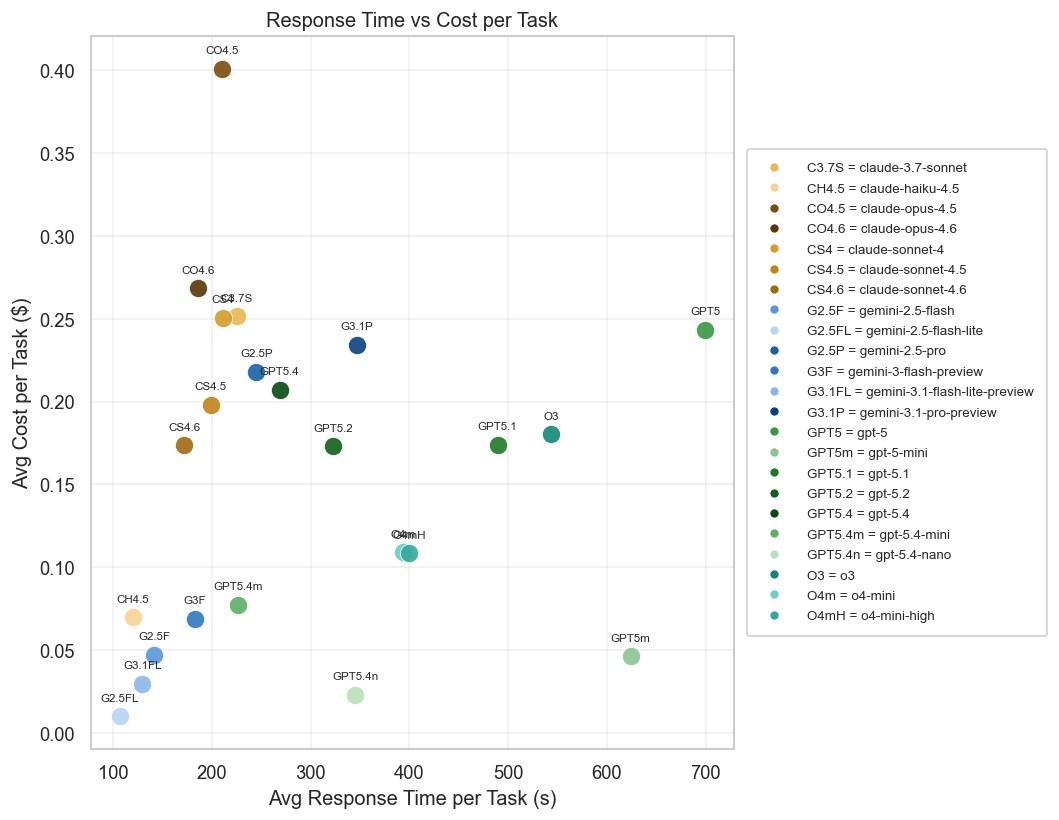

In [38]:
# Average Response Time vs Average Cost per Task (averaged over treatments)
time_cost = (
    grouped_df.groupby("model_short", observed=True)
    .agg(
        avg_time=("total_time", "mean"),
        avg_cost=("cost_per_game", "mean"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 7))

for _, row in time_cost.iterrows():
    ax.scatter(
        row["avg_time"],
        row["avg_cost"],
        s=120,
        color=MODEL_COLORS.get(row["model_short"], "#888888"),
        alpha=0.9,
        edgecolors="white",
        linewidth=0.5,
        zorder=3,
    )
    ax.annotate(
        MODEL_ABBREV.get(row["model_short"], row["model_short"]),
        (row["avg_time"], row["avg_cost"]),
        fontsize=7,
        ha="center",
        va="bottom",
        xytext=(0, 8),
        textcoords="offset points",
    )

ax.set_xlabel("Avg Response Time per Task (s)")
ax.set_ylabel("Avg Cost per Task ($)")
ax.set_title("Response Time vs Cost per Task")
ax.grid(alpha=0.3)

handles = []
for m in sort_by_family(list(MODEL_ABBREV.keys())):
    handles.append(
        Line2D(
            [0], [0],
            marker="o", color="w",
            markerfacecolor=MODEL_COLORS[m],
            markersize=6,
            label=f"{MODEL_ABBREV[m]} = {m}",
        )
    )
ax.legend(
    handles=handles,
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    fontsize=8,
    framealpha=0.9,
    borderpad=1,
    handletextpad=1.5,
    labelspacing=0.6,
)
fig.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

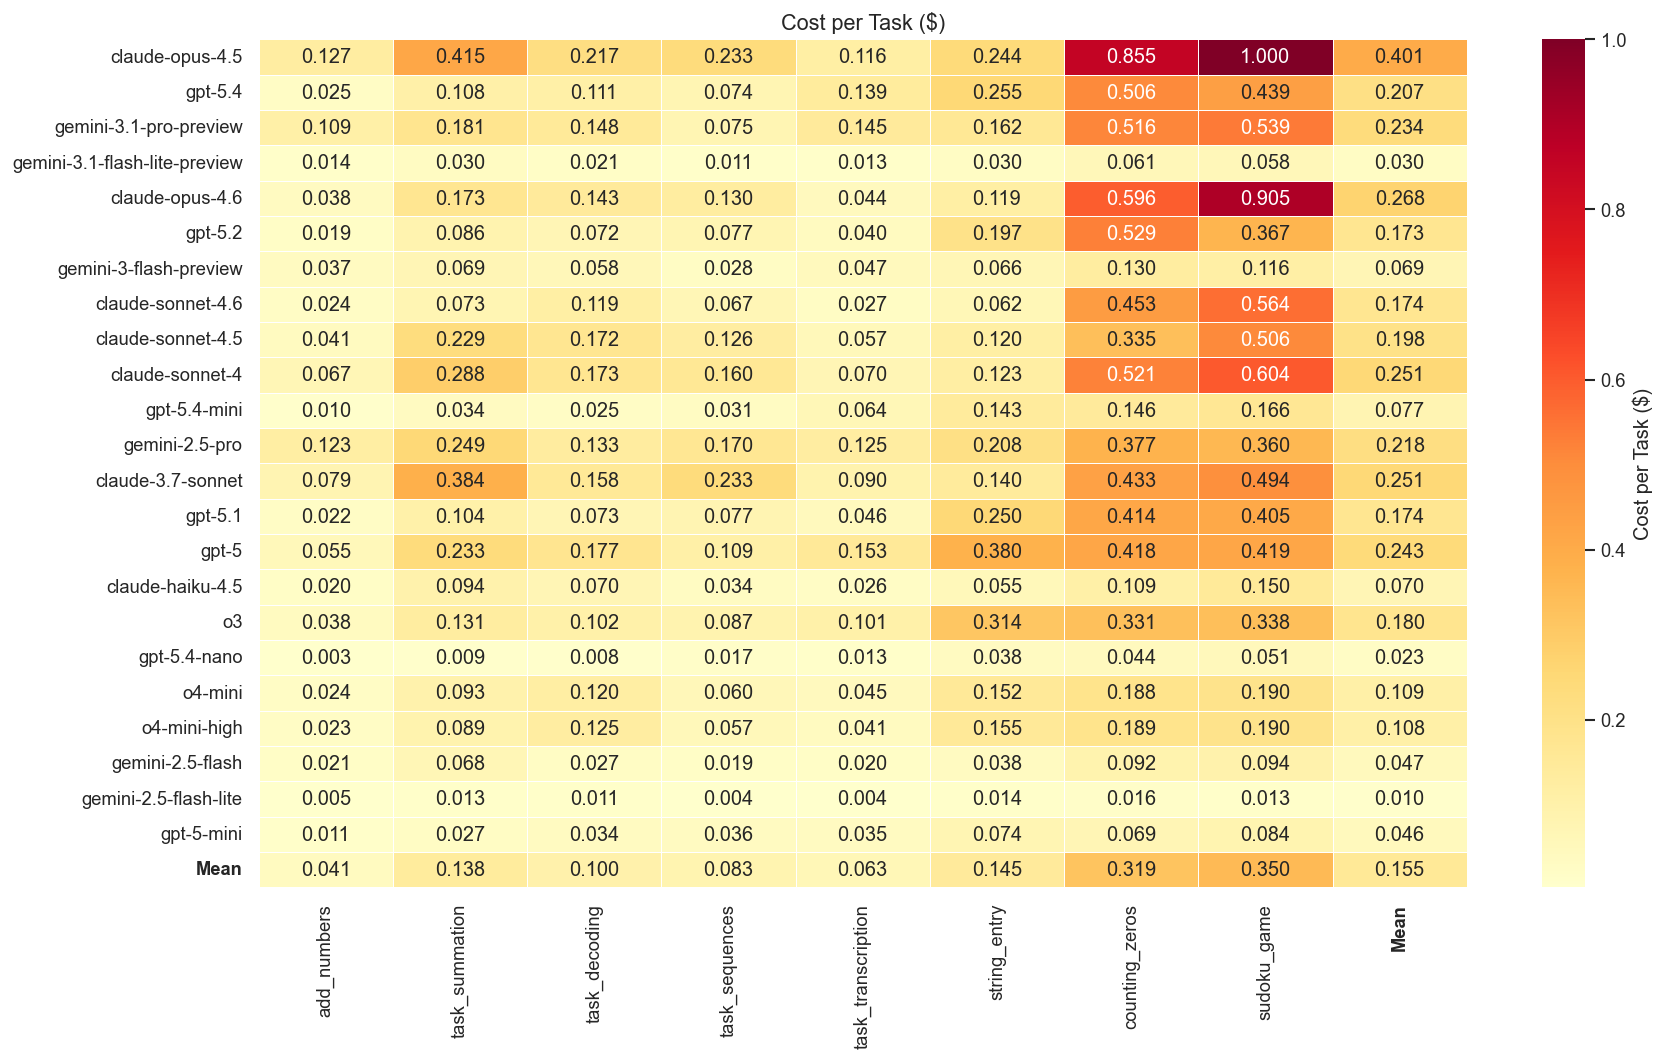

In [39]:
# Cost per task by model × game (averaged over treatments)
_acc_avg = grouped_df.pivot_table(index="model_short", columns="game", values="accuracy") * 100
_model_ord = _acc_avg.mean(axis=1).sort_values(ascending=False).index.tolist()
_game_ord = _acc_avg.mean(axis=0).sort_values(ascending=False).index.tolist()

cost_model_game = (
    grouped_df.groupby(["model_short", "game"], observed=True)["cost_per_game"]
    .mean()
    .reset_index()
)

pivot = cost_model_game.pivot(
    index="model_short", columns="game", values="cost_per_game"
)
pivot = pivot.reindex(index=[m for m in _model_ord if m in pivot.index])
pivot = pivot[[g for g in _game_ord if g in pivot.columns]]

# Add mean row and column
pivot["Mean"] = pivot.mean(axis=1)
pivot.loc["Mean"] = pivot.mean(axis=0)

fig, ax = plt.subplots(figsize=(15, 9))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Cost per Task ($)"},
)
# Bold the Mean row/column labels
xlabels = ax.get_xticklabels()
for lbl in xlabels:
    if lbl.get_text() == "Mean":
        lbl.set_weight("bold")
ax.set_xticklabels(xlabels)
ylabels = ax.get_yticklabels()
for lbl in ylabels:
    if lbl.get_text() == "Mean":
        lbl.set_weight("bold")
ax.set_yticklabels(ylabels)

ax.set_title(
    "Cost per Task ($)",
    fontsize=13,
)
ax.set_ylabel("")
ax.set_xlabel("")
fig.tight_layout()
plt.show()


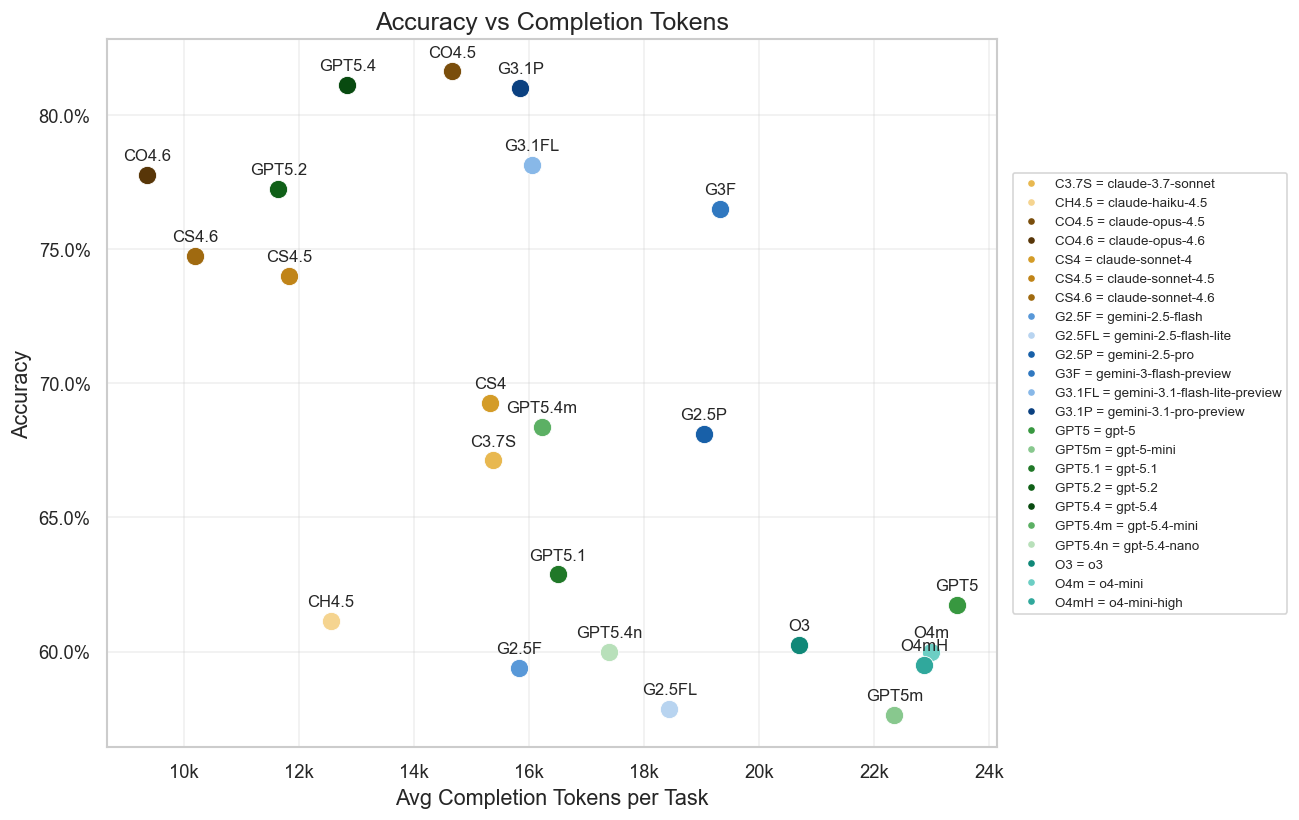

In [40]:
# Accuracy vs Avg Completion Tokens per task (averaged over treatments)
model_tok = (
    grouped_df.groupby("model_short", observed=True)
    .agg(
        accuracy=("accuracy", "mean"),
        avg_completion=("total_completion_tokens", "mean"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 7))

for _, row in model_tok.iterrows():
    ax.scatter(
        row["avg_completion"],
        row["accuracy"],
        s=120,
        color=MODEL_COLORS.get(row["model_short"], "#888888"),
        edgecolors="white",
        linewidth=0.5,
        zorder=3,
    )
    ax.annotate(
        MODEL_ABBREV.get(row["model_short"], row["model_short"]),
        (row["avg_completion"], row["accuracy"]),
        fontsize=10,
        ha="center",
        va="bottom",
        xytext=(0, 7),
        textcoords="offset points",
    )

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("Avg Completion Tokens per Task", fontsize=13)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.set_ylabel("Accuracy", fontsize=13)
ax.set_title("Accuracy vs Completion Tokens", fontsize=15)
ax.tick_params(labelsize=11)
ax.grid(alpha=0.3)
model_abbrev_legend(
    ax, ncol=1, fontsize=8, loc="center left", bbox_to_anchor=(1.01, 0.5)
)
fig.tight_layout()
plt.show()

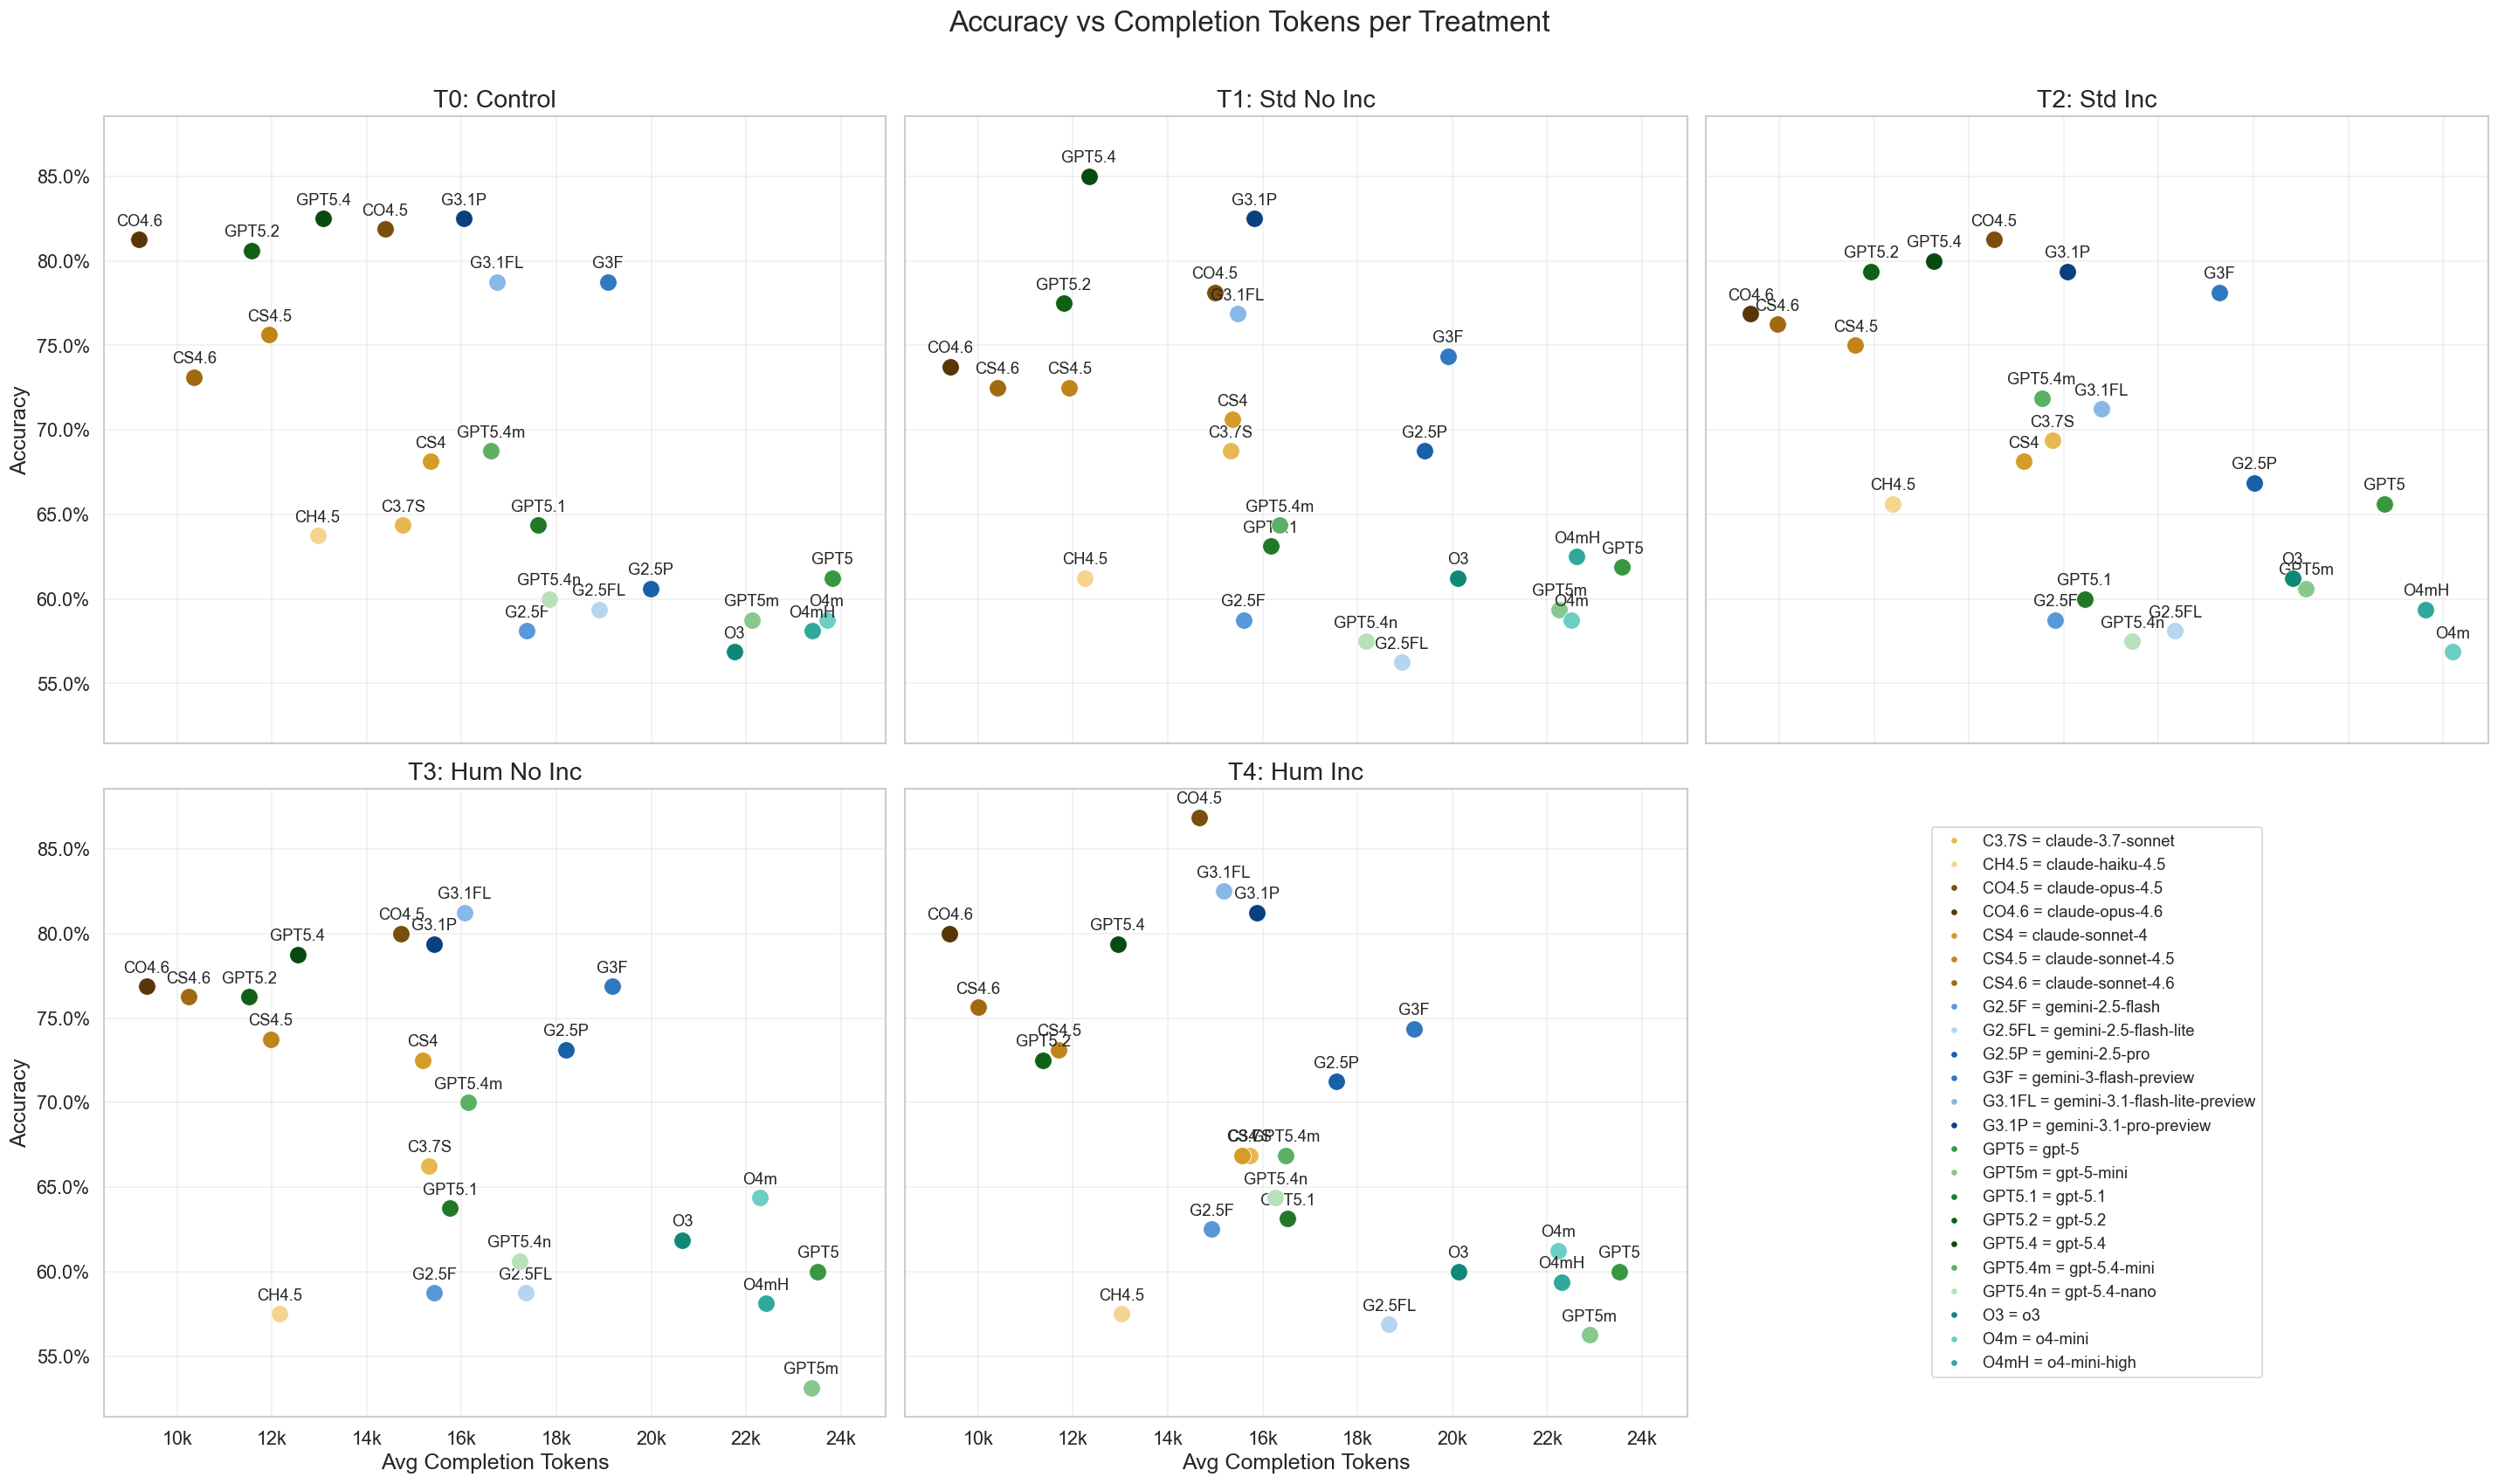

In [41]:
# Accuracy vs Completion Tokens — per treatment (2×3 grid)
nrows, ncols = 2, 3
fig, axes = plt.subplots(
    nrows, ncols, figsize=(8 * ncols, 7 * nrows), sharey=True, sharex=True
)
axes_flat = axes.flatten()

for idx, treatment in enumerate(TREATMENT_ORDER):
    ax = axes_flat[idx]
    t_data = grouped_df[grouped_df["treatment"] == treatment]
    model_tok_t = (
        t_data.groupby("model_short", observed=True)
        .agg(
            accuracy=("accuracy", "mean"),
            avg_completion=("total_completion_tokens", "mean"),
        )
        .reset_index()
    )
    for _, row in model_tok_t.iterrows():
        ax.scatter(
            row["avg_completion"],
            row["accuracy"],
            s=140,
            color=MODEL_COLORS.get(row["model_short"], "#888888"),
            edgecolors="white",
            linewidth=0.5,
            zorder=3,
        )
        ax.annotate(
            MODEL_ABBREV.get(row["model_short"], row["model_short"]),
            (row["avg_completion"], row["accuracy"]),
            fontsize=11,
            ha="center",
            va="bottom",
            xytext=(0, 7),
            textcoords="offset points",
        )
    ax.set_title(treatment, fontsize=17)
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
    ax.tick_params(labelsize=13)
    ax.grid(alpha=0.3)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

for ax in axes[:, 0]:
    ax.set_ylabel("Accuracy", fontsize=15)
for ax in axes[-1, :]:
    ax.set_xlabel("Avg Completion Tokens", fontsize=15)

fig.suptitle("Accuracy vs Completion Tokens per Treatment", fontsize=20, y=1.01)
# Place legend in empty 6th subplot
ax_leg = axes_flat[-1]
ax_leg.axis("off")
model_abbrev_legend(
    ax_leg, ncol=1, fontsize=11, loc="center", bbox_to_anchor=(0.5, 0.5)
)
fig.tight_layout()
plt.show()

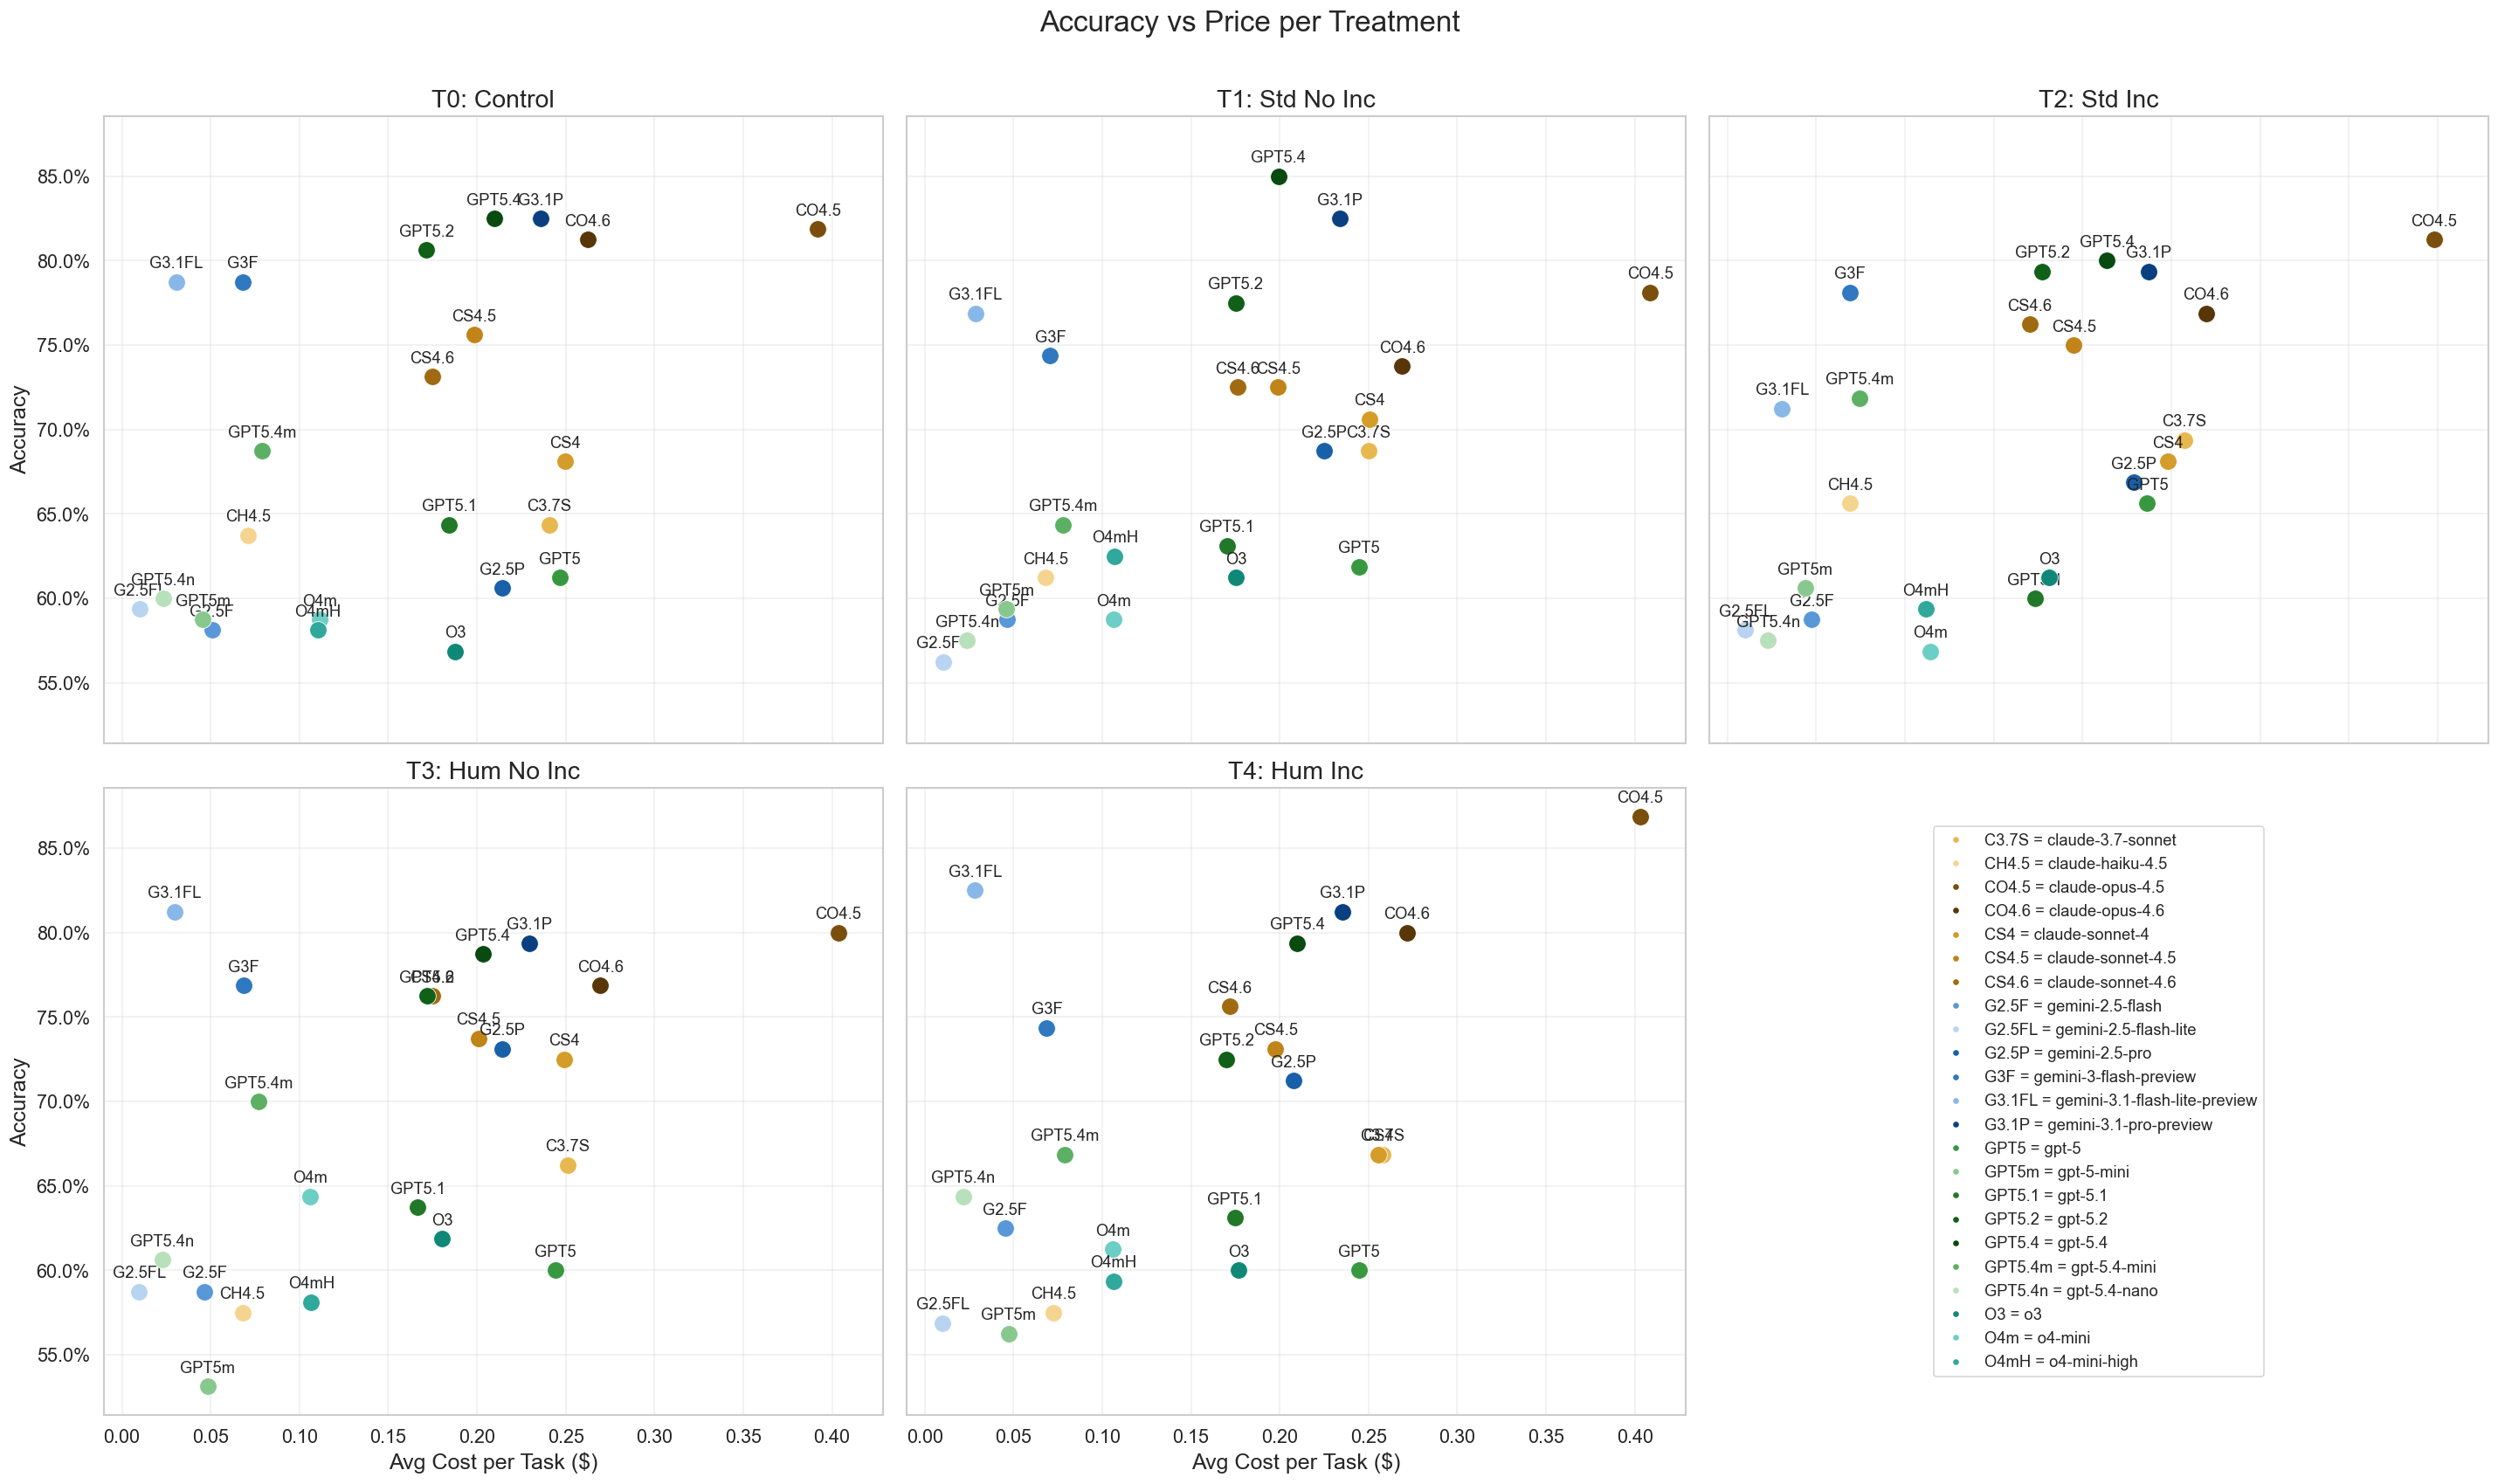

In [42]:
# Accuracy vs Price — per treatment (2×3 grid)
nrows, ncols = 2, 3
fig, axes = plt.subplots(
    nrows, ncols, figsize=(8 * ncols, 7 * nrows), sharey=True, sharex=True
)
axes_flat = axes.flatten()

for idx, treatment in enumerate(TREATMENT_ORDER):
    ax = axes_flat[idx]
    t_data = grouped_df[grouped_df["treatment"] == treatment]
    model_cost_t = (
        t_data.groupby("model_short", observed=True)
        .agg(accuracy=("accuracy", "mean"), avg_cost=("cost_per_game", "mean"))
        .reset_index()
    )
    for _, row in model_cost_t.iterrows():
        ax.scatter(
            row["avg_cost"],
            row["accuracy"],
            s=140,
            color=MODEL_COLORS.get(row["model_short"], "#888888"),
            edgecolors="white",
            linewidth=0.5,
            zorder=3,
        )
        ax.annotate(
            MODEL_ABBREV.get(row["model_short"], row["model_short"]),
            (row["avg_cost"], row["accuracy"]),
            fontsize=11,
            ha="center",
            va="bottom",
            xytext=(0, 7),
            textcoords="offset points",
        )
    ax.set_title(treatment, fontsize=17)
    ax.tick_params(labelsize=13)
    ax.grid(alpha=0.3)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

for ax in axes[:, 0]:
    ax.set_ylabel("Accuracy", fontsize=15)
for ax in axes[-1, :]:
    ax.set_xlabel("Avg Cost per Task ($)", fontsize=15)

fig.suptitle("Accuracy vs Price per Treatment", fontsize=20, y=1.01)
# Place legend in empty 6th subplot
ax_leg = axes_flat[-1]
ax_leg.set_visible(True)
ax_leg.axis("off")
model_abbrev_legend(
    ax_leg, ncol=1, fontsize=11, loc="center", bbox_to_anchor=(0.5, 0.5)
)
fig.tight_layout()
plt.show()

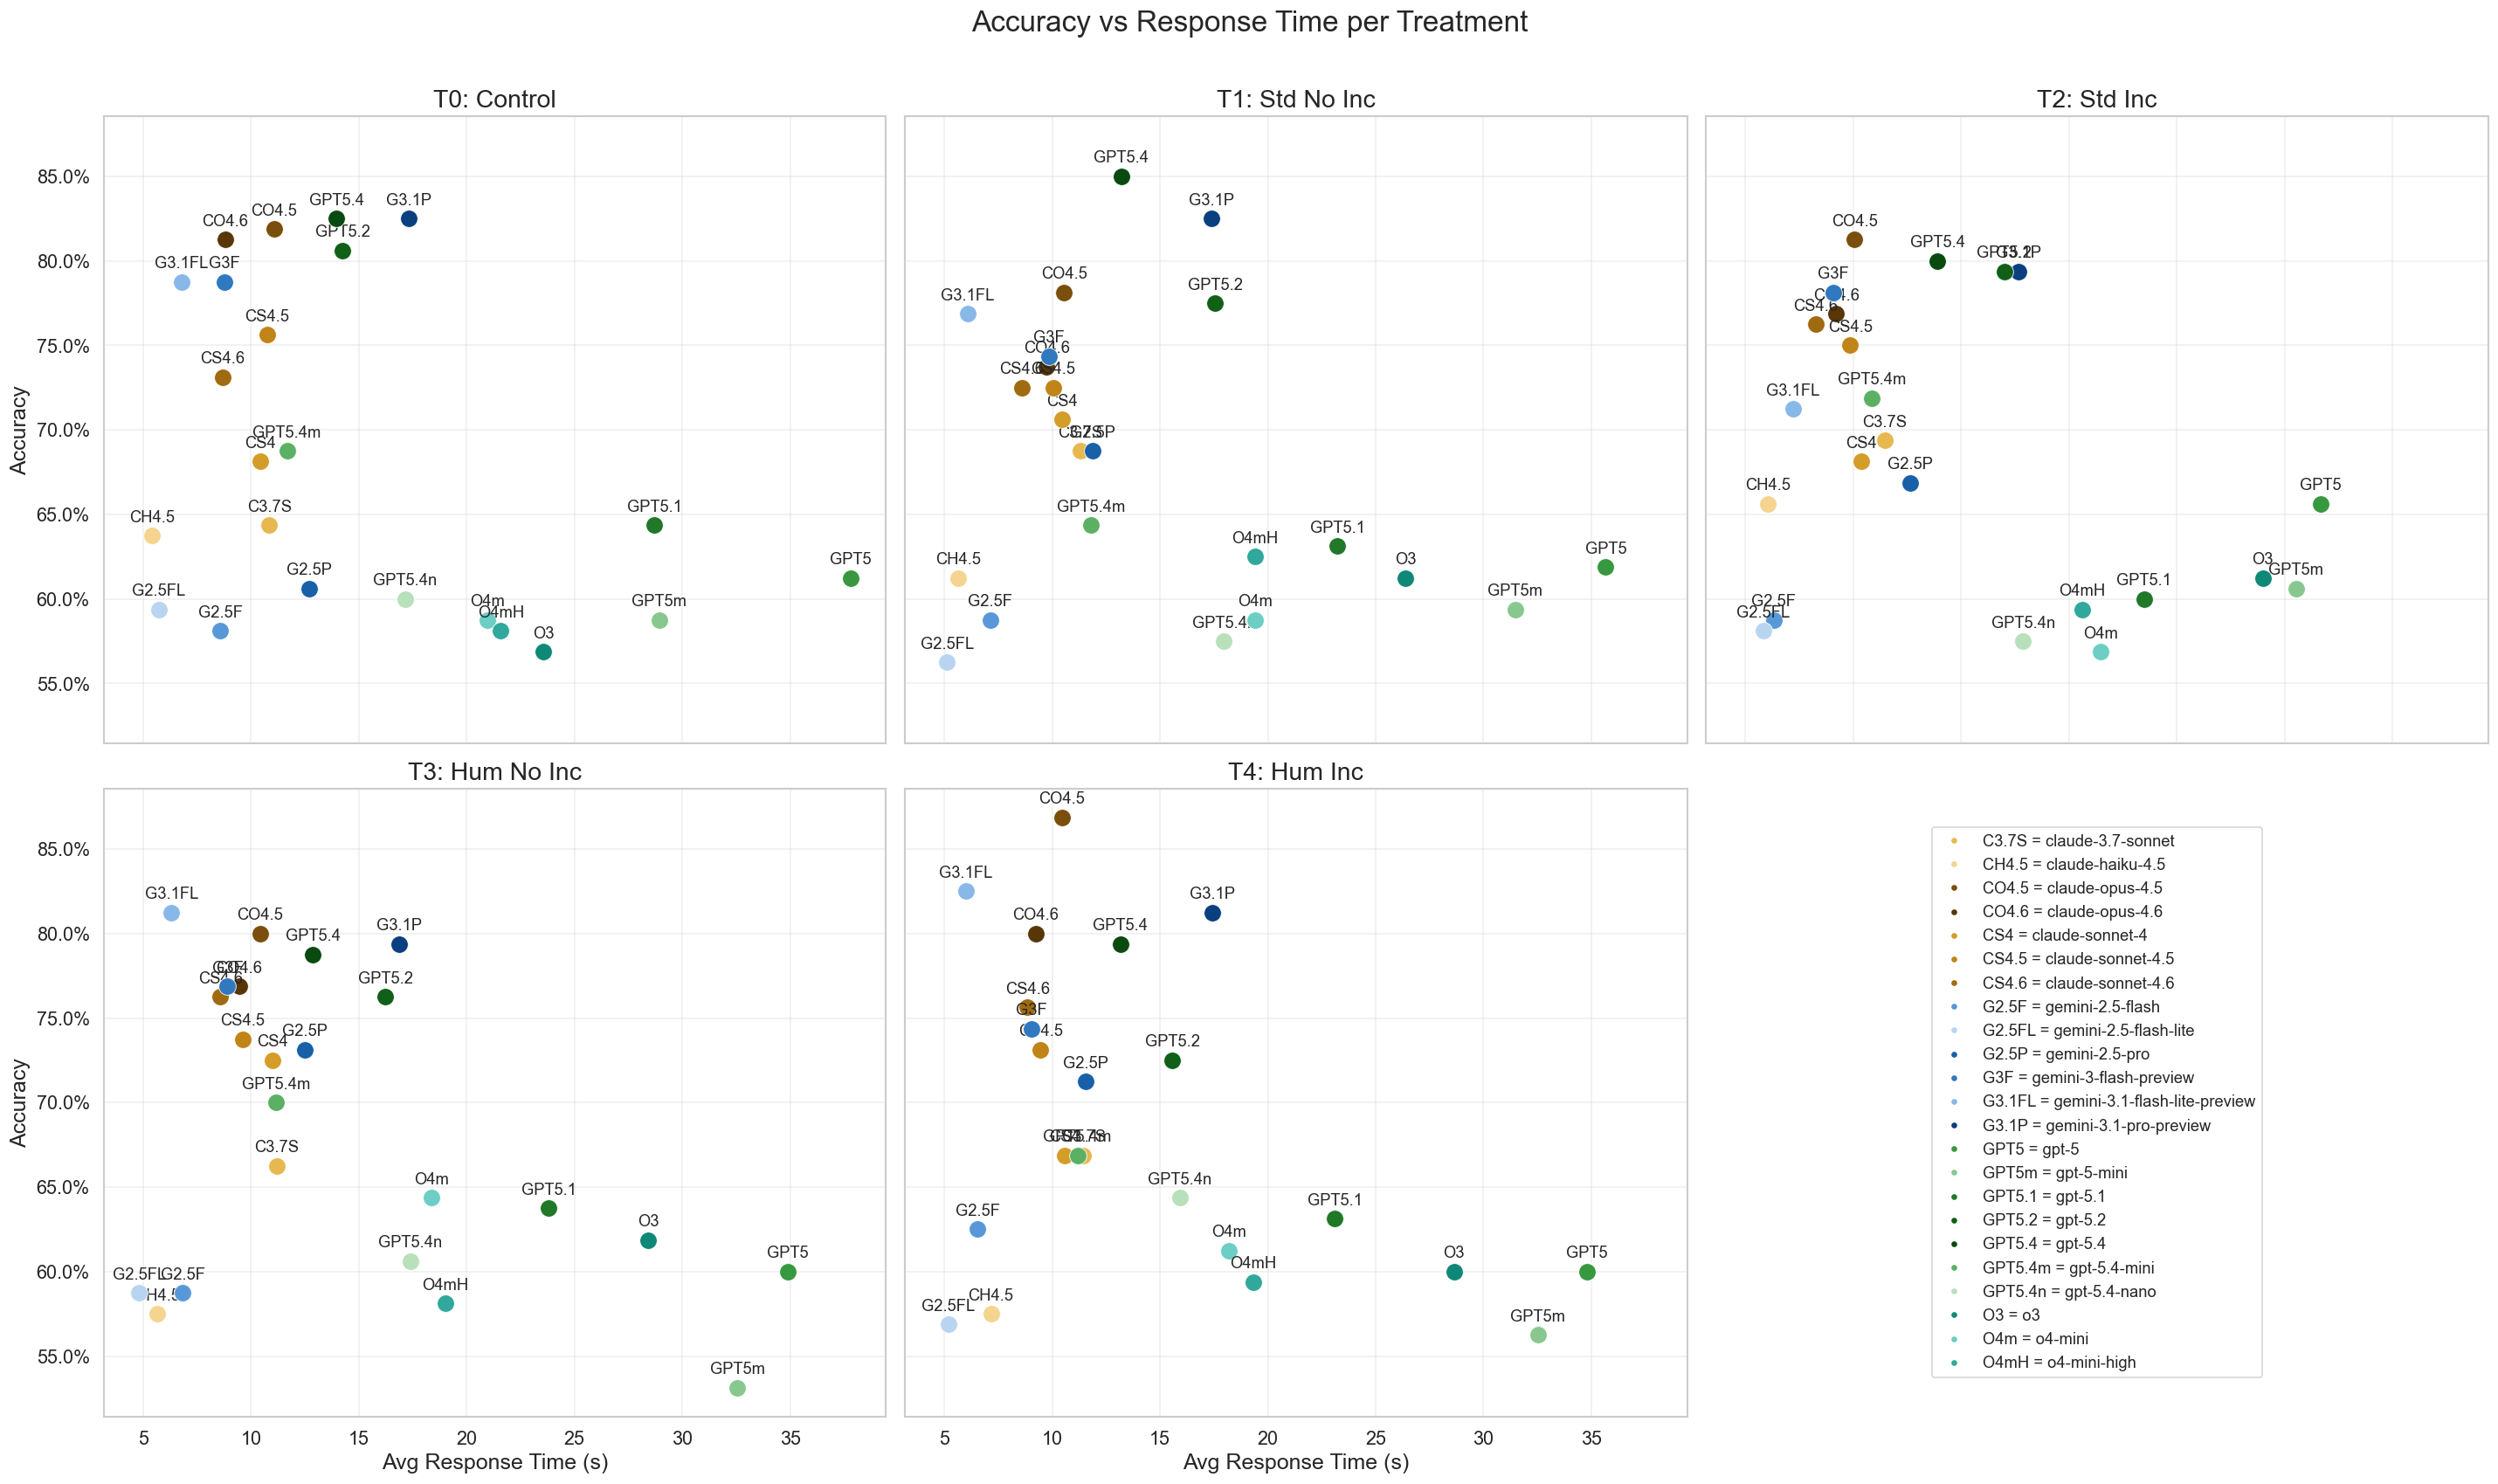

In [43]:
# Accuracy vs Response Time — per treatment (2×3 grid)
nrows, ncols = 2, 3
fig, axes = plt.subplots(
    nrows, ncols, figsize=(8 * ncols, 7 * nrows), sharey=True, sharex=True
)
axes_flat = axes.flatten()

for idx, treatment in enumerate(TREATMENT_ORDER):
    ax = axes_flat[idx]
    t_data = grouped_df[grouped_df["treatment"] == treatment]
    model_time_t = (
        t_data.groupby("model_short", observed=True)
        .agg(accuracy=("accuracy", "mean"), avg_time=("avg_time", "mean"))
        .reset_index()
    )
    for _, row in model_time_t.iterrows():
        ax.scatter(
            row["avg_time"],
            row["accuracy"],
            s=140,
            color=MODEL_COLORS.get(row["model_short"], "#888888"),
            edgecolors="white",
            linewidth=0.5,
            zorder=3,
        )
        ax.annotate(
            MODEL_ABBREV.get(row["model_short"], row["model_short"]),
            (row["avg_time"], row["accuracy"]),
            fontsize=11,
            ha="center",
            va="bottom",
            xytext=(0, 7),
            textcoords="offset points",
        )
    ax.set_title(treatment, fontsize=17)
    ax.tick_params(labelsize=13)
    ax.grid(alpha=0.3)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

for ax in axes[:, 0]:
    ax.set_ylabel("Accuracy", fontsize=15)
for ax in axes[-1, :]:
    ax.set_xlabel("Avg Response Time (s)", fontsize=15)

fig.suptitle("Accuracy vs Response Time per Treatment", fontsize=20, y=1.01)
# Place legend in empty 6th subplot
ax_leg = axes_flat[-1]
ax_leg.set_visible(True)
ax_leg.axis("off")
model_abbrev_legend(
    ax_leg, ncol=1, fontsize=11, loc="center", bbox_to_anchor=(0.5, 0.5)
)
fig.tight_layout()
plt.show()

## Image vs Text Mode Comparison

Compare all treatments in image mode vs text-only mode across all 5 treatments.
Text-only mode sends inline text representations of puzzles instead of rendered PNG images.


In [44]:
# ── Load image + text data for all treatments ──
IVT_EXPERIMENTS = {
    # Image experiments
    "t0-control": ("T0: Control", "Image"),
    "t1-standard-no-incentive": ("T1: Std No Inc", "Image"),
    "t2-standard-incentive": ("T2: Std Inc", "Image"),
    "t3-human-no-incentive": ("T3: Hum No Inc", "Image"),
    "t4-human-incentive": ("T4: Hum Inc", "Image"),
    # Text experiments
    "t0-control-text": ("T0: Control", "Text"),
    "t1-standard-no-incentive-text": ("T1: Std No Inc", "Text"),
    "t2-standard-incentive-text": ("T2: Std Inc", "Text"),
    "t3-human-no-incentive-text": ("T3: Hum No Inc", "Text"),
    "t4-human-incentive-text": ("T4: Hum Inc", "Text"),
}

conn = sqlite3.connect(DB_PATH)
exp_list = ", ".join(f"'{e}'" for e in IVT_EXPERIMENTS)
df_ivt = pd.read_sql_query(
    f"""
    SELECT
        e.name AS experiment,
        r.model, r.game,
        p.iteration, p.is_correct, p.response_time,
        p.prompt_tokens, p.completion_tokens, p.reasoning_tokens,
        p.total_tokens, p.response, p.solution,
        COALESCE(r.is_text, 0) AS is_text
    FROM puzzles p
    JOIN runs r ON p.run_id = r.id
    JOIN experiments e ON r.experiment_id = e.id
    WHERE r.status = 'completed'
      AND e.name IN ({exp_list})
    ORDER BY e.name, r.model, r.game, p.iteration
""",
    conn,
)
conn.close()

df_ivt["treatment"] = df_ivt["experiment"].map(lambda x: IVT_EXPERIMENTS[x][0])
df_ivt["mode"] = df_ivt["experiment"].map(lambda x: IVT_EXPERIMENTS[x][1])
df_ivt["model_short"] = df_ivt["model"].str.rsplit("/", n=1).str[-1]


# Lenient matching for string_entry
def _lenient_match(response, solution, game):
    r = str(response or "")
    s = str(solution or "")
    if game == "string_entry":
        for old, new in [("[SPACE]", " "), "\u2423 ", ("_", " "), ("\\\\", "\\")]:
            r = r.replace(old, new)
            s = s.replace(old, new)
        return int(r == s)
    return None


recomputed = df_ivt.apply(
    lambda row: _lenient_match(row["response"], row["solution"], row["game"]), axis=1
)
mask = recomputed.notna()
df_ivt.loc[mask, "is_correct"] = recomputed[mask].astype(int)
df_ivt["is_correct"] = df_ivt["is_correct"].fillna(0).astype(int)

# Also keep a T0-only view for backwards compat
df_text = df_ivt[df_ivt["treatment"] == "T0: Control"].copy()

print(f"Total rows: {len(df_ivt):,}")
print(
    f"Image: {(df_ivt['mode'] == 'Image').sum():,}  |  Text: {(df_ivt['mode'] == 'Text').sum():,}"
)
print(f"Treatments: {sorted(df_ivt['treatment'].unique())}")
print(f"Games: {sorted(df_ivt['game'].unique())}")

Total rows: 36,800
Image: 18,400  |  Text: 18,400
Treatments: ['T0: Control', 'T1: Std No Inc', 'T2: Std Inc', 'T3: Hum No Inc', 'T4: Hum Inc']
Games: ['add_numbers', 'counting_zeros', 'string_entry', 'sudoku_game', 'task_decoding', 'task_sequences', 'task_summation', 'task_transcription']


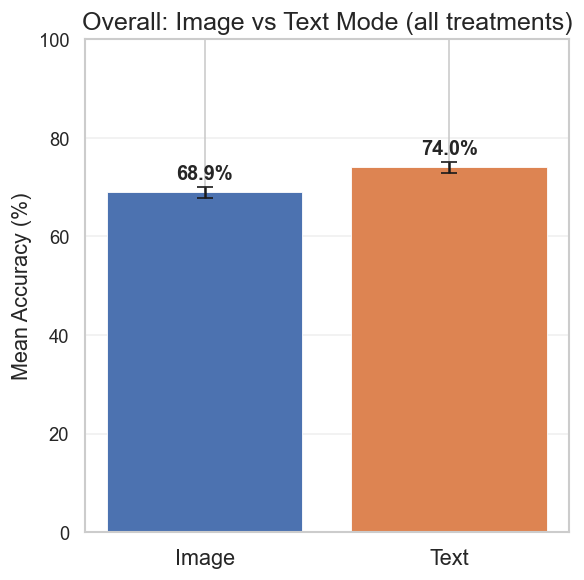

In [45]:
# ── Grouped: accuracy per (treatment, model, game, mode) ──
ivt_grouped = (
    df_ivt.groupby(["treatment", "mode", "model_short", "game"], observed=True)
    .agg(accuracy=("is_correct", "mean"), n=("is_correct", "count"))
    .reset_index()
)

# ── 1. Overall accuracy: Image vs Text (all treatments pooled) ──
mode_acc = ivt_grouped.groupby("mode")["accuracy"].agg(["mean", "std", "count"])
mode_acc["se"] = mode_acc["std"] / np.sqrt(mode_acc["count"])

fig, ax = plt.subplots(figsize=(5, 5))
colors = {"Image": "#4C72B0", "Text": "#DD8452"}
for i, mode in enumerate(["Image", "Text"]):
    row = mode_acc.loc[mode]
    ax.bar(
        i,
        row["mean"] * 100,
        yerr=row["se"] * 100,
        capsize=5,
        color=colors[mode],
        edgecolor="white",
        linewidth=0.5,
    )
    ax.text(
        i,
        row["mean"] * 100 + row["se"] * 100 + 1.5,
        f"{row['mean']:.1%}",
        ha="center",
        fontsize=12,
        fontweight="bold",
    )
ax.set_xticks([0, 1])
ax.set_xticklabels(["Image", "Text"], fontsize=13)
ax.set_ylabel("Mean Accuracy (%)", fontsize=13)
ax.set_title("Overall: Image vs Text Mode (all treatments)", fontsize=15)
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

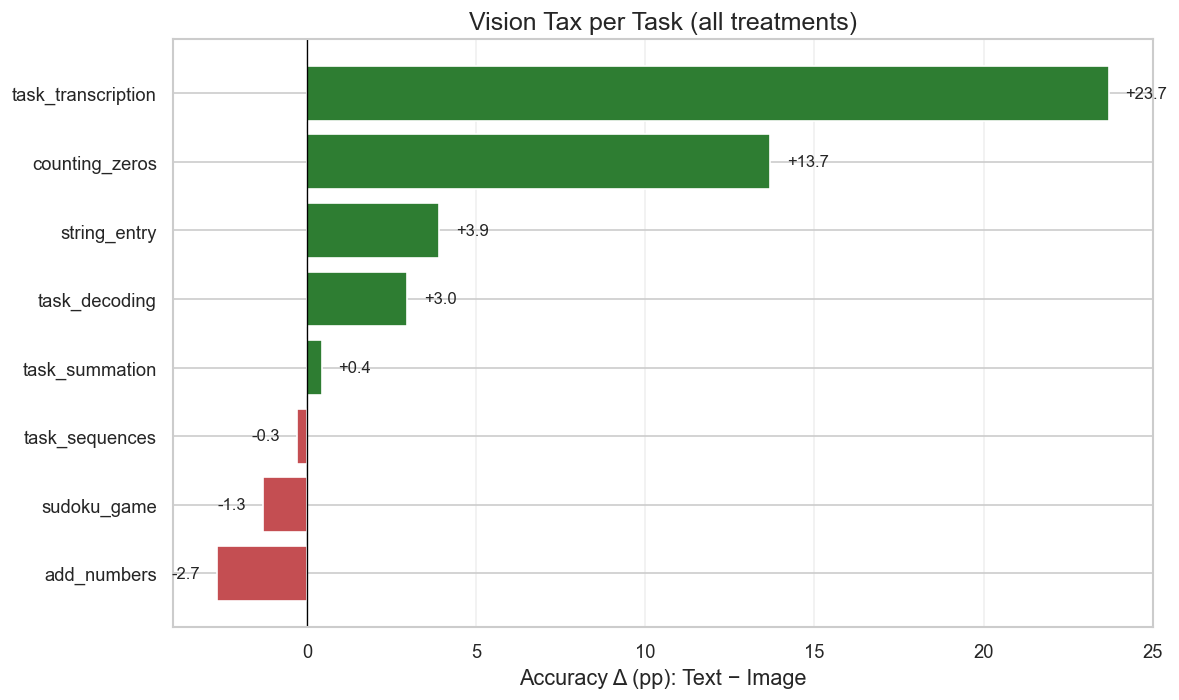

In [46]:
# ── 2. Accuracy delta (Text − Image) per task (all treatments pooled) ──
game_mode = ivt_grouped.groupby(["game", "mode"])["accuracy"].mean().unstack("mode")
game_delta = ((game_mode["Text"] - game_mode["Image"]) * 100).sort_values().dropna()

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ["#2E7D32" if v >= 0 else "#C44E52" for v in game_delta]
ax.barh(range(len(game_delta)), game_delta.values, color=bar_colors, edgecolor="white")
ax.set_yticks(range(len(game_delta)))
ax.set_yticklabels(game_delta.index, fontsize=11)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Accuracy \u0394 (pp): Text \u2212 Image", fontsize=13)
ax.set_title("Vision Tax per Task (all treatments)", fontsize=15)
ax.grid(axis="x", alpha=0.3)
for i, val in enumerate(game_delta.values):
    ax.text(
        val + (0.5 if val >= 0 else -0.5),
        i,
        f"{val:+.1f}",
        va="center",
        ha="left" if val >= 0 else "right",
        fontsize=10,
    )
fig.tight_layout()
plt.show()

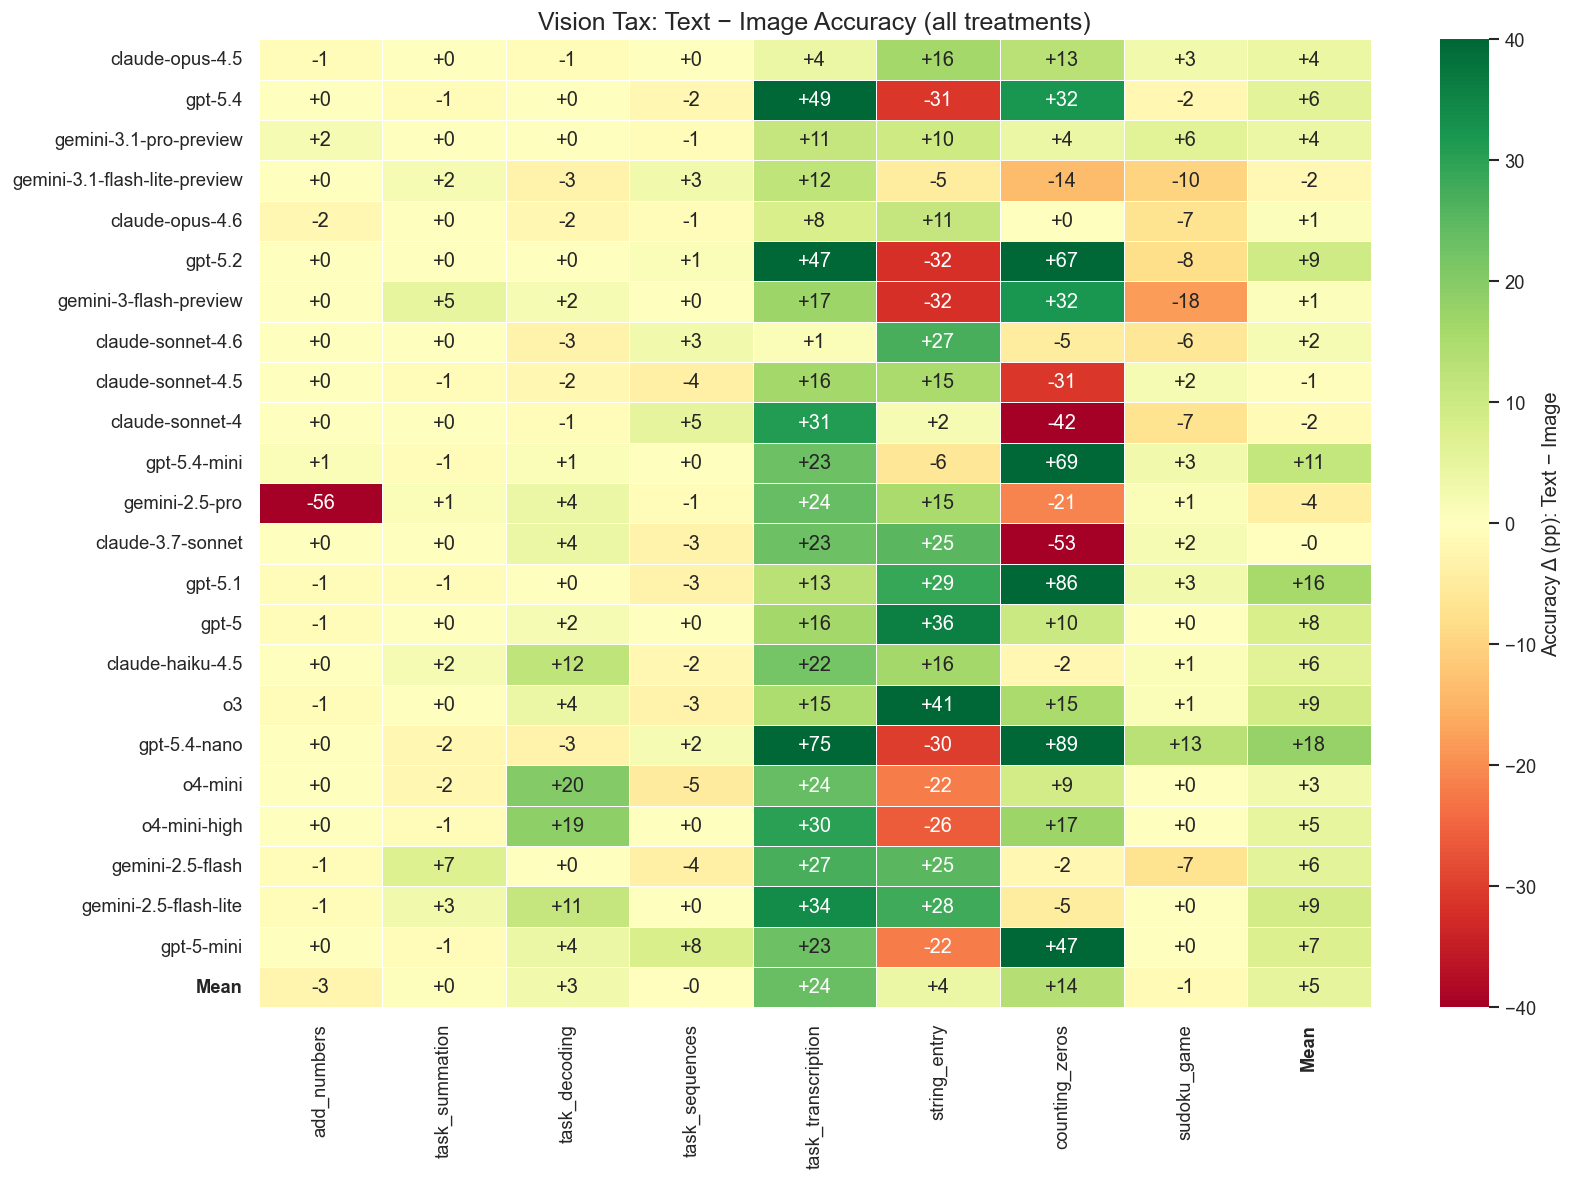

In [47]:
# ── 3. Heatmap: accuracy delta (Text − Image) per model × game (all treatments) ──
pivot_img = ivt_grouped[ivt_grouped["mode"] == "Image"].pivot_table(
    index="model_short", columns="game", values="accuracy"
)
pivot_txt = ivt_grouped[ivt_grouped["mode"] == "Text"].pivot_table(
    index="model_short", columns="game", values="accuracy"
)
_acc_avg = grouped_df.pivot_table(index="model_short", columns="game", values="accuracy") * 100
_model_ord = _acc_avg.mean(axis=1).sort_values(ascending=False).index.tolist()
_game_ord = _acc_avg.mean(axis=0).sort_values(ascending=False).index.tolist()
common_models = [m for m in _model_ord if m in pivot_img.index and m in pivot_txt.index]
common_games = [g for g in _game_ord if g in pivot_img.columns and g in pivot_txt.columns]
delta_heatmap = (
    pivot_txt.loc[common_models, common_games]
    - pivot_img.loc[common_models, common_games]
) * 100
delta_heatmap["Mean"] = delta_heatmap.mean(axis=1)
delta_heatmap.loc["Mean"] = delta_heatmap.mean(axis=0)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    delta_heatmap,
    annot=True,
    fmt="+.0f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    ax=ax,
    vmin=-40,
    vmax=40,
    cbar_kws={"label": "Accuracy \u0394 (pp): Text \u2212 Image"},
)
for lbl in ax.get_xticklabels():
    if lbl.get_text() == "Mean":
        lbl.set_weight("bold")
for lbl in ax.get_yticklabels():
    if lbl.get_text() == "Mean":
        lbl.set_weight("bold")
ax.set_title("Vision Tax: Text \u2212 Image Accuracy (all treatments)", fontsize=15)
ax.set_ylabel("")
ax.set_xlabel("")
fig.tight_layout()
plt.show()


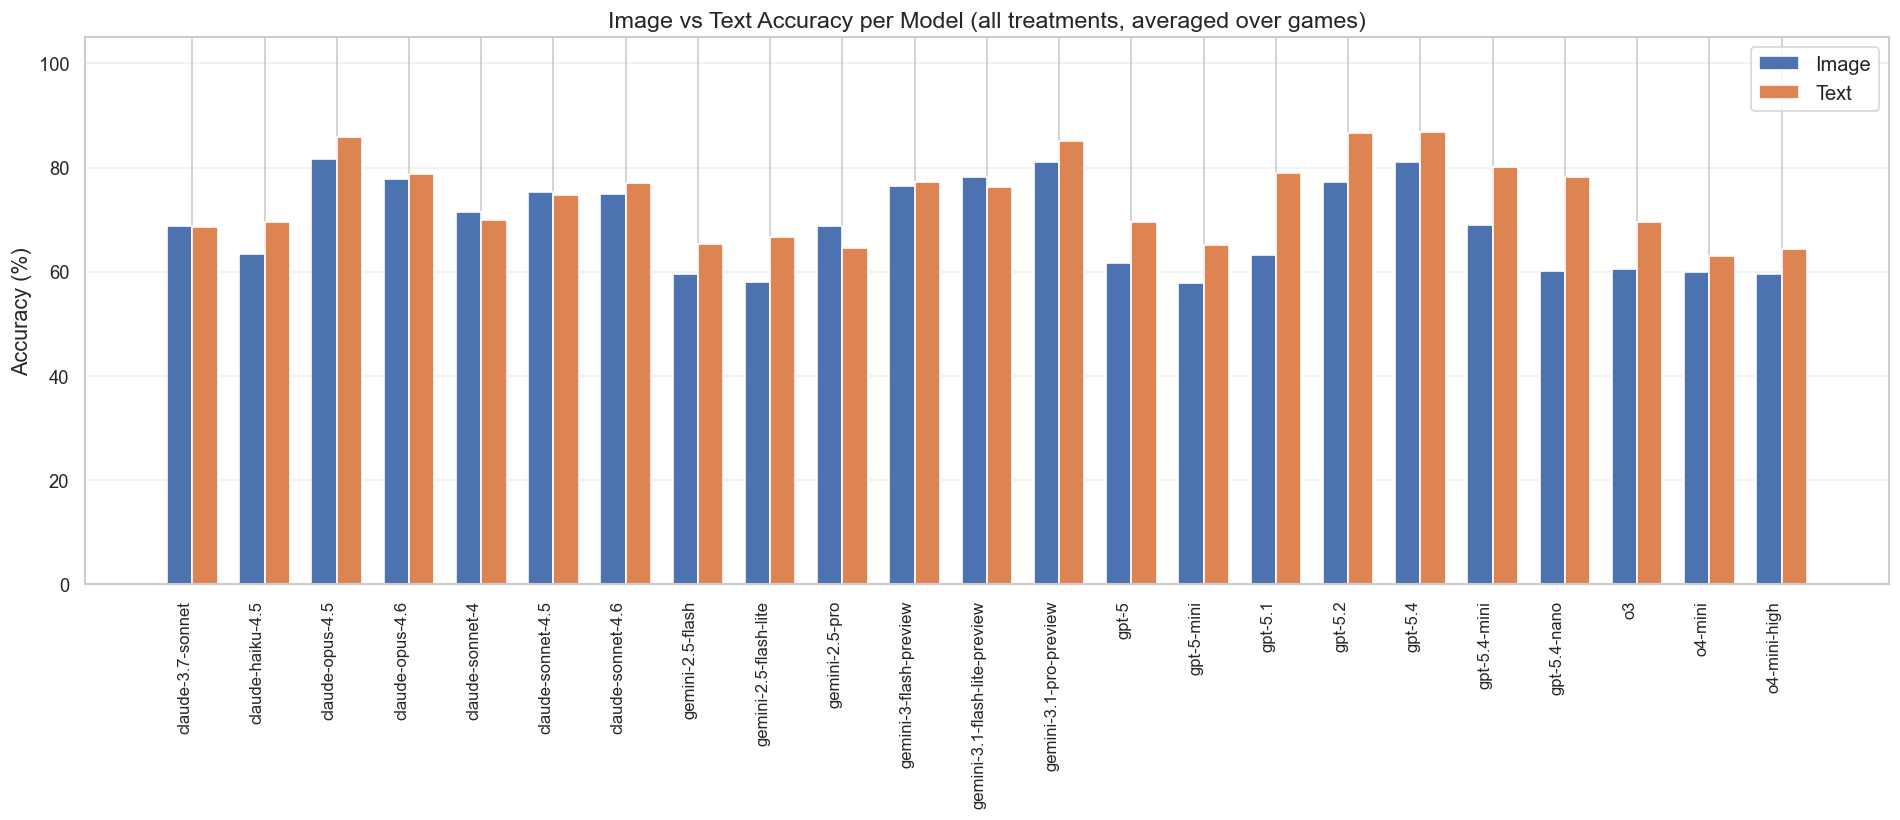

In [48]:
# ── 4. Side-by-side: Image vs Text accuracy per model (all treatments, averaged over games) ──
model_mode = (
    ivt_grouped.groupby(["model_short", "mode"])["accuracy"].mean().unstack("mode")
)
common = [m for m in sort_by_family(model_mode.index.tolist()) if m in model_mode.index]
model_mode = model_mode.loc[common]

x = np.arange(len(common))
width = 0.35
fig, ax = plt.subplots(figsize=(16, 7))
ax.bar(
    x - width / 2,
    model_mode["Image"] * 100,
    width,
    label="Image",
    color="#4C72B0",
    edgecolor="white",
)
ax.bar(
    x + width / 2,
    model_mode["Text"] * 100,
    width,
    label="Text",
    color="#DD8452",
    edgecolor="white",
)
ax.set_xticks(x)
ax.set_xticklabels(common, rotation=90, ha="right", fontsize=10)
ax.set_ylabel("Accuracy (%)", fontsize=13)
ax.set_title(
    "Image vs Text Accuracy per Model (all treatments, averaged over games)",
    fontsize=14,
)
ax.set_ylim(0, 105)
ax.legend(fontsize=12)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

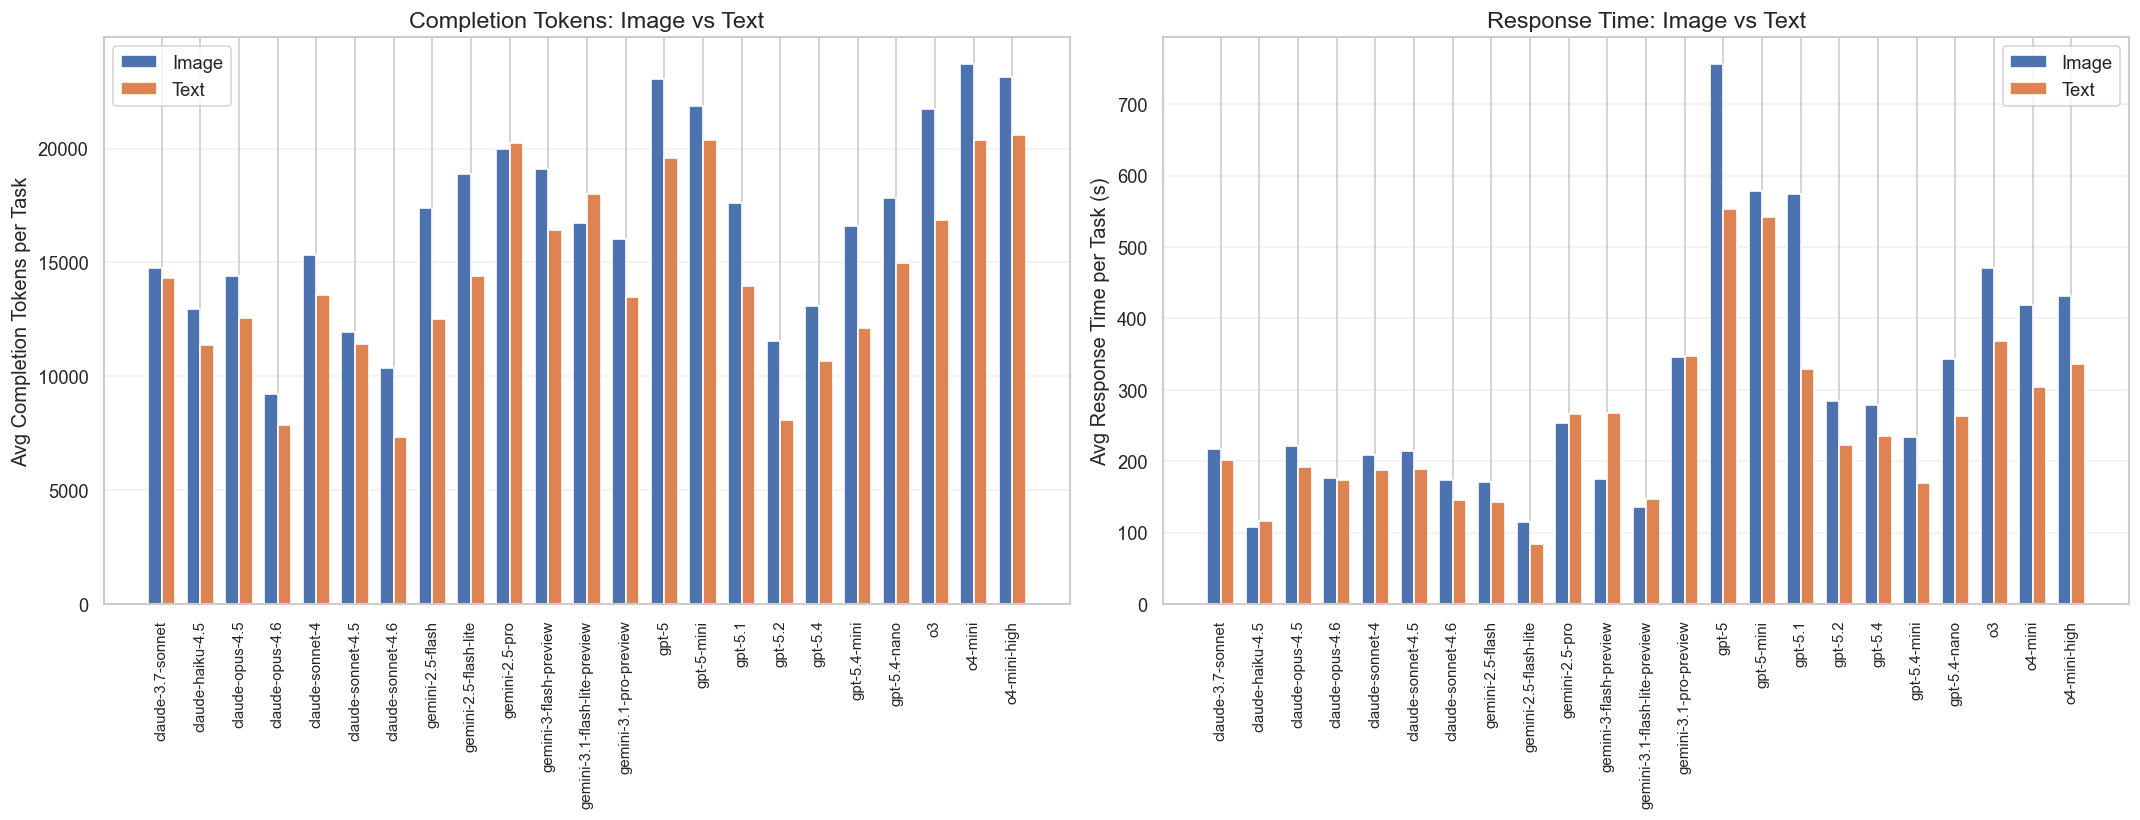

In [49]:
# ── 5. Completion tokens comparison: Image vs Text ──
tok_grouped = (
    df_text.groupby(["mode", "model_short", "game"], observed=True)
    .agg(
        total_completion=("completion_tokens", "sum"),
        total_time=("response_time", "sum"),
    )
    .reset_index()
)

tok_img = (
    tok_grouped[tok_grouped["mode"] == "Image"]
    .groupby("model_short")["total_completion"]
    .mean()
)
tok_txt = (
    tok_grouped[tok_grouped["mode"] == "Text"]
    .groupby("model_short")["total_completion"]
    .mean()
)
tok_common = sorted(
    set(tok_img.index) & set(tok_txt.index), key=lambda m: sort_by_family([m])[0]
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Tokens
ax = axes[0]
x = np.arange(len(tok_common))
ax.bar(
    x - width / 2,
    [tok_img[m] for m in tok_common],
    width,
    label="Image",
    color="#4C72B0",
    edgecolor="white",
)
ax.bar(
    x + width / 2,
    [tok_txt[m] for m in tok_common],
    width,
    label="Text",
    color="#DD8452",
    edgecolor="white",
)
ax.set_xticks(x)
ax.set_xticklabels(tok_common, rotation=90, fontsize=9)
ax.set_ylabel("Avg Completion Tokens per Task", fontsize=12)
ax.set_title("Completion Tokens: Image vs Text", fontsize=14)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)

# Time
time_img = (
    tok_grouped[tok_grouped["mode"] == "Image"]
    .groupby("model_short")["total_time"]
    .mean()
)
time_txt = (
    tok_grouped[tok_grouped["mode"] == "Text"]
    .groupby("model_short")["total_time"]
    .mean()
)
ax = axes[1]
ax.bar(
    x - width / 2,
    [time_img.get(m, 0) for m in tok_common],
    width,
    label="Image",
    color="#4C72B0",
    edgecolor="white",
)
ax.bar(
    x + width / 2,
    [time_txt.get(m, 0) for m in tok_common],
    width,
    label="Text",
    color="#DD8452",
    edgecolor="white",
)
ax.set_xticks(x)
ax.set_xticklabels(tok_common, rotation=90, fontsize=9)
ax.set_ylabel("Avg Response Time per Task (s)", fontsize=12)
ax.set_title("Response Time: Image vs Text", fontsize=14)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
plt.show()

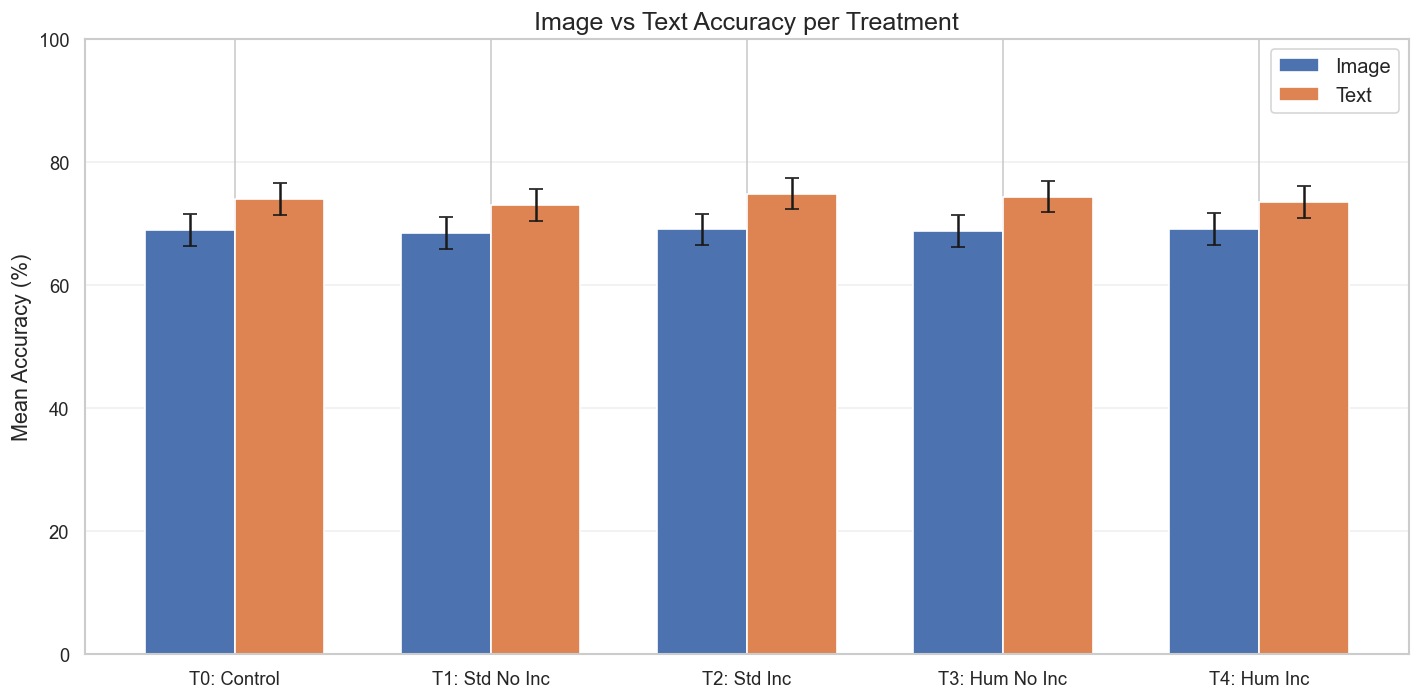

In [50]:
# ── 6. Image vs Text accuracy per treatment ──
treat_mode = (
    ivt_grouped.groupby(["treatment", "mode"])["accuracy"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
treat_mode["se"] = treat_mode["std"] / np.sqrt(treat_mode["count"])

treatments = TREATMENT_ORDER
x = np.arange(len(treatments))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 6))

for i, mode in enumerate(["Image", "Text"]):
    mdata = (
        treat_mode[treat_mode["mode"] == mode].set_index("treatment").loc[treatments]
    )
    offset = -width / 2 if mode == "Image" else width / 2
    color = "#4C72B0" if mode == "Image" else "#DD8452"
    ax.bar(
        x + offset,
        mdata["mean"] * 100,
        width,
        yerr=mdata["se"] * 100,
        capsize=4,
        label=mode,
        color=color,
        edgecolor="white",
    )

ax.set_xticks(x)
ax.set_xticklabels(treatments, fontsize=11)
ax.set_ylabel("Mean Accuracy (%)", fontsize=13)
ax.set_title("Image vs Text Accuracy per Treatment", fontsize=15)
ax.set_ylim(0, 100)
ax.legend(fontsize=12)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

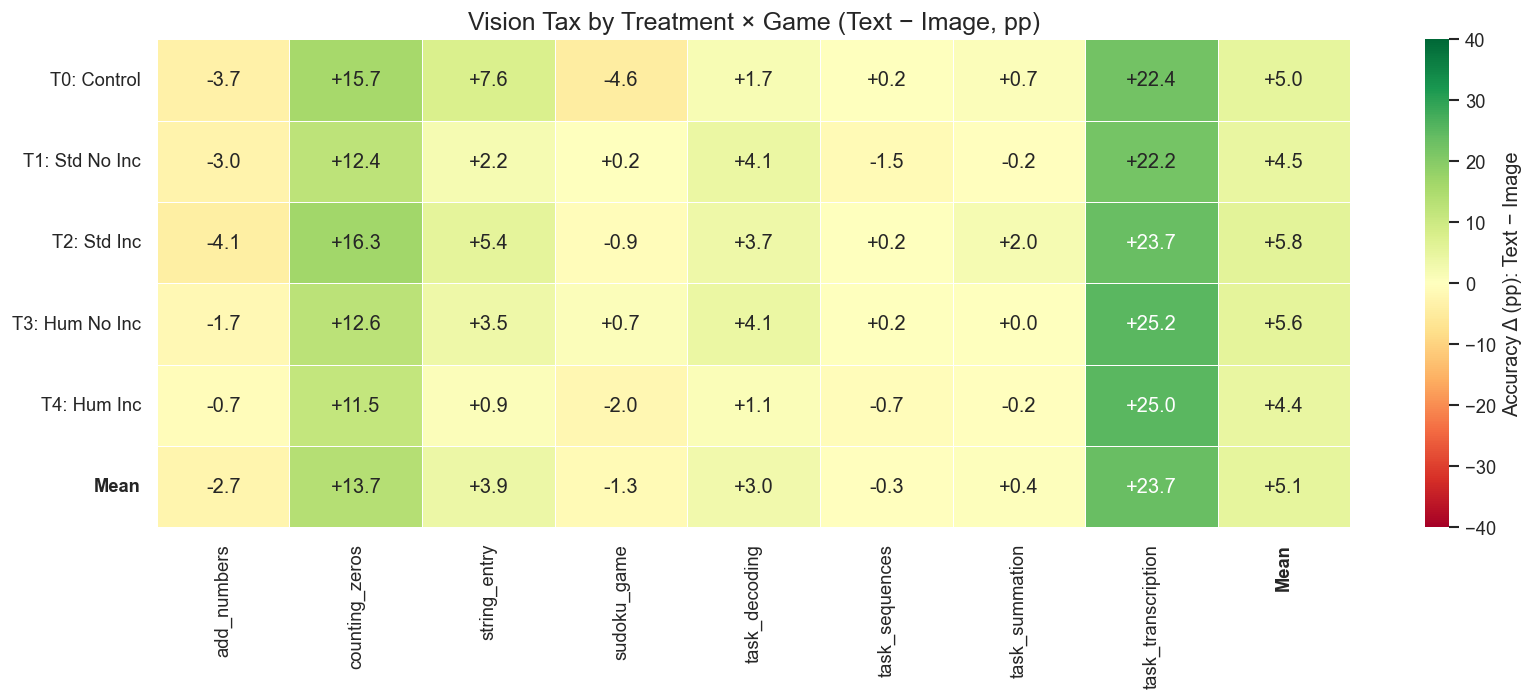

In [51]:
# ── 7. Vision tax (Text − Image) per treatment × game ──
img_tg = (
    ivt_grouped[ivt_grouped["mode"] == "Image"]
    .groupby(["treatment", "game"])["accuracy"]
    .mean()
)
txt_tg = (
    ivt_grouped[ivt_grouped["mode"] == "Text"]
    .groupby(["treatment", "game"])["accuracy"]
    .mean()
)
delta_tg = ((txt_tg - img_tg) * 100).unstack("game").reindex(TREATMENT_ORDER)
delta_tg["Mean"] = delta_tg.mean(axis=1)
delta_tg.loc["Mean"] = delta_tg.mean(axis=0)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    delta_tg,
    annot=True,
    fmt="+.1f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    ax=ax,
    vmin=-40,
    vmax=40,
    cbar_kws={"label": "Accuracy \u0394 (pp): Text \u2212 Image"},
)
for lbl in ax.get_xticklabels():
    if lbl.get_text() == "Mean":
        lbl.set_weight("bold")
for lbl in ax.get_yticklabels():
    if lbl.get_text() == "Mean":
        lbl.set_weight("bold")
ax.set_title("Vision Tax by Treatment \u00d7 Game (Text \u2212 Image, pp)", fontsize=15)
ax.set_ylabel("")
ax.set_xlabel("")
fig.tight_layout()
plt.show()

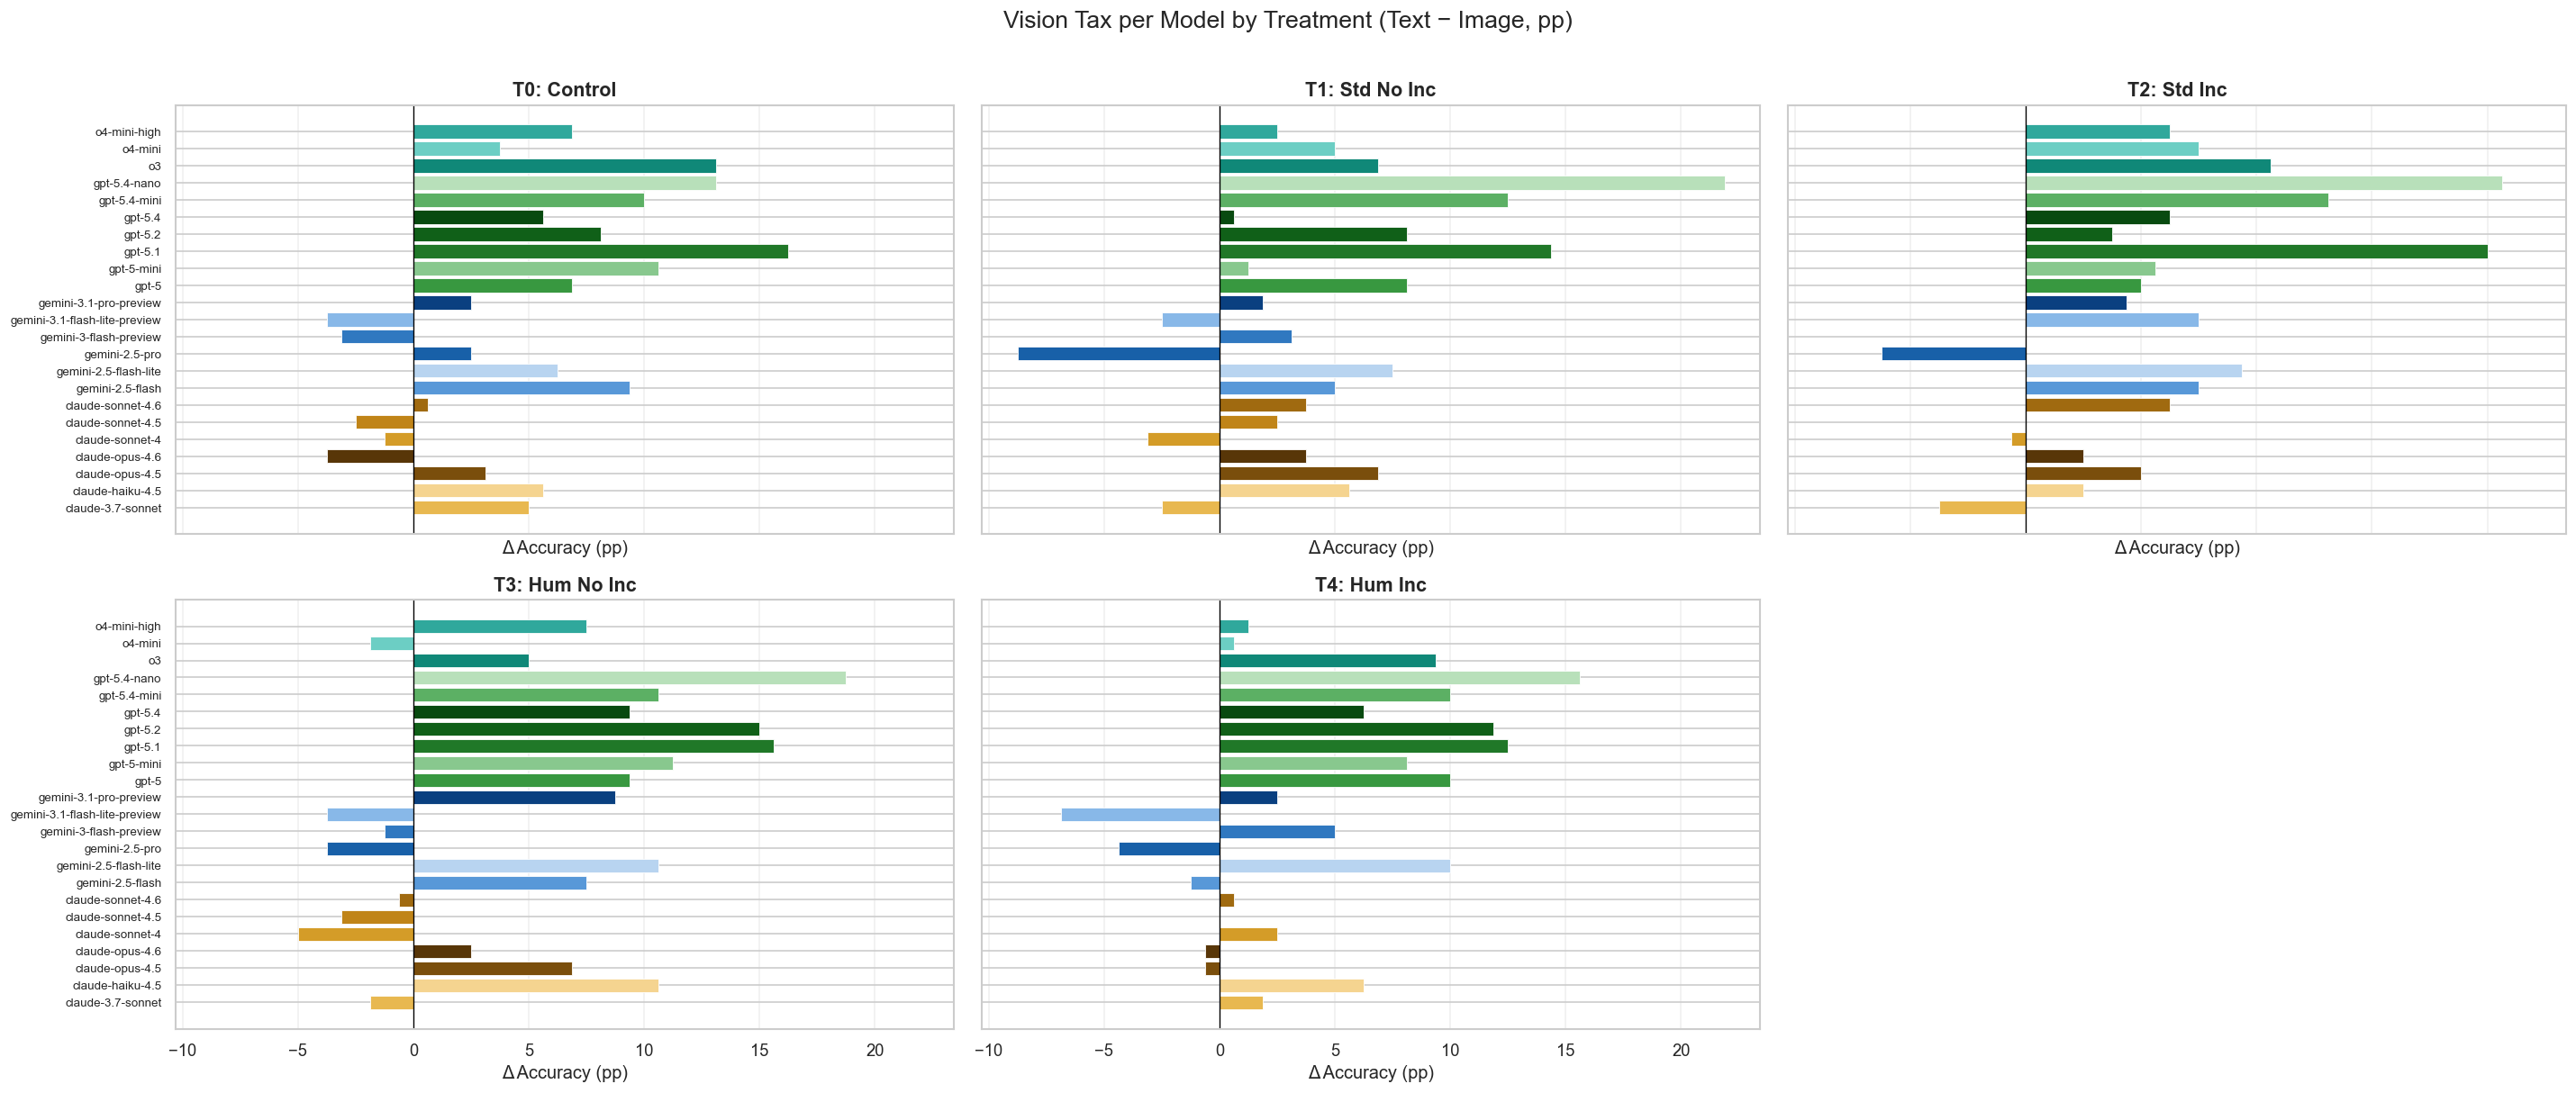

In [52]:
# ── 8. Vision tax per model, faceted by treatment ──
img_tm = (
    ivt_grouped[ivt_grouped["mode"] == "Image"]
    .groupby(["treatment", "model_short"])["accuracy"]
    .mean()
)
txt_tm = (
    ivt_grouped[ivt_grouped["mode"] == "Text"]
    .groupby(["treatment", "model_short"])["accuracy"]
    .mean()
)
delta_tm = ((txt_tm - img_tm) * 100).reset_index(name="delta")

ncols = 3
nrows = 2
fig, axes = plt.subplots(
    nrows, ncols, figsize=(8 * ncols, 5 * nrows), sharey=True, sharex=True
)
axes_flat = axes.flatten()

for idx, treatment in enumerate(TREATMENT_ORDER):
    ax = axes_flat[idx]
    tdata = delta_tm[delta_tm["treatment"] == treatment].copy()
    tdata = (
        tdata.set_index("model_short")
        .reindex(sort_by_family(tdata["model_short"].unique().tolist()))
        .dropna(subset=["delta"])
    )
    y = np.arange(len(tdata))
    bar_colors = [MODEL_COLORS.get(m, "#888888") for m in tdata.index]
    ax.barh(y, tdata["delta"], color=bar_colors, edgecolor="white", linewidth=0.5)
    ax.set_yticks(y)
    ax.set_yticklabels(tdata.index, fontsize=8)
    ax.set_title(treatment, fontsize=13, fontweight="bold")
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("\u0394 Accuracy (pp)")
    ax.grid(axis="x", alpha=0.3)

axes_flat[-1].set_visible(False)
fig.suptitle(
    "Vision Tax per Model by Treatment (Text \u2212 Image, pp)", fontsize=16, y=1.01
)
fig.tight_layout()
plt.show()

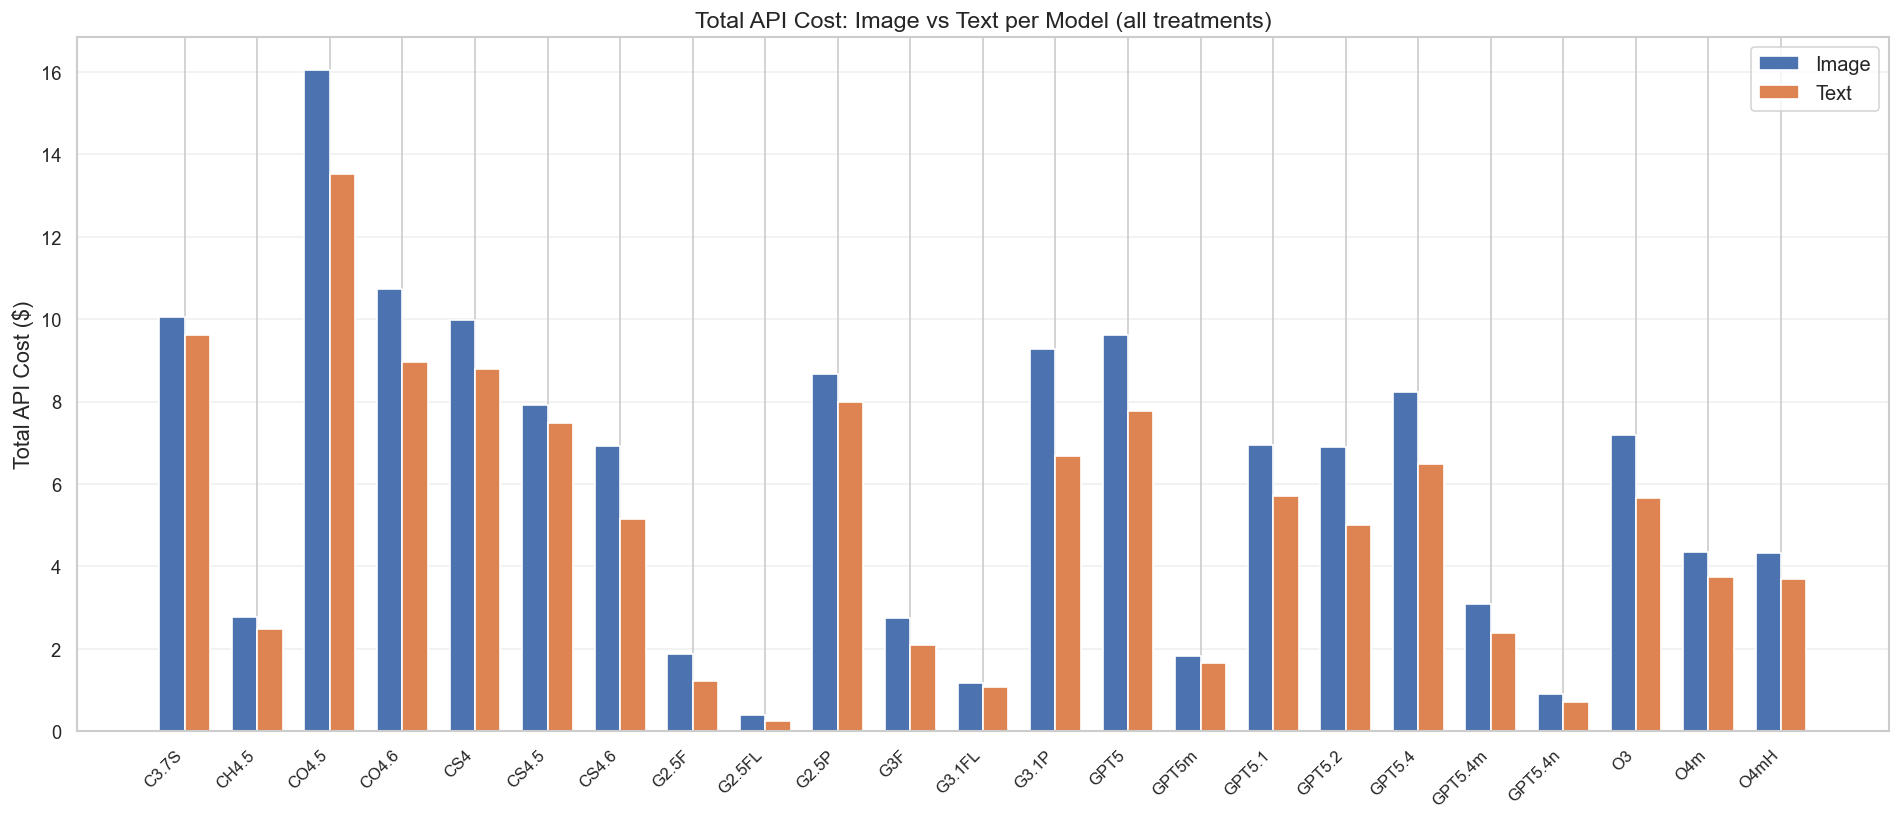

In [53]:
# ── 9. Cost comparison: Image vs Text (averaged over treatments) ──
df_ivt["cost_total"] = (
    df_ivt["model"].map(lambda m: PRICING.get(m, {"input": 0, "output": 0})["input"])
    * df_ivt["prompt_tokens"]
    + df_ivt["model"].map(lambda m: PRICING.get(m, {"input": 0, "output": 0})["output"])
    * df_ivt["completion_tokens"]
)

cost_mode = df_ivt.groupby(["mode", "model_short"])["cost_total"].sum().reset_index()
cost_pivot = cost_mode.pivot(index="model_short", columns="mode", values="cost_total")
common = [m for m in sort_by_family(cost_pivot.index.tolist()) if m in cost_pivot.index]
cost_pivot = cost_pivot.loc[common]

x = np.arange(len(common))
width = 0.35
fig, ax = plt.subplots(figsize=(16, 7))
ax.bar(
    x - width / 2,
    cost_pivot["Image"],
    width,
    label="Image",
    color="#4C72B0",
    edgecolor="white",
)
ax.bar(
    x + width / 2,
    cost_pivot["Text"],
    width,
    label="Text",
    color="#DD8452",
    edgecolor="white",
)
ax.set_xticks(x)
ax.set_xticklabels(
    [MODEL_ABBREV.get(m, m) for m in common], rotation=45, ha="right", fontsize=10
)
ax.set_ylabel("Total API Cost ($)", fontsize=13)
ax.set_title("Total API Cost: Image vs Text per Model (all treatments)", fontsize=14)
ax.legend(fontsize=12)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

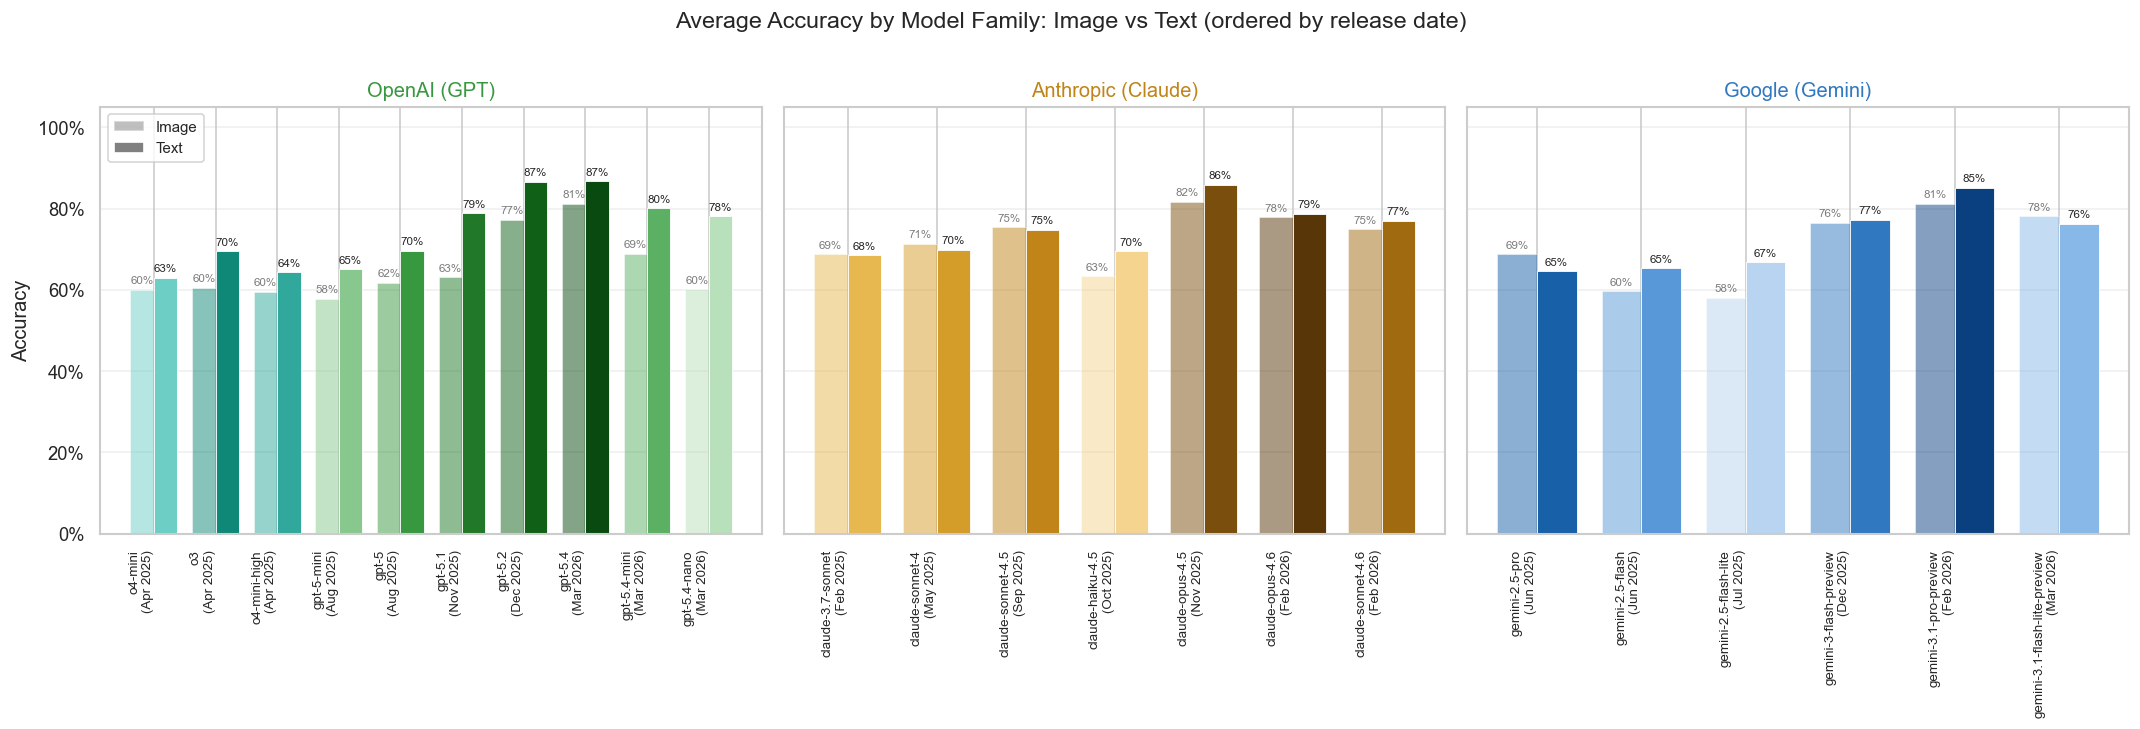

In [54]:
# ── 10. Average Accuracy by Model Family — Text mode (ordered by release date) ──
# Same as the image-mode family evolution plot but using text-only results

model_acc_text = (
    df_ivt[df_ivt["mode"] == "Text"]
    .groupby("model_short", observed=True)["is_correct"]
    .mean()
)
model_acc_img = (
    df_ivt[df_ivt["mode"] == "Image"]
    .groupby("model_short", observed=True)["is_correct"]
    .mean()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

family_colors = {
    "OpenAI (GPT)": "#389840",
    "Anthropic (Claude)": "#C08418",
    "Google (Gemini)": "#3078C0",
}

for ax, (fam_name, models) in zip(axes, families.items()):
    accs_text = [model_acc_text.get(m, 0) for m in models]
    accs_img = [model_acc_img.get(m, 0) for m in models]
    dates = [MODEL_RELEASE_DATE[m].strftime("%b %Y") for m in models]
    labels = [f"{m}\n({d})" for m, d in zip(models, dates)]

    x = np.arange(len(models))
    width = 0.38

    ax.bar(
        x - width / 2,
        accs_img,
        width,
        label="Image",
        color=[MODEL_COLORS.get(m, "#888") for m in models],
        edgecolor="white",
        linewidth=0.5,
        alpha=0.5,
    )
    ax.bar(
        x + width / 2,
        accs_text,
        width,
        label="Text",
        color=[MODEL_COLORS.get(m, "#888") for m in models],
        edgecolor="white",
        linewidth=0.5,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=90, ha="right", fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_ylabel("Accuracy" if ax == axes[0] else "")
    ax.set_title(fam_name, fontsize=12, color=family_colors[fam_name])
    ax.grid(axis="y", alpha=0.3)
    if ax == axes[0]:
        from matplotlib.patches import Patch

        ax.legend(
            handles=[
                Patch(facecolor="gray", alpha=0.5, edgecolor="white", label="Image"),
                Patch(facecolor="gray", alpha=1.0, edgecolor="white", label="Text"),
            ],
            fontsize=9,
            loc="upper left",
        )

    for i, (vi, vt) in enumerate(zip(accs_img, accs_text)):
        ax.text(
            i - width / 2,
            vi + 0.01,
            f"{vi:.0%}",
            ha="center",
            va="bottom",
            fontsize=7,
            alpha=0.6,
        )
        ax.text(
            i + width / 2, vt + 0.01, f"{vt:.0%}", ha="center", va="bottom", fontsize=7
        )

fig.suptitle(
    "Average Accuracy by Model Family: Image vs Text (ordered by release date)",
    fontsize=14,
    y=1.01,
)
fig.tight_layout()
plt.show()